# KAMP 프레스 데이터 분석 v4_3 (Train·Valid만 사용)

**이 노트북의 방식**: v4_2와 같고, 라벨만 윈도 시작에서 120행 뒤의 행을 씁니다. 라벨이 파일 단위라 120행 뒤 라벨도 지금 라벨과 같고, 각 분할의 마지막 약 100행이 입력에 쓰이지 않습니다.

| 폴더 | 방식 |
|---|---|
| v4_1 | 공백 고려: 끊김으로 나눈 구간 단위 분할, 구간 안에서만 윈도 |
| v4_2 | 공백 무시: 행 단위 고정 위치 분할, 끊김을 넘어 윈도, 라벨은 윈도 마지막 행 |
| v4_3 | v4_2와 같고 라벨만 윈도 시작에서 120행 뒤 (각 분할의 마지막 약 100행이 입력에 쓰이지 않음) |

**원칙**

| 원칙 | 이 노트북에서 하는 일 |
|---|---|
| 세 폴더는 독립 | 각 폴더는 자기 분할, 자기 Train과 Valid만 씁니다. 다른 폴더의 변수나 임계값을 가져오지 않습니다 |
| Test는 떼어 두기만 | 분할 직후 Test 행을 따로 옮기고, 분석과 평가에 쓰지 않습니다 |
| 학습은 정상 Train으로 | 표준화, 결측 대치, PCA, 공분산, VIF는 정상 Train으로만 계산합니다 |
| 선택은 Valid로 | 변수 선택, 대표 변수, 임계값은 Valid로 정합니다 |
| 점검은 실제 확인으로 | 분리 점검표의 각 줄은 코드로 실제 값을 다시 계산해 확인합니다 |
| 공식 분할은 나중에 | 모델을 최종 비교하기 전에 v4_1, v4_2, v4_3 중 하나를 공식 분할로 정합니다. 나머지는 참고 분석입니다 |

| 단계 | 내용 |
|---|---|
| 00 | 설정 |
| 01 | 불러오기, 품질 검사, 끊김 기준 점검과 민감도(Train 기간만) |
| 02 | 분할, 분리 점검, 분할 목록 저장, Test 따로 보관 |
| 02-2 | 시간 간격과 끊김: 간격 분포, 끊김 파형, 끊김 길이, 재시작 근거, 구간 길이 (Train+Valid) |
| 03 | 원 신호: 분포, 센서 간 상관과 고윳값, 자기상관, 시차 상관, 누적 분포와 절댓값, 파형 |
| 04 | 윈도와 파생변수 63개, 이상 근거(구간 수), 윈도 길이별 활용률, 스펙트럼 |
| 05 | 변수별 구분력, 신뢰구간, 선택 낙관도, RMS–P2P 관계 |
| 06 | 변수 간 상관, 중복 묶기, VIF로 대표 변수 고르기 |
| 07 | 고윳값(PCA), T², SPE, 마할라노비스 거리² |
| 08 | 드리프트, 공백 관련 점검 |
| 09 | 후보 네 가지의 Valid 성능, 구간 단위 경보, 분리 여유, 선택 낙관도 |
| 10 | 종합 요약 `요약.md` 만들기 |

## 00 설정

이 폴더(v4_3)의 방식은 아래 네 값으로 정해집니다. 다른 값은 세 폴더가 같습니다.

- `SPLIT_MODE`: `'segment'`는 끊김으로 나눈 구간 단위, `'row'`는 시간순 행 위치로 자르는 행 단위 분할입니다.
- `RESPECT_GAPS`: `True`면 구간 안에서만 윈도를 만들고, `False`면 각 분할 안에서 끊김을 넘어 이어 붙입니다.
- `LABEL_OFFSET`: `0`이면 윈도 마지막 행의 라벨, `120`이면 윈도 시작에서 120행 뒤 행의 라벨을 씁니다.
- `NORMAL_RATIO`, `ANOMALY_RATIO`: 정상 7:1:2, 이상 0:1:2(앞 200행 / 뒤 400행)입니다.

In [1]:
%matplotlib inline
import os
import json
import hashlib
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from IPython.display import display, Markdown

warnings.filterwarnings('ignore', category=RuntimeWarning)

# ---------------- 이 폴더의 방식 ----------------
VARIANT = 'v4_3'
SPLIT_MODE = 'row'       # 'segment': 끊김으로 나눈 구간 단위 / 'row': 시간순 행 위치로 자르는 행 단위
RESPECT_GAPS = False          # True: 구간 안에서만 윈도 / False: 분할 안에서 끊김을 넘어 이어 붙임
LABEL_OFFSET = 120             # 0: 윈도 마지막 행의 라벨 / 120: 윈도 시작에서 120행 뒤 행의 라벨
# ---------------- 세 폴더 공통 설정 ----------------
DATA_DIR = None                  # None이면 자동으로 찾습니다. 예: Path(r'C:\데이터폴더')
GAP_S = 0.15                     # 간격이 이보다 길면 끊김(초)
PERIOD_S = 0.1                   # 기본 기록 주기(초) = 10 Hz
WINDOW = 20                      # 윈도 길이(행). 20행 = 2초
NORMAL_RATIO = (0.7, 0.1, 0.2)   # 정상 Train / Valid / Test
ANOMALY_RATIO = (0.0, 1 / 3, 2 / 3)  # 이상 Train / Valid / Test (앞 200행 / 뒤 400행)
N_BOOT = 300                     # 구분력 신뢰구간 계산 반복 수
TOP_K = 10                       # 대표 변수 수
VIF_MAX = 5.0                    # 대표 변수끼리의 VIF 상한
TARGET_FPR = 0.01                # 임계값: 정상 Valid에서 이 비율만 이상으로 판정
SEED = 42
# ---------------------------------------------------
assert SPLIT_MODE in ('segment', 'row')
assert not (RESPECT_GAPS and LABEL_OFFSET > 0), '구간 안에서만 윈도를 만들 때는 LABEL_OFFSET을 쓸 수 없습니다 (구간이 최대 50행).'

SENSORS = ['AI0_Vibration', 'AI1_Vibration', 'AI2_Current']
SHORT = {'AI0_Vibration': 'AI0', 'AI1_Vibration': 'AI1', 'AI2_Current': 'AI2'}
FILES = {'press_data_normal.csv': 0, 'outlier_data.csv': 1}
LAB = {0: '정상', 1: '이상'}
COL = {0: '#2b6cb0', 1: '#dd6b20'}
SPLIT_COL = {'train': '#4a5568', 'valid': '#38a169', 'test': '#805ad5'}
CAT_COL = {'크기': '#2b6cb0', '모양': '#d53f8c', '시간 변화': '#38a169', '주파수': '#805ad5', '센서 간 관계': '#dd6b20'}
rng = np.random.default_rng(SEED)


def setup_korean_font():
    # 한글 글꼴 찾기: 1) Windows 맑은 고딕 2) 시스템의 한글 글꼴 3) 없으면 나눔고딕을 내려받음 (Colab 같은 Linux 서버)
    cands = [Path(os.environ.get('WINDIR', r'C:\Windows')) / 'Fonts' / n for n in ('malgun.ttf', 'malgunbd.ttf')]
    cands += [Path(p) for p in font_manager.findSystemFonts()
              if any(k in Path(p).name.lower() for k in ('malgun', 'nanum', 'applegothic', 'notosanscjk', 'notosanskr'))]
    for p in cands:
        if p.exists():
            try:
                font_manager.fontManager.addfont(str(p))
            except Exception:
                pass
    names = {x.name for x in font_manager.fontManager.ttflist}
    for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']:
        if f in names:
            return f
    dst = Path.home() / '.cache' / 'kamp_fonts' / 'NanumGothic-Regular.ttf'
    if not dst.exists():
        import urllib.request
        dst.parent.mkdir(parents=True, exist_ok=True)
        for url in ('https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf',
                    'https://cdn.jsdelivr.net/gh/google/fonts@main/ofl/nanumgothic/NanumGothic-Regular.ttf'):
            try:
                urllib.request.urlretrieve(url, dst)
                break
            except Exception:
                continue
    if dst.exists():
        font_manager.fontManager.addfont(str(dst))
        return font_manager.FontProperties(fname=str(dst)).get_name()
    return None


KR_FONT = setup_korean_font()
if KR_FONT:
    plt.rcParams['font.family'] = KR_FONT
plt.rcParams.update({'axes.unicode_minus': False, 'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('그래프 한글 글꼴:', KR_FONT)

if DATA_DIR is None:
    _here = Path.cwd().resolve()
    _cands = [_here, Path('/content')] + [p / d for p in [_here, *_here.parents]
              for d in ('ipynb_experiments_colab_stable_v5', 'ipynb_experiments_colab_stable', '소성가공_예지보전_AI_데이터셋')]
    DATA_DIR = next((p for p in _cands if all((p / f).is_file() for f in FILES)), None)
    if DATA_DIR is None:
        raise FileNotFoundError('CSV 두 개를 찾지 못했습니다. DATA_DIR에 CSV가 있는 폴더를 적어 주세요.')
DATA_DIR = Path(DATA_DIR)
OUTPUT_DIR = Path.cwd() / '결과' / datetime.now().strftime('%Y%m%d_%H%M%S')
(OUTPUT_DIR / 'figures').mkdir(parents=True, exist_ok=True)
FIGS = {}


def show(name, caption=''):
    # 그래프를 결과 폴더에 저장하고 화면에 보여 줍니다. 요약.md가 이 그림을 씁니다.
    plt.gcf().savefig(OUTPUT_DIR / 'figures' / f'{name}.png', dpi=110, bbox_inches='tight')
    FIGS[name] = caption
    plt.show()


def save_table(df, name, index=True):
    df.to_csv(OUTPUT_DIR / f'{name}.csv', index=index, encoding='utf-8-sig')


def heat(ax, c, title, cmap='RdBu_r', vmin=-1, vmax=1, annot=True, fs=9):
    c = pd.DataFrame(c)
    ax.imshow(c.values, cmap=cmap, vmin=vmin, vmax=vmax)
    if annot:
        for (i, j), v in np.ndenumerate(c.values):
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=fs,
                        color='white' if abs(v) > .6 * max(abs(vmin), abs(vmax)) else 'black')
    xl = [SHORT.get(x, x) for x in c.columns]
    yl = [SHORT.get(x, x) for x in c.index]
    ax.set_xticks(range(len(xl)), xl, rotation=90 if len(xl) > 6 else 0, fontsize=fs)
    ax.set_yticks(range(len(yl)), yl, fontsize=fs)
    ax.set_title(title)
    ax.grid(False)


LEAK = []


def check(item, ok, note='', info=False):
    # 분리 점검표에 한 줄을 추가합니다. info=True면 실패 대신 참고(ℹ)로 표시합니다.
    LEAK.append({'점검 항목': item, '결과': '✔' if ok else ('ℹ' if info else '✘'), '설명': note})
    if not ok and not info:
        print('⚠ 분리 점검 실패:', item, note)


def short_path(p):
    # 화면과 요약 파일에 사용자 이름이 들어간 전체 경로가 남지 않도록 짧게 보여 줍니다.
    p = Path(p).resolve()
    for base, label in [(Path.cwd().resolve(), '.'), (Path.home().resolve(), '~')]:
        try:
            return (Path(label) / p.relative_to(base)).as_posix()
        except ValueError:
            pass
    return '…/' + '/'.join(p.parts[-2:])


print('방식:', VARIANT, '| 분할', SPLIT_MODE, '| 끊김 고려', RESPECT_GAPS, '| 라벨 위치', LABEL_OFFSET)
print('입력:', short_path(DATA_DIR))
print('출력:', short_path(OUTPUT_DIR))

그래프 한글 글꼴: Malgun Gothic
방식: v4_3 | 분할 row | 끊김 고려 False | 라벨 위치 120
입력: ~/Desktop/KAMP/main_project/ipynb_experiments_colab_stable_v5
출력: 결과/20261004_055621


## 01 데이터 불러오기와 구간 나누기

값까지 완전히 같은 중복 행은 1개만 남깁니다(정상 1행). 시간순으로 정렬한 뒤, 간격이 `GAP_S`보다 긴 곳에서 **구간(segment)**을 나눕니다.

**품질 검사**는 라벨과 무관한 확인이라 데이터를 읽자마자 전체 데이터로 합니다. 결측 칸, 무한대 칸, 시간 해석 실패, 원본 순서에서 시간이 거꾸로 간 곳(시간 역순), 파일과 맞지 않는 라벨, 중복 행을 셉니다. 중복 행 외에는 모두 0이어야 정상입니다.

- `raw_row`: 원본 CSV의 행 번호입니다. 분할 목록 파일에 그대로 적어, 다른 노트북에서도 같은 행을 찾을 수 있게 합니다.
- `ord`: 시간순으로 정렬한 뒤의 순서입니다. `pos`: 구간 안에서 몇 번째 행인지입니다.

In [2]:
frames, load_info, DUP_ROWS = [], [], []
for name, lab in FILES.items():
    raw = pd.read_csv(DATA_DIR / name)
    raw['raw_row'] = np.arange(len(raw))
    _ts = pd.to_datetime(raw['TimeStamp'], errors='coerce')
    q_parse = int(_ts.isna().sum())                                   # 시간 해석 실패
    q_rev = int((_ts.diff().dt.total_seconds() < 0).sum())            # 원본 순서에서 시간이 거꾸로 간 곳
    q_label = int((raw['Equipment_state'] != lab).sum())              # 파일과 맞지 않는 라벨
    dup = raw.duplicated(['TimeStamp'] + SENSORS + ['Equipment_state'])
    DUP_ROWS += [(name, int(r)) for r in raw.loc[dup, 'raw_row']]
    df = raw.loc[~dup].copy()
    df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
    df = df.sort_values('TimeStamp', kind='stable').reset_index(drop=True)
    assert (df['Equipment_state'] == lab).all(), name
    dt = df['TimeStamp'].diff().dt.total_seconds()
    df['file'] = name
    df['label'] = lab
    df['ord'] = np.arange(len(df))
    df['segment'] = ('N' if lab == 0 else 'A') + (dt.fillna(0) > GAP_S).cumsum().astype(str).str.zfill(3)
    df['pos'] = df.groupby('segment').cumcount()
    frames.append(df[['file', 'raw_row', 'ord', 'TimeStamp', *SENSORS, 'label', 'segment', 'pos']])
    load_info.append({'데이터': LAB[lab], '원본 행': len(raw), '중복 제거 후': len(df),
                      '결측 칸': int(raw[SENSORS + ['TimeStamp']].isna().sum().sum()),
                      '무한대 칸': int(np.isinf(raw[SENSORS].to_numpy(dtype=float)).sum()),
                      '시간 해석 실패': q_parse, '시간 역순': q_rev, '라벨 이상': q_label, '중복 행': int(dup.sum()),
                      '구간 수': df['segment'].nunique(), '가장 긴 구간(행)': int(df.groupby('segment').size().max()),
                      '기간': f"{df.TimeStamp.min():%Y-%m-%d %H:%M} ~ {df.TimeStamp.max():%H:%M}"})
rows = pd.concat(frames, ignore_index=True)
LOAD_TAB = pd.DataFrame(load_info).set_index('데이터')
display(LOAD_TAB)

,원본 행,중복 제거 후,결측 칸,무한대 칸,시간 해석 실패,시간 역순,라벨 이상,중복 행,구간 수,가장 긴 구간(행),기간
데이터,,,,,,,,,,,
정상,20000,19999,0,0,0,0,0,1,599,50,2022-07-12 00:00 ~ 01:16
이상,600,600,0,0,0,0,0,0,21,50,2022-07-17 10:51 ~ 10:53


### 01-2 끊김 기준 점검 (Train 기간만)

끊김 기준은 데이터를 나누기 전에 정해야 하므로, **정상 데이터의 앞쪽 Train 비율만큼의 기간**만 보고 확인합니다.
정상 간격 중 가장 큰 값과 끊김 중 가장 짧은 값 사이(안전 범위)에 기준이 있으면, 그 안의 어떤 값을 골라도 결과가 같습니다.
공백을 무시하는 폴더(v4_2, v4_3)도 "끊김을 넘는 윈도"와 "구간 단위 경보"를 계산하려면 끊김 위치가 필요해서 같은 점검을 합니다.

아래쪽 그림은 **끊김 기준 민감도**입니다. 기준값을 바꿀 때 구간 수, 구간 안 윈도 수, 이어 붙인 윈도 중 끊김을 넘는 비율이 어떻게 바뀌는지 봅니다. 초록 띠 안에서 선이 평평하면, 그 안의 어떤 기준을 골라도 결과가 같다는 뜻입니다.

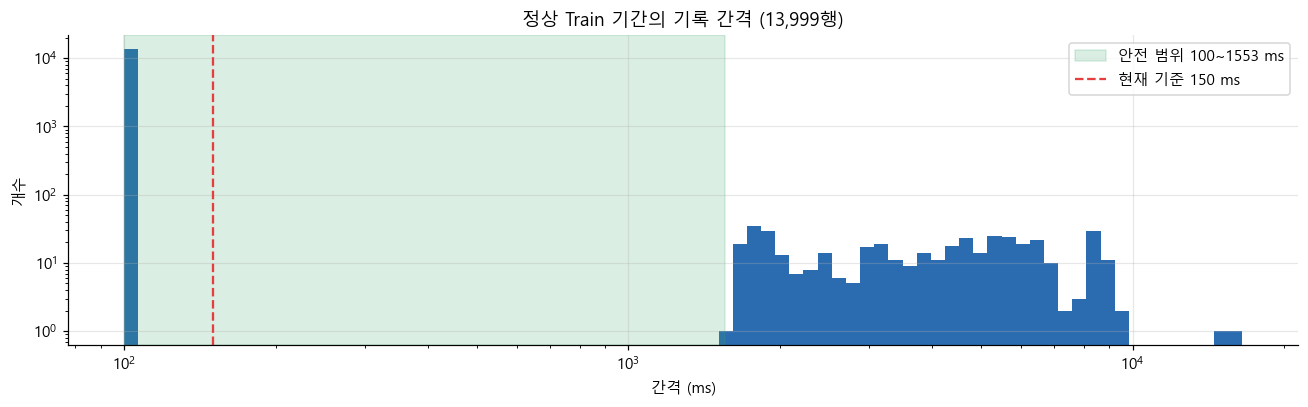

끊김 기준이 Train 기간 안전 범위 안에 있음: True


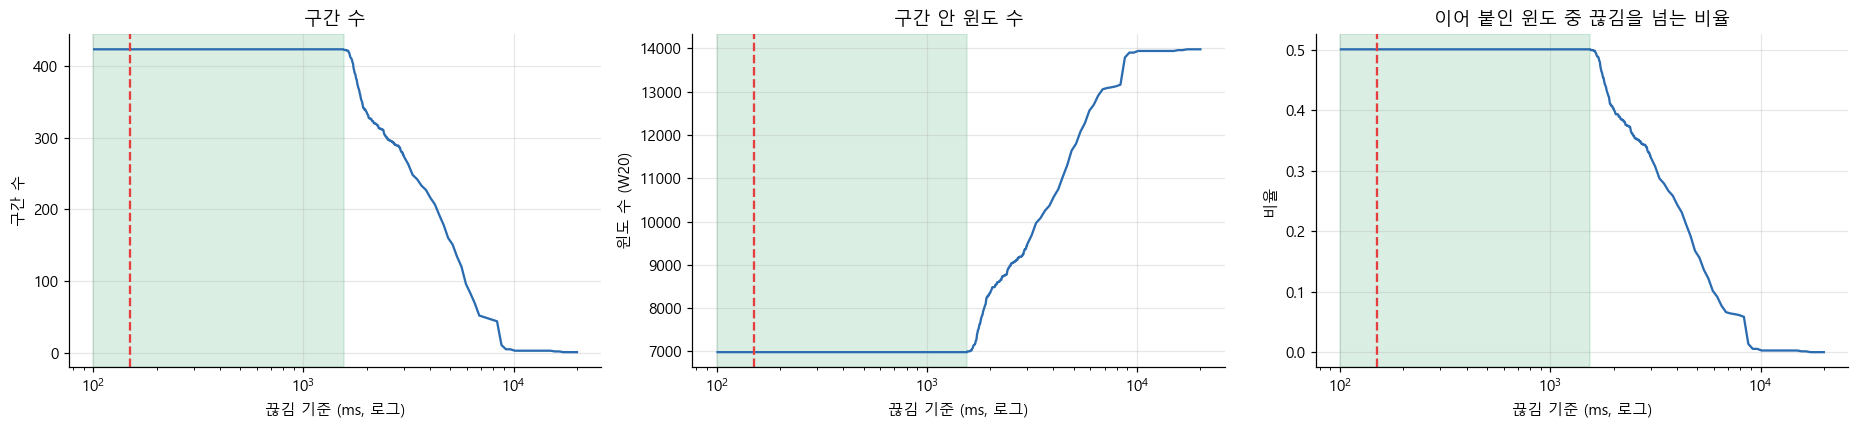

안전 범위 안에서 구간 수: 423~423개 (같으면 기준값을 그 안에서 어떻게 골라도 결과가 같음)


In [3]:
nrm_all = rows[rows.label == 0]
tr_period = nrm_all.iloc[:int(len(nrm_all) * NORMAL_RATIO[0])]
dt_ms = (tr_period.TimeStamp.diff() / pd.Timedelta(milliseconds=1)).dropna()
NOMINAL_MS = float(dt_ms.mode().iloc[0])
SAFE_LO = float(dt_ms[dt_ms <= 2 * NOMINAL_MS].max())
SAFE_HI = float(dt_ms[dt_ms > 2 * NOMINAL_MS].min())
GAP_OK = SAFE_LO < GAP_S * 1000 < SAFE_HI
check('끊김 기준을 Train 기간 간격으로만 확인', GAP_OK,
      f'Train 기간 안전 범위 {SAFE_LO:.0f}~{SAFE_HI:.0f} ms, 기준 {GAP_S * 1000:.0f} ms')
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.hist(dt_ms[dt_ms > 0], bins=np.geomspace(max(dt_ms[dt_ms > 0].min(), 1), dt_ms.max(), 80), color=COL[0])
ax.axvspan(SAFE_LO, SAFE_HI, color='#38a169', alpha=.18, label=f'안전 범위 {SAFE_LO:.0f}~{SAFE_HI:.0f} ms')
ax.axvline(GAP_S * 1000, color='#e53e3e', ls='--', label=f'현재 기준 {GAP_S * 1000:.0f} ms')
ax.set(xscale='log', yscale='log', title=f'정상 Train 기간의 기록 간격 ({len(tr_period):,}행)', xlabel='간격 (ms)', ylabel='개수')
ax.legend()
plt.tight_layout()
show('01_gap_train_only', '끊김 기준 점검: 정상 Train 기간의 간격만 사용')
print('끊김 기준이 Train 기간 안전 범위 안에 있음:', GAP_OK)

# ---- 끊김 기준 민감도: 기준값을 바꾸면 구간 수와 윈도가 어떻게 바뀌는지 (정상 Train 기간) ----
dtm = (tr_period.TimeStamp.diff() / pd.Timedelta(milliseconds=1)).to_numpy()
THR_MS = np.unique(np.r_[np.arange(101, 3001, 10), np.geomspace(3000, 20000, 40)]).astype(int)
sens_rows = []
for th in THR_MS:
    brk = np.r_[0, (dtm[1:] > th).astype(int)]               # 1 = 이 행에서 새 구간 시작
    seg_len = np.bincount(np.cumsum(brk))
    cb = np.cumsum(brk)
    n_cont = len(dtm) - WINDOW + 1                            # 끊김을 무시하고 이어 붙인 윈도 수
    cross = (cb[WINDOW - 1:] - cb[:n_cont]) > 0               # 윈도 안에 새 구간 시작이 있으면 끊김을 넘음
    sens_rows.append({'기준(ms)': th, '구간 수': len(seg_len), '구간 안 윈도 수': int(np.clip(seg_len - WINDOW + 1, 0, None).sum()),
                      '이어 붙인 윈도 중 끊김을 넘는 비율': float(cross.mean())})
SENS_TAB = pd.DataFrame(sens_rows)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, yl in [(axes[0], '구간 수', '구간 수'), (axes[1], '구간 안 윈도 수', f'윈도 수 (W{WINDOW})'),
                    (axes[2], '이어 붙인 윈도 중 끊김을 넘는 비율', '비율')]:
    ax.plot(SENS_TAB['기준(ms)'], SENS_TAB[col], color='#2b6cb0')
    ax.axvspan(SAFE_LO, SAFE_HI, color='#38a169', alpha=.18)
    ax.axvline(GAP_S * 1000, color='#e53e3e', ls='--')
    ax.set(xscale='log', title=col, xlabel='끊김 기준 (ms, 로그)', ylabel=yl)
plt.tight_layout()
show('01_gap_sensitivity', '끊김 기준값에 따른 구간 수, 구간 안 윈도 수, 이어 붙인 윈도의 끊김 비율 (정상 Train 기간, 초록 = 안전 범위)')
in_safe = SENS_TAB[(SENS_TAB['기준(ms)'] > SAFE_LO) & (SENS_TAB['기준(ms)'] < SAFE_HI)]
print(f'안전 범위 안에서 구간 수: {in_safe["구간 수"].min()}~{in_safe["구간 수"].max()}개 (같으면 기준값을 그 안에서 어떻게 골라도 결과가 같음)')

## 02 Train / Valid / Test 분할

**시간순 행 위치**로 자릅니다. 정상은 시간순 행의 70% / 80% 지점(13,999행 / 15,999행), 이상은 앞 200행 / 뒤 400행입니다. 120행 뒤 라벨 때문에 각 분할의 마지막 입력 행이 경계보다 약 100행 앞에서 끝납니다.

| 규칙 | 이유 |
|---|---|
| 시간 순서대로 | 과거로 학습하고 미래로 평가하는 현장 상황과 같게 합니다 |
| 이상은 Train에 없음 | 정상만 학습하고, 정상에서 벗어난 정도로 이상을 찾습니다 |
| Test는 따로 보관 | 분할이 끝나면 Test 행을 `_TEST_ROWS`로 옮기고 분석용 `rows`에서 지웁니다. 이후 셀은 Test를 쓰지 않습니다 |
| 분할 목록 저장 | 원본 행마다 어느 분할인지 `split_manifest.csv`에 적습니다. 나중에 다른 모델이 같은 분할을 쓰게 하기 위해서입니다 |

데이터,split,행,행 비율,구간(걸친 것 포함),시간
정상,train,13999,70.0%,423,07-12 00:00:00 ~ 00:53:15
정상,valid,2000,10.0%,59,07-12 00:53:15 ~ 01:01:00
정상,test,4000,20.0%,119,07-12 01:01:00 ~ 01:16:55
이상,valid,200,33.3%,7,07-17 10:51:07 ~ 10:52:01
이상,test,400,66.7%,15,07-17 10:52:01 ~ 10:53:53


분할 목록 저장: split_manifest.csv (20,600행, 중복으로 뺀 행 1개 포함)


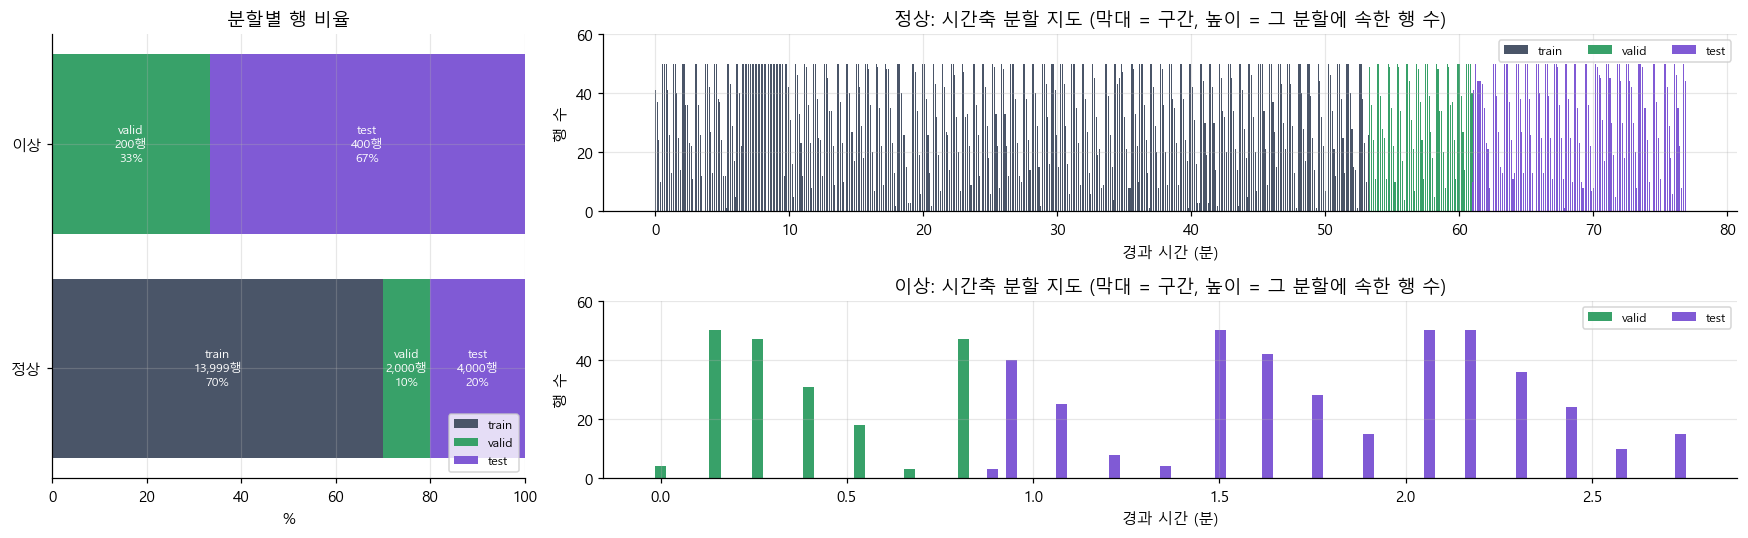

Test 4,400행을 따로 보관했습니다. 분석에는 16,199행(Train+Valid)만 씁니다.


In [4]:
segs = (rows.groupby(['label', 'segment'], sort=False)
        .agg(n_rows=('pos', 'size'), start=('TimeStamp', 'min'), end=('TimeStamp', 'max')).reset_index()
        .sort_values(['label', 'start']).reset_index(drop=True))
SEG_POS = dict(zip(segs.segment, segs.groupby('label').cumcount()))   # 구간의 시간 순서


def split_by_segments(n_rows, ratios):
    cum = np.r_[0, np.cumsum(n_rows)]
    cuts = [int(np.argmin(np.abs(cum - b * cum[-1]))) for b in np.cumsum(ratios)[:-1]]
    edges = [0, *cuts, len(n_rows)]
    out = np.empty(len(n_rows), dtype=object)
    for name, a, b in zip(['train', 'valid', 'test'], edges[:-1], edges[1:]):
        out[a:b] = name
    return out


rows['split'] = ''
for lab, ratio in [(0, NORMAL_RATIO), (1, ANOMALY_RATIO)]:
    if SPLIT_MODE == 'segment':
        m = segs.label == lab
        seg_split = dict(zip(segs.loc[m, 'segment'], split_by_segments(segs.loc[m, 'n_rows'].to_numpy(), ratio)))
        rows.loc[rows.label == lab, 'split'] = rows.loc[rows.label == lab, 'segment'].map(seg_split)
    else:
        # 행 단위: 시간순 행의 비율 지점에서 자름 (내림)
        idx = rows.index[rows.label == lab]
        c1 = int(np.floor(ratio[0] * len(idx) + 1e-9))
        c2 = int(np.floor((ratio[0] + ratio[1]) * len(idx) + 1e-9))
        rows.loc[idx[:c1], 'split'] = 'train'
        rows.loc[idx[c1:c2], 'split'] = 'valid'
        rows.loc[idx[c2:], 'split'] = 'test'
rows['block'] = rows['segment'] if RESPECT_GAPS else rows['label'].astype(str) + '_' + rows['split']

# ---- 분리 점검 (구조 정보만 사용) ----
order_ok = True
for lab in (0, 1):
    r = rows[rows.label == lab]
    present = [sp for sp in ['train', 'valid', 'test'] if (r.split == sp).any()]
    for a, b in zip(present[:-1], present[1:]):
        order_ok &= bool(r[r.split == a].TimeStamp.max() < r[r.split == b].TimeStamp.min())
check('시간 순서 Train < Valid < Test', order_ok, '과거로 학습하고 미래로 평가')
check('이상 데이터는 Train에 없음', not bool(((rows.label == 1) & (rows.split == 'train')).any()), '정상만 학습')
check('행은 분할끼리 겹치지 않음', bool(rows.groupby(['file', 'raw_row']).split.nunique().eq(1).all()), '원본 행 하나는 한 분할에만 속함')
CUT_SEGS = rows.groupby('segment').split.nunique().gt(1)
N_CUT = int(CUT_SEGS.sum())
if SPLIT_MODE == 'segment':
    check('분할 경계가 연속 기록을 자르지 않음', N_CUT == 0, '끊긴 곳에서만 나눔')

SPLIT_TAB = rows.groupby(['label', 'split']).agg(행=('ord', 'size'), 구간=('segment', 'nunique'),
                                                  시작=('TimeStamp', 'min'), 끝=('TimeStamp', 'max')).reset_index()
SPLIT_TAB['행 비율'] = (SPLIT_TAB['행'] / SPLIT_TAB.groupby('label')['행'].transform('sum')).map('{:.1%}'.format)
SPLIT_TAB['시간'] = [f'{a:%m-%d %H:%M:%S} ~ {b:%H:%M:%S}' for a, b in zip(SPLIT_TAB['시작'], SPLIT_TAB['끝'])]
SPLIT_TAB['데이터'] = SPLIT_TAB['label'].map(LAB)
SPLIT_TAB['split'] = pd.Categorical(SPLIT_TAB['split'], ['train', 'valid', 'test'])
SPLIT_TAB = SPLIT_TAB.sort_values(['label', 'split'])[['데이터', 'split', '행', '행 비율', '구간', '시간']]
SPLIT_TAB = SPLIT_TAB.rename(columns={'구간': '구간(걸친 것 포함)'})
display(SPLIT_TAB.style.hide(axis='index'))


save_table(SPLIT_TAB, 'split_summary', index=False)

# ---- 분할 목록 저장: 원본 CSV 행 번호마다 분할을 적음 ----
MANIFEST = rows[['file', 'raw_row', 'ord', 'TimeStamp', 'label', 'segment', 'split']].copy()
if DUP_ROWS:
    MANIFEST = pd.concat([MANIFEST, pd.DataFrame(DUP_ROWS, columns=['file', 'raw_row']).assign(split='removed_duplicate')])
MANIFEST = MANIFEST.sort_values(['file', 'raw_row']).reset_index(drop=True)
MANIFEST['variant'] = VARIANT
save_table(MANIFEST, 'split_manifest', index=False)
print(f'분할 목록 저장: split_manifest.csv ({len(MANIFEST):,}행, 중복으로 뺀 행 {len(DUP_ROWS)}개 포함)')

fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 2.4])
ax = fig.add_subplot(gs[:, 0])
left = np.zeros(2)
for sp in ['train', 'valid', 'test']:
    v = np.array([((rows.label == l) & (rows.split == sp)).sum() for l in (0, 1)])
    pct = v / np.array([(rows.label == l).sum() for l in (0, 1)]) * 100
    ax.barh([LAB[0], LAB[1]], pct, left=left, color=SPLIT_COL[sp], label=sp)
    for i, (vv, pp, ll) in enumerate(zip(v, pct, left)):
        if vv:
            ax.text(ll + pp / 2, i, f'{sp}\n{vv:,}행\n{pp:.0f}%', ha='center', va='center', color='white', fontsize=8)
    left += pct
ax.set(title='분할별 행 비율', xlim=(0, 100), xlabel='%')
ax.legend(fontsize=8, loc='lower right')
pieces = rows.groupby(['label', 'segment', 'split'], sort=False).agg(start=('TimeStamp', 'min'), n=('ord', 'size')).reset_index()
for k, lab in enumerate([0, 1]):
    ax = fig.add_subplot(gs[k, 1])
    s = pieces[pieces.label == lab]
    t0 = s.start.min()
    for sp in ['train', 'valid', 'test']:
        g = s[s.split == sp]
        if len(g):
            ax.bar((g.start - t0).dt.total_seconds() / 60, g.n, width=.08 if lab == 0 else .03, color=SPLIT_COL[sp], label=sp)
    ax.set(title=f'{LAB[lab]}: 시간축 분할 지도 (막대 = 구간, 높이 = 그 분할에 속한 행 수)', xlabel='경과 시간 (분)',
           ylabel='행 수', ylim=(0, 60))
    ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
show('02_split', f'{VARIANT} 분할: 정상 7:1:2, 이상 0:1:2')

# ---- Test 따로 보관: 이 아래 분석 셀은 Train과 Valid만 씁니다 ----
_TEST_ROWS = rows[rows.split == 'test'].reset_index(drop=True)
rows = rows[rows.split != 'test'].reset_index(drop=True)
check('분석용 데이터에서 Test 행 제거', set(rows.split.unique()) <= {'train', 'valid'},
      f'Test {len(_TEST_ROWS):,}행은 따로 보관하고 분석에 쓰지 않음')
print(f'Test {len(_TEST_ROWS):,}행을 따로 보관했습니다. 분석에는 {len(rows):,}행(Train+Valid)만 씁니다.')

### 02-2 시간 간격과 끊김 (Train+Valid)

분할이 끝난 뒤 **Train과 Valid만으로** 기록 간격과 끊김의 구조를 봅니다. Test 구간이 빠지므로 종합분석의 숫자보다 조금 작게 나옵니다.

| 용어 | 뜻 |
|---|---|
| **interval(간격)** | 바로 앞 기록과의 시간 차이. 타임스탬프 최소 단위인 1 ms로 셉니다 |
| **gap(끊김)** | 간격이 `GAP_S`보다 긴 곳 |
| **segment(구간)** | 끊김 없이 이어진 기록 덩어리 |

- **요약 표**: 행 수, 정확히 100 ms 간격의 비율, 끊김 수와 길이, 구간 수와 길이입니다.
- **끊김 파형**: 앞부분 전류 파형에 끊김을 빨간 띠로 표시합니다.
- **간격 분포**: 간격 범위별 개수, 0~300 ms를 1 ms 칸으로 센 히스토그램, 전체 간격의 누적 비율입니다.
- **끊김 길이**: 정상과 이상의 끊김 길이 분포입니다. 이상 Valid는 구간이 7개라 끊김이 6개뿐이니 참고로만 보세요.
- **재시작 근거**: 샘플 몇 개만 빠진 것이라면 끊김 길이가 100 ms 배수에 딱 맞고, 구간마다 박자 위치(시작 시각 % 100 ms)가 같아야 합니다. 그렇지 않으면 기록이 멈췄다가 새 박자로 다시 시작된 것입니다.
- **구간 길이**: 구간 안 간격의 흔들림, 구간 길이 분포(점선 = 윈도 길이 16, 20, 30, 50행), 시간에 따른 구간 길이입니다.

,행,정확히 100 ms 간격,끊김 수,끊김 길이 최소(초),끊김 길이 중앙값(초),끊김 길이 최대(초),구간 수,구간 길이 중앙값(행),가장 긴 구간(행)
데이터,,,,,,,,,
정상,15999,97.0%,480,1.6,4.2,16.5,481,37,50
이상,200,97.0%,6,2.0,5.8,8.5,7,31,50


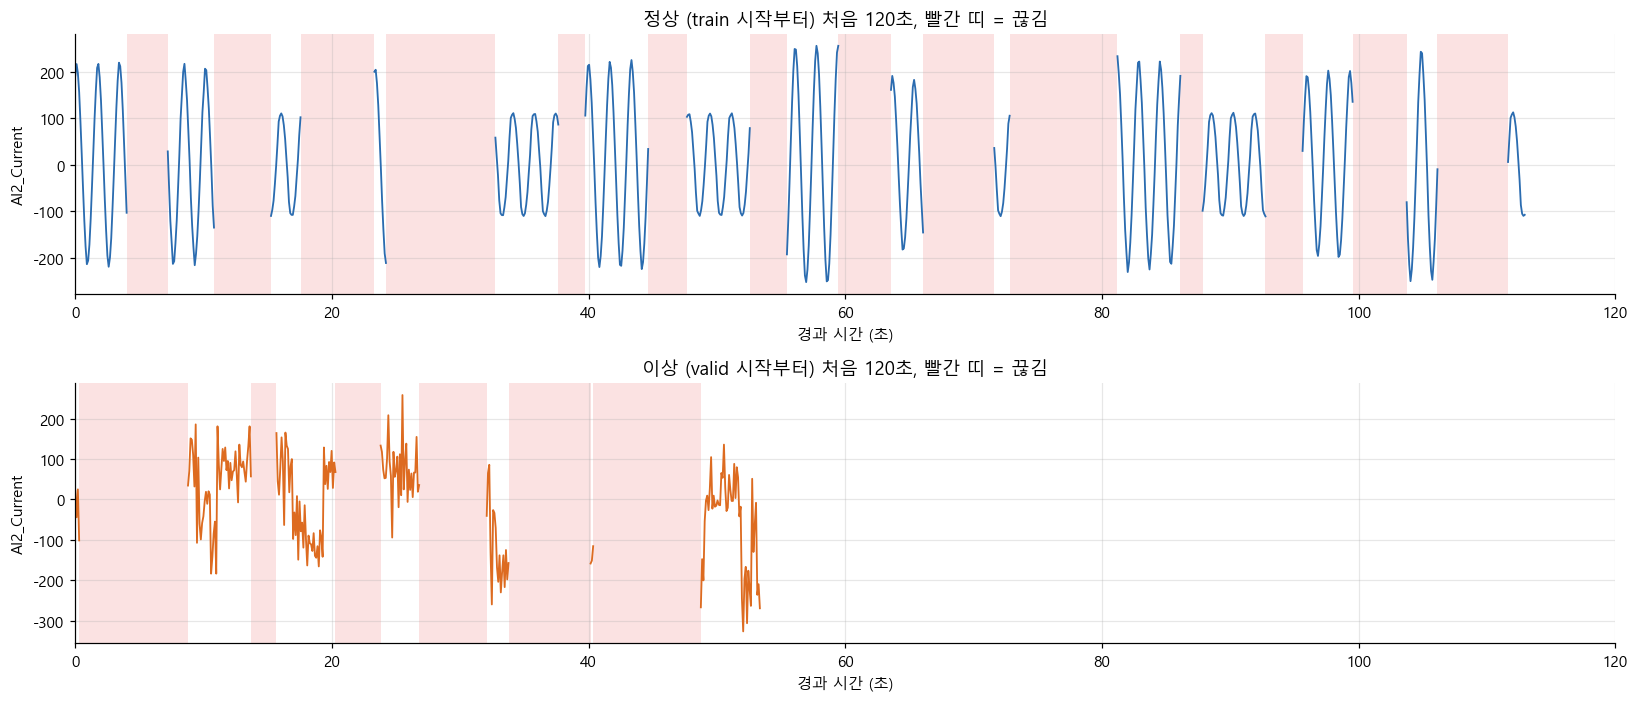

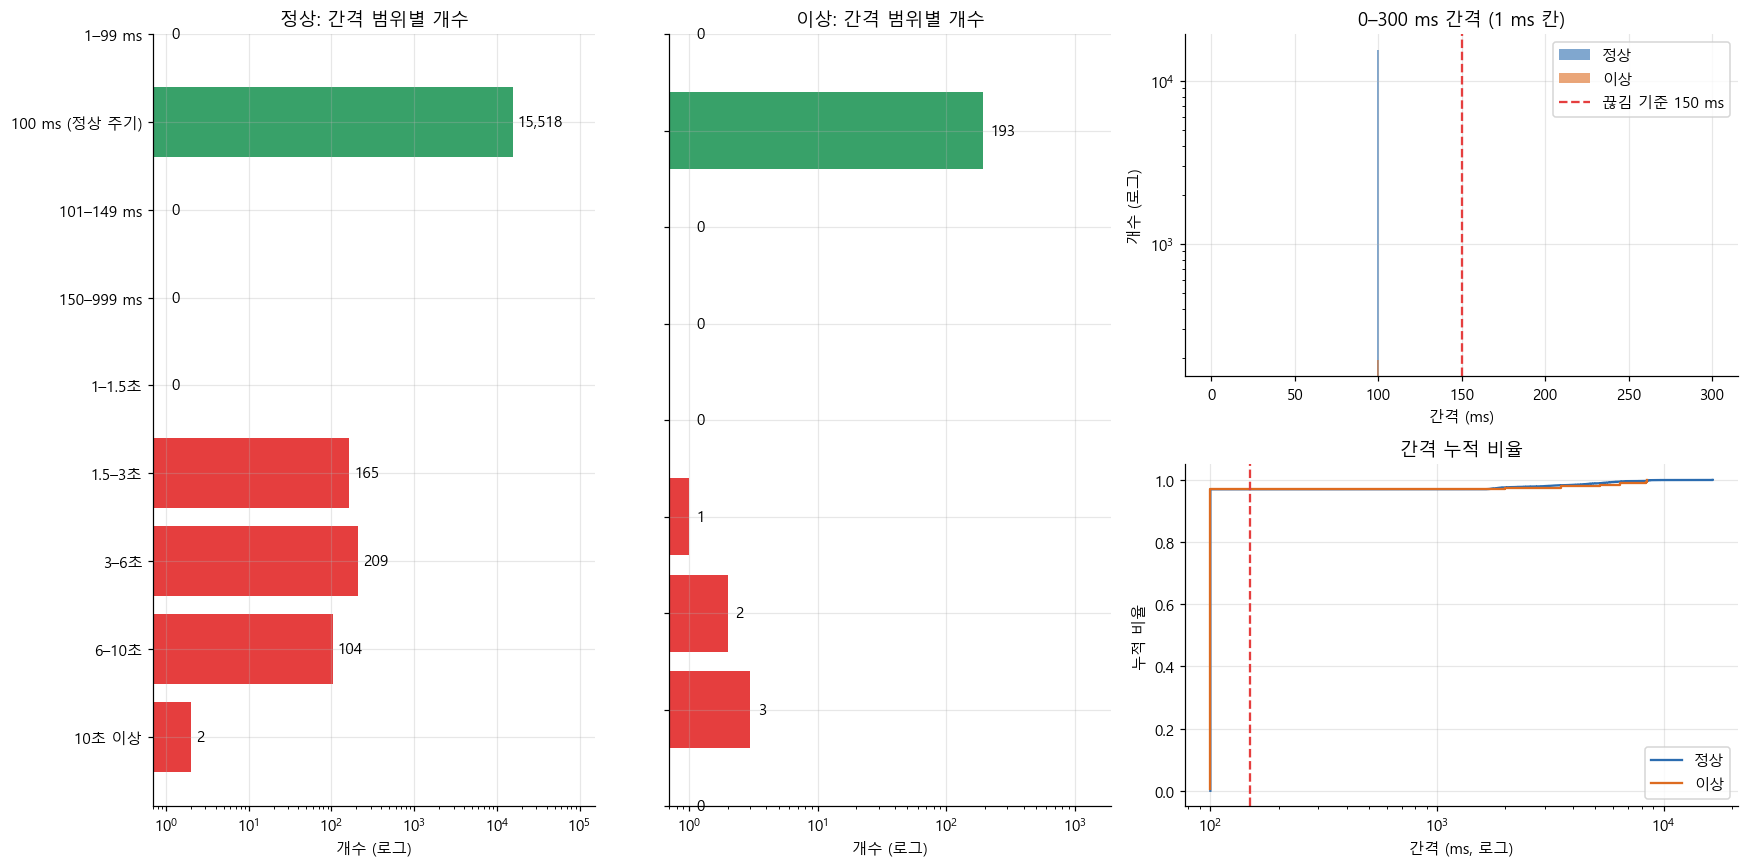

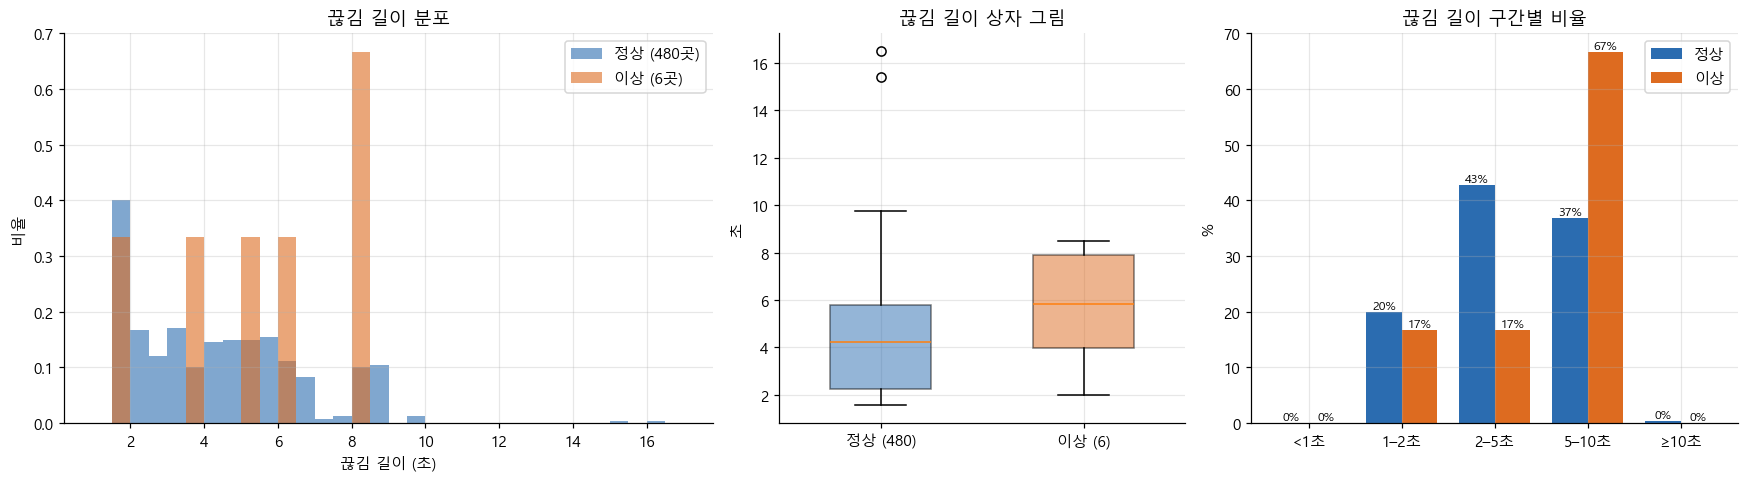

,정상,이상
끊김 길이,,
<1초,0%,0%
1–2초,20%,17%
2–5초,43%,17%
5–10초,37%,67%
≥10초,0%,0%


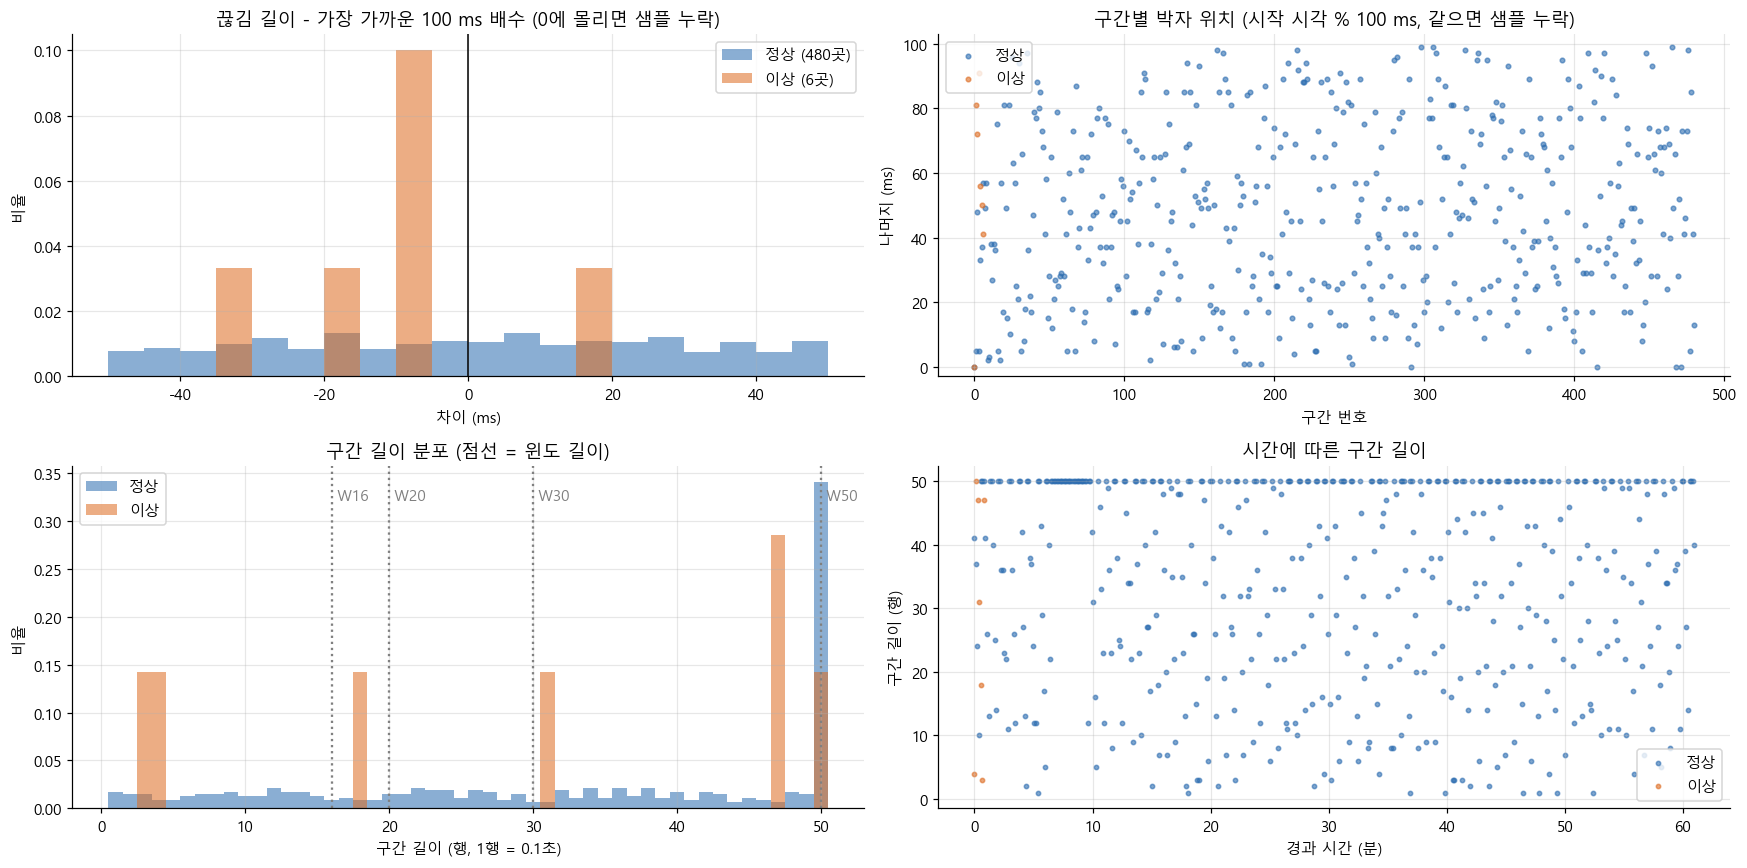

,끊김 수,100 ms 배수에서 ±5 ms 이내 비율,구간 박자 위치 표준편차(ms),구간 안 간격이 정확히 100 ms인 비율
데이터,,,,
정상,480,12%,27.6,100.0%
이상,6,0%,30.3,100.0%


In [5]:
IV = {}
for lab in (0, 1):
    d = rows[rows.label == lab].sort_values('ord')
    t_ms = ((d.TimeStamp - d.TimeStamp.min()) / pd.Timedelta(milliseconds=1)).round().to_numpy()
    IV[lab] = d.assign(t_ms=t_ms, dt_ms=np.r_[np.nan, np.diff(t_ms)], t_sec=t_ms / 1000)
GAP_MS = GAP_S * 1000
iv_rows, GAPS = [], {}
for lab, d in IV.items():
    dt = pd.Series(d.dt_ms).dropna()
    g = dt[dt > GAP_MS] / 1000
    GAPS[lab] = g
    L = d.groupby('segment').size()
    iv_rows.append({'데이터': LAB[lab], '행': len(d), f'정확히 {NOMINAL_MS:.0f} ms 간격': f'{(dt == NOMINAL_MS).mean():.1%}',
                    '끊김 수': len(g), '끊김 길이 최소(초)': g.min(), '끊김 길이 중앙값(초)': g.median(), '끊김 길이 최대(초)': g.max(),
                    '구간 수': len(L), '구간 길이 중앙값(행)': float(L.median()), '가장 긴 구간(행)': int(L.max())})
INTV_TAB = pd.DataFrame(iv_rows).set_index('데이터')
display(INTV_TAB.style.format({'끊김 길이 최소(초)': '{:.1f}', '끊김 길이 중앙값(초)': '{:.1f}', '끊김 길이 최대(초)': '{:.1f}',
                               '구간 길이 중앙값(행)': '{:.0f}'}).set_caption('Train+Valid의 기록 간격과 끊김'))

# ---- 끊김 파형: 앞부분 전류 ----
TIMELINE_SEC = 120
fig, axes = plt.subplots(2, 1, figsize=(15, 6.5))
for ax, (lab, d) in zip(axes, IV.items()):
    part = d[d.t_sec <= TIMELINE_SEC]
    for _, s in part.groupby('segment', sort=False):
        ax.plot(s.t_sec, s['AI2_Current'], color=COL[lab], lw=1.2)
    ends = part.groupby('segment', sort=False).t_sec.agg(['first', 'last'])
    for a, b in zip(ends['last'].iloc[:-1], ends['first'].iloc[1:]):
        ax.axvspan(a, b, color='#e53e3e', alpha=.15, lw=0)
    first_split = part.split.iloc[0]
    ax.set(title=f'{LAB[lab]} ({first_split} 시작부터) 처음 {TIMELINE_SEC}초, 빨간 띠 = 끊김', xlabel='경과 시간 (초)',
           ylabel='AI2_Current', xlim=(0, TIMELINE_SEC))
plt.tight_layout()
show('02b_gap_waveform', '앞부분 전류 파형과 끊김(빨간 띠)')

# ---- 간격 분포 ----
BANDS_IV = [('1–99 ms', 1, 99), (f'{NOMINAL_MS:.0f} ms (정상 주기)', NOMINAL_MS, NOMINAL_MS), ('101–149 ms', 101, 149),
            ('150–999 ms', 150, 999), ('1–1.5초', 1000, 1499), ('1.5–3초', 1500, 2999), ('3–6초', 3000, 5999),
            ('6–10초', 6000, 9999), ('10초 이상', 10000, np.inf)]
fig = plt.figure(figsize=(16, 8))
gsx = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.25])
for k, (lab, d) in enumerate(IV.items()):
    ax = fig.add_subplot(gsx[:, k])
    vals = np.array([((d.dt_ms >= lo) & (d.dt_ms <= hi)).sum() for _, lo, hi in BANDS_IV])
    colors = ['#38a169' if hi == NOMINAL_MS else '#e53e3e' if lo >= GAP_MS else '#a0aec0' for _, lo, hi in BANDS_IV]
    yy = np.arange(len(BANDS_IV))[::-1]
    ax.barh(yy, np.where(vals > 0, vals, np.nan), color=colors)
    for yi, v in zip(yy, vals):
        ax.text(max(v, 1) * 1.15, yi, f'{v:,}', va='center', fontsize=10)
    ax.set_xscale('log'); ax.set_xlim(.7, max(vals.max(), 1) * 10)
    ax.set_yticks(yy, [b[0] for b in BANDS_IV] if k == 0 else [''] * len(BANDS_IV))
    ax.set(title=f'{LAB[lab]}: 간격 범위별 개수', xlabel='개수 (로그)')
ax = fig.add_subplot(gsx[0, 2])
for lab, d in IV.items():
    dt = pd.Series(d.dt_ms).dropna()
    ax.hist(dt[dt <= 300], bins=np.arange(-.5, 301.5, 1), color=COL[lab], alpha=.6, label=LAB[lab])
ax.axvline(GAP_MS, color='#e53e3e', ls='--', label=f'끊김 기준 {GAP_MS:.0f} ms')
ax.set(title='0–300 ms 간격 (1 ms 칸)', xlabel='간격 (ms)', ylabel='개수 (로그)', yscale='log'); ax.legend()
ax = fig.add_subplot(gsx[1, 2])
for lab, d in IV.items():
    x = np.sort(pd.Series(d.dt_ms).dropna().to_numpy())
    x = x[x > 0]
    ax.step(x, np.arange(1, len(x) + 1) / len(x), where='post', color=COL[lab], label=LAB[lab])
ax.axvline(GAP_MS, color='#e53e3e', ls='--')
ax.set(title='간격 누적 비율', xlabel='간격 (ms, 로그)', ylabel='누적 비율', xscale='log'); ax.legend()
plt.tight_layout()
show('02b_intervals', '기록 간격 분포: 범위별 개수, 1 ms 히스토그램, 누적 비율 (Train+Valid)')

# ---- 끊김 길이 ----
GAP_EDGES, GAP_NAMES = [0, 1, 2, 5, 10, np.inf], ['<1초', '1–2초', '2–5초', '5–10초', '≥10초']
GAP_SHARE = pd.DataFrame({LAB[lab]: pd.cut(g, GAP_EDGES, right=False).value_counts(sort=False).values / max(len(g), 1)
                          for lab, g in GAPS.items()}, index=GAP_NAMES)
GAP_SHARE.index.name = '끊김 길이'
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={'width_ratios': [1.6, 1, 1.2]})
for lab, g in GAPS.items():
    axes[0].hist(g, bins=np.arange(1, 17.5, .5), color=COL[lab], alpha=.6, density=True, label=f'{LAB[lab]} ({len(g)}곳)')
axes[0].set(title='끊김 길이 분포', xlabel='끊김 길이 (초)', ylabel='비율'); axes[0].legend()
bp = axes[1].boxplot([GAPS[0], GAPS[1]], patch_artist=True, widths=.5)
axes[1].set_xticks([1, 2], [f'{LAB[0]} ({len(GAPS[0])})', f'{LAB[1]} ({len(GAPS[1])})'])
for p, lab in zip(bp['boxes'], (0, 1)):
    p.set_facecolor(COL[lab]); p.set_alpha(.5)
axes[1].set(title='끊김 길이 상자 그림', ylabel='초')
xx = np.arange(len(GAP_NAMES))
for k, lab in enumerate((0, 1)):
    b = axes[2].bar(xx + (k - .5) * .38, GAP_SHARE[LAB[lab]] * 100, .38, color=COL[lab], label=LAB[lab])
    axes[2].bar_label(b, labels=[f'{v:.0%}' for v in GAP_SHARE[LAB[lab]]], fontsize=8)
axes[2].set_xticks(xx, GAP_NAMES); axes[2].set(title='끊김 길이 구간별 비율', ylabel='%'); axes[2].legend()
plt.tight_layout()
show('02b_gap_length', '끊김 길이 (Train+Valid, 괄호 = 끊김 수)')
display(GAP_SHARE.style.format('{:.0%}').set_caption('끊김 길이 구간별 비율'))

# ---- 재시작 근거와 구간 길이 ----
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
RESTART = {}
for lab, d in IV.items():
    g_ms = pd.Series(d.dt_ms)[pd.Series(d.dt_ms) > GAP_MS]
    resid = g_ms - (g_ms / NOMINAL_MS).round() * NOMINAL_MS
    phase = d.groupby('segment', sort=False).t_ms.first() % NOMINAL_MS
    RESTART[LAB[lab]] = {'끊김 수': len(g_ms), '100 ms 배수에서 ±5 ms 이내 비율': float((resid.abs() <= 5).mean()) if len(g_ms) else np.nan,
                         '구간 박자 위치 표준편차(ms)': float(phase.std())}
    axes[0, 0].hist(resid, bins=np.arange(-50, 52, 5), color=COL[lab], alpha=.55, density=True, label=f'{LAB[lab]} ({len(g_ms)}곳)')
    axes[0, 1].scatter(np.arange(len(phase)), phase.values, s=9, color=COL[lab], alpha=.6, label=LAB[lab])
    L = d.groupby('segment', sort=False).agg(start=('t_sec', 'first'), n=('t_sec', 'size'))
    axes[1, 0].hist(L.n, bins=np.arange(.5, L.n.max() + 1.5, 1), color=COL[lab], alpha=.55, density=True, label=LAB[lab])
    axes[1, 1].scatter(L.start / 60, L.n, s=8, color=COL[lab], alpha=.6, label=LAB[lab])
axes[0, 0].axvline(0, color='black', lw=1)
axes[0, 0].set(title=f'끊김 길이 - 가장 가까운 {NOMINAL_MS:.0f} ms 배수 (0에 몰리면 샘플 누락)', xlabel='차이 (ms)', ylabel='비율'); axes[0, 0].legend()
axes[0, 1].set(title=f'구간별 박자 위치 (시작 시각 % {NOMINAL_MS:.0f} ms, 같으면 샘플 누락)', xlabel='구간 번호', ylabel='나머지 (ms)', ylim=(-3, 103))
axes[0, 1].legend()
for w in (16, 20, 30, 50):
    axes[1, 0].axvline(w, color='gray', ls=':')
    axes[1, 0].text(w, axes[1, 0].get_ylim()[1] * .9, f' W{w}', color='gray')
axes[1, 0].set(title='구간 길이 분포 (점선 = 윈도 길이)', xlabel='구간 길이 (행, 1행 = 0.1초)', ylabel='비율'); axes[1, 0].legend()
axes[1, 1].set(title='시간에 따른 구간 길이', xlabel='경과 시간 (분)', ylabel='구간 길이 (행)'); axes[1, 1].legend()
plt.tight_layout()
show('02b_restart_segments', '재시작 근거(위)와 구간 길이(아래), Train+Valid')
RESTART_TAB = pd.DataFrame(RESTART).T
RESTART_TAB.index.name = '데이터'
JITTER = {LAB[lab]: f"{((pd.Series(d.dt_ms) > 0) & (pd.Series(d.dt_ms) <= GAP_MS) & (pd.Series(d.dt_ms) == NOMINAL_MS)).sum() / ((pd.Series(d.dt_ms) > 0) & (pd.Series(d.dt_ms) <= GAP_MS)).sum():.1%}"
          for lab, d in IV.items()}
RESTART_TAB['구간 안 간격이 정확히 100 ms인 비율'] = [JITTER[i] for i in RESTART_TAB.index]
display(RESTART_TAB.style.format({'100 ms 배수에서 ±5 ms 이내 비율': '{:.0%}', '구간 박자 위치 표준편차(ms)': '{:.1f}', '끊김 수': '{:.0f}'})
        .set_caption('재시작 근거: 샘플 누락이면 ±5 ms 이내 비율이 100%에 가깝고 박자 위치 표준편차가 0에 가까움. 무작위 재시작이면 각각 약 10%, 약 29 ms'))

## 03 원 신호: 분포, 센서 간 상관, 고윳값, 시간 구조

여기부터는 **Train + Valid만** 씁니다.

- **03-1 분포**: 센서 값(부호 유지)이 정상과 이상에서 어떻게 다른지 봅니다.
- **03-2 상관과 고윳값**: 센서 3개의 상관행렬과 그 고윳값입니다. 상관은 **윈도를 만드는 단위(블록)마다 평균을 뺀 뒤** 계산합니다. 블록은 공백을 고려하면 구간, 무시하면 분할 전체입니다. 블록 사이의 평균 수준 차이가 상관에 섞이지 않게 하고, 자기상관과 기준을 맞추기 위해서입니다.

> **상관계수는 이 노트북 전체에서 피어슨 하나로 통일합니다.** PCA·고윳값·VIF·마할라노비스 거리도 모두 피어슨 상관(공분산)을 바탕으로 합니다. 06-2 단계에서 스피어만과 거의 같은지 한 번 확인합니다.

- 고윳값 1번 비중이 크면 세 센서가 한 방향으로 같이 움직인다는 뜻입니다.
- **03-3 자기상관·시차 상호상관**: 블록 안에서 계산합니다. 공백을 무시하는 폴더는 끊김을 넘어 이어진 신호로 계산합니다.
- **03-4 값 분포**: 누적 분포와, 절댓값으로 바꿨을 때의 분포입니다.
- **03-5 파형**: 상태별 전체 파형, 가장 긴 구간 확대, (공백을 무시하는 폴더만) 이어 붙인 파형입니다.

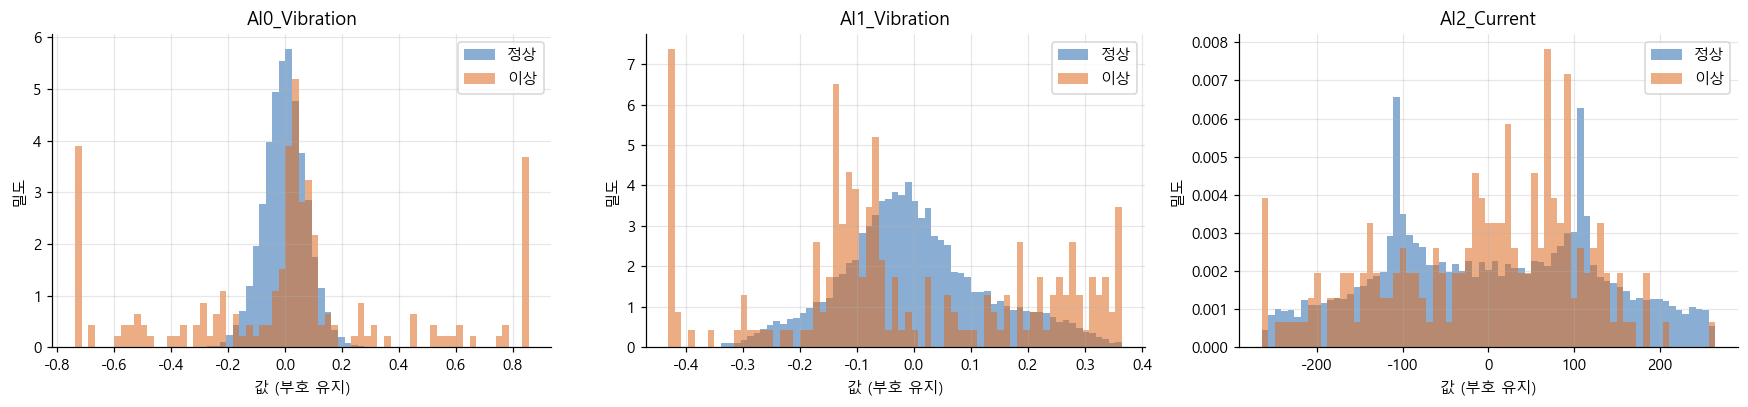

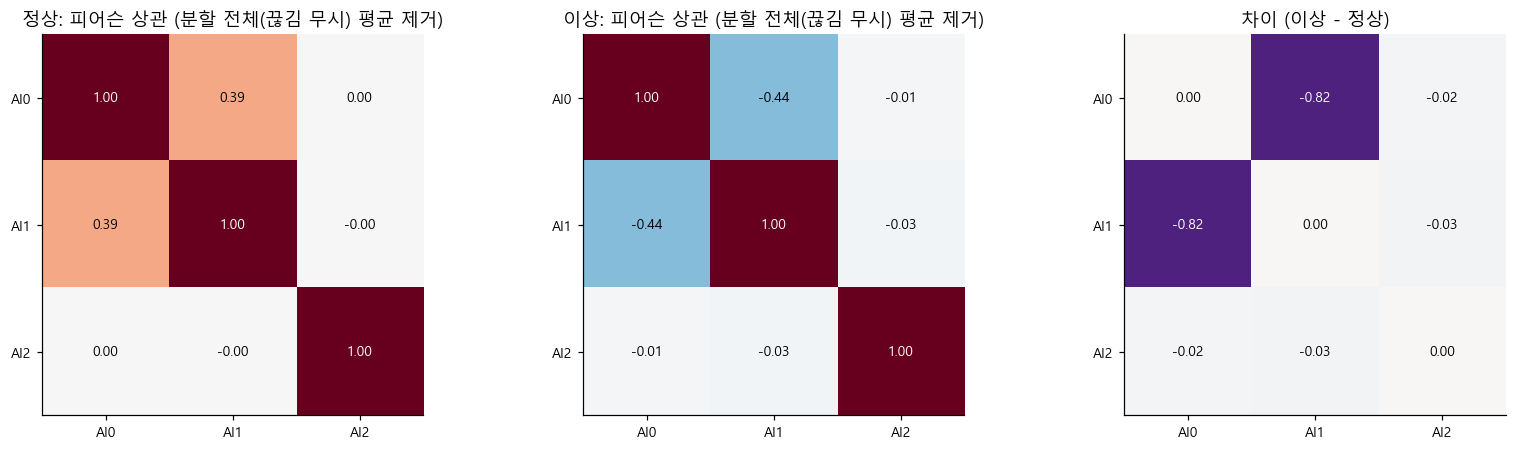

,고윳값 1,고윳값 2,고윳값 3,1번 비중
데이터,,,,
정상,1.39,1.00,0.61,46%
이상,1.44,1.00,0.56,48%


In [6]:
DEV = rows.copy()
BLOCK_NAME = '구간' if RESPECT_GAPS else '분할 전체(끊김 무시)'

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, s in zip(axes, SENSORS):
    lo, hi = DEV[s].quantile([.001, .999])
    bins = np.linspace(lo, hi, 70)
    for lab in (0, 1):
        ax.hist(DEV.loc[DEV.label == lab, s].clip(lo, hi), bins=bins, density=True, alpha=.55, color=COL[lab], label=LAB[lab])
    ax.set(title=s, xlabel='값 (부호 유지)', ylabel='밀도')
    ax.legend()
plt.tight_layout()
show('03_1_raw_dist', '센서 값 분포 (Train+Valid)')

RAW_CORR, eig_rows = {}, []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for k, lab in enumerate([0, 1]):
    d = DEV[DEV.label == lab]
    centered = d[SENSORS] - d.groupby('block')[SENSORS].transform('mean')
    RAW_CORR[lab] = centered.corr()
    heat(axes[k], RAW_CORR[lab], f'{LAB[lab]}: 피어슨 상관 ({BLOCK_NAME} 평균 제거)')
    ev = np.linalg.eigvalsh(RAW_CORR[lab].to_numpy())[::-1]
    eig_rows.append({'데이터': LAB[lab], '고윳값 1': ev[0], '고윳값 2': ev[1], '고윳값 3': ev[2], '1번 비중': f'{ev[0] / ev.sum():.0%}'})
heat(axes[2], RAW_CORR[1] - RAW_CORR[0], '차이 (이상 - 정상)', cmap='PuOr_r')
plt.tight_layout()
show('03_2_raw_corr', f'센서 간 상관 (Train+Valid, {BLOCK_NAME}마다 평균 제거)')
RAW_EIG = pd.DataFrame(eig_rows).set_index('데이터')
display(RAW_EIG.style.format({c: '{:.2f}' for c in ['고윳값 1', '고윳값 2', '고윳값 3']})
        .set_caption('센서 3개 상관행렬(피어슨)의 고윳값. 합은 3입니다'))

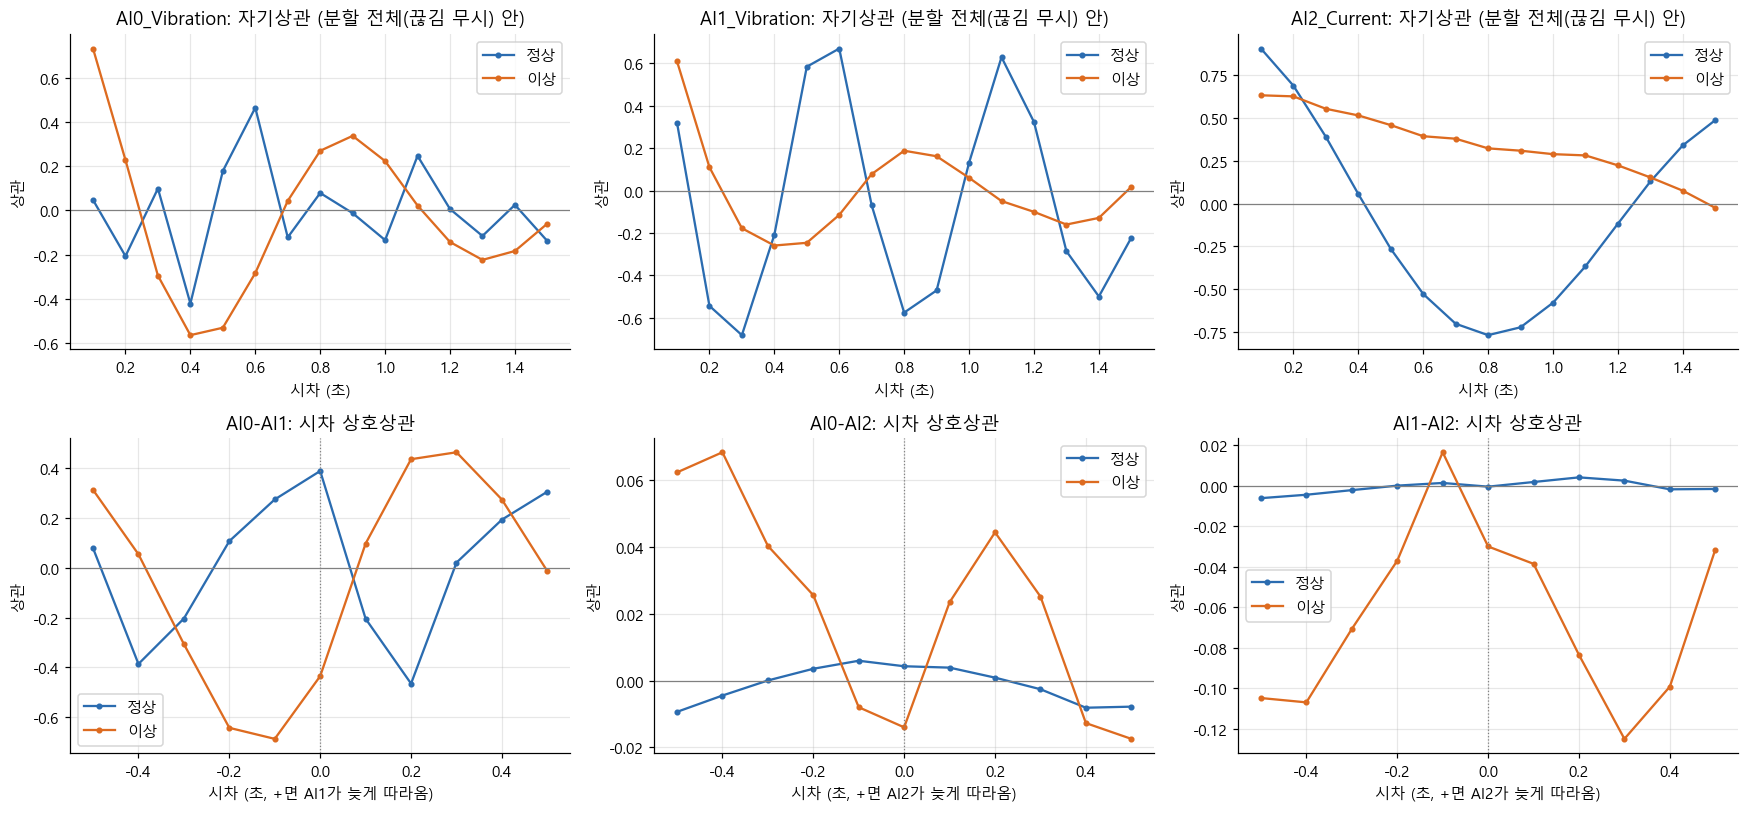

센서,데이터,0.1초 뒤 자기상관,추정 주기(초),가장 강한 반복(최대 자기상관)
AI0_Vibration,정상,0.05,0.6,0.46
AI0_Vibration,이상,0.73,0.9,0.34
AI1_Vibration,정상,0.32,0.6,0.67
AI1_Vibration,이상,0.61,없음,0.19
AI2_Current,정상,0.90,1.6,0.69
AI2_Current,이상,0.63,없음,0.62


센서 쌍,데이터,시차 0 상관,가장 강한 시차(초),그때 상관
AI0-AI1,정상,0.39,0.2,-0.47
AI0-AI1,이상,-0.44,-0.1,-0.69
AI0-AI2,정상,0.00,-0.5,-0.01
AI0-AI2,이상,-0.01,-0.4,0.07
AI1-AI2,정상,-0.00,-0.5,-0.01
AI1-AI2,이상,-0.03,0.3,-0.12


In [7]:
def block_series(df, col):
    # 블록마다 평균을 뺀 신호 목록
    return [g[col].to_numpy() - g[col].mean() for _, g in df.groupby('block', sort=False) if len(g) > 2]


def lag_corr(xs, ys, k):
    a, b = [], []
    for x, y in zip(xs, ys):
        n = len(x)
        if n <= abs(k) + 1:
            continue
        if k >= 0:
            a.append(x[:n - k]); b.append(y[k:])
        else:
            a.append(x[-k:]); b.append(y[:n + k])
    return np.corrcoef(np.concatenate(a), np.concatenate(b))[0, 1]


LAGS_ACF = np.arange(1, 16)
LAGS_CCF = np.arange(-5, 6)
PAIRS = [('AI0_Vibration', 'AI1_Vibration'), ('AI0_Vibration', 'AI2_Current'), ('AI1_Vibration', 'AI2_Current')]
ser = {lab: {s: block_series(DEV[DEV.label == lab], s) for s in SENSORS} for lab in (0, 1)}


def period_from_acf(v):
    # 첫 번째 뚜렷한 봉우리(> 0.3)의 시차를 주기로 봅니다. 봉우리가 범위 밖이면 가장 깊은 골(< -0.5)의 2배로 추정합니다.
    for k in range(1, len(v) - 1):
        if v[k] > v[k - 1] and v[k] >= v[k + 1] and v[k] > .3:
            return LAGS_ACF[k] * PERIOD_S
    k = int(np.argmin(v))
    if v[k] < -.5 and 0 < k < len(v) - 1:
        return 2 * LAGS_ACF[k] * PERIOD_S
    return np.nan


fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))
acf_rows, ccf_rows = [], []
for j, s in enumerate(SENSORS):
    for lab in (0, 1):
        v = np.array([lag_corr(ser[lab][s], ser[lab][s], k) for k in LAGS_ACF])
        axes[0, j].plot(LAGS_ACF * PERIOD_S, v, marker='o', ms=3, color=COL[lab], label=LAB[lab])
        acf_rows.append({'센서': s, '데이터': LAB[lab], '0.1초 뒤 자기상관': v[0],
                         '추정 주기(초)': period_from_acf(v), '가장 강한 반복(최대 자기상관)': v[1:].max()})
    axes[0, j].axhline(0, color='gray', lw=.8)
    axes[0, j].set(title=f'{s}: 자기상관 ({BLOCK_NAME} 안)', xlabel='시차 (초)', ylabel='상관')
    axes[0, j].legend()
for j, (a, b) in enumerate(PAIRS):
    for lab in (0, 1):
        v = np.array([lag_corr(ser[lab][a], ser[lab][b], k) for k in LAGS_CCF])
        axes[1, j].plot(LAGS_CCF * PERIOD_S, v, marker='o', ms=3, color=COL[lab], label=LAB[lab])
        best = int(np.argmax(np.abs(v)))
        ccf_rows.append({'센서 쌍': f'{SHORT[a]}-{SHORT[b]}', '데이터': LAB[lab], '시차 0 상관': v[list(LAGS_CCF).index(0)],
                         '가장 강한 시차(초)': LAGS_CCF[best] * PERIOD_S, '그때 상관': v[best]})
    axes[1, j].axhline(0, color='gray', lw=.8); axes[1, j].axvline(0, color='gray', lw=.8, ls=':')
    axes[1, j].set(title=f'{SHORT[a]}-{SHORT[b]}: 시차 상호상관', xlabel=f'시차 (초, +면 {SHORT[b]}가 늦게 따라옴)', ylabel='상관')
    axes[1, j].legend()
plt.tight_layout()
show('03_3_acf_ccf', f'자기상관(위)과 센서 간 시차 상호상관(아래), {BLOCK_NAME} 안에서 계산')
ACF_TAB = pd.DataFrame(acf_rows)
CCF_TAB = pd.DataFrame(ccf_rows)
display(ACF_TAB.style.format({'0.1초 뒤 자기상관': '{:.2f}', '추정 주기(초)': '{:.1f}', '가장 강한 반복(최대 자기상관)': '{:.2f}'},
                             na_rep='없음').hide(axis='index')
        .set_caption('자기상관: 0.1초 뒤 값이 클수록 신호가 매끄럽고, 주기는 같은 모양이 다시 나오는 간격입니다'))
display(CCF_TAB.style.format({'시차 0 상관': '{:.2f}', '가장 강한 시차(초)': '{:.1f}', '그때 상관': '{:.2f}'}).hide(axis='index'))

### 03-4 센서 값 분포: 누적 분포, 부호 유지와 절댓값

- **위**: 센서 값(부호 유지)의 누적 분포입니다. 두 선이 멀수록 정상과 이상의 값 자체가 다릅니다.
- **아래**: 같은 값을 **절댓값**으로 바꾼 분포입니다. 진동은 0을 중심으로 위아래로 흔들려서, 절댓값을 쓰면 방향 정보가 사라집니다.

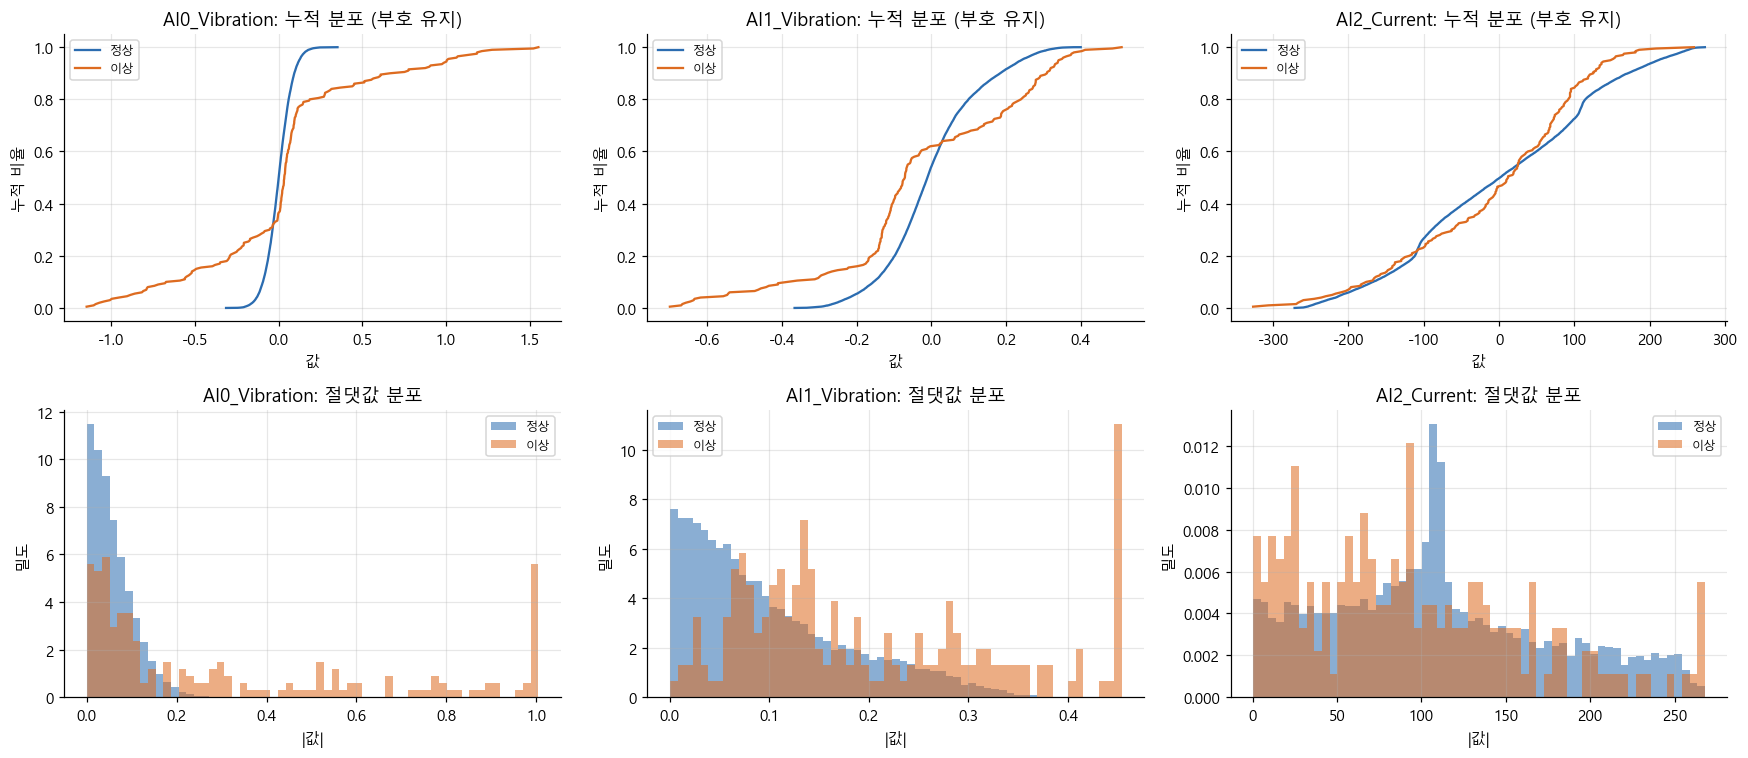

센서,데이터,중앙값(부호 유지),IQR(부호 유지),중앙값(절댓값),IQR(절댓값)
AI0_Vibration,정상,0.000376,0.09541,0.04772,0.06173
AI0_Vibration,이상,0.03365,0.2952,0.1286,0.4962
AI1_Vibration,정상,-0.0109,0.1519,0.07694,0.1112
AI1_Vibration,이상,-0.07097,0.327,0.1495,0.1879
AI2_Current,정상,1.096,210.6,105.3,91.88
AI2_Current,이상,11.92,173.2,84.04,95.96


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
vd_rows = []
for j, s in enumerate(SENSORS):
    for lab in (0, 1):
        x = DEV.loc[DEV.label == lab, s].to_numpy()
        xs = np.sort(x)
        axes[0, j].plot(xs, np.arange(1, len(xs) + 1) / len(xs), color=COL[lab], label=LAB[lab])
        xa = np.abs(x)
        lo, hi = np.quantile(np.abs(DEV[s]), [.001, .999])
        axes[1, j].hist(np.clip(xa, lo, hi), bins=np.linspace(lo, hi, 60), density=True, alpha=.55, color=COL[lab], label=LAB[lab])
        vd_rows.append({'센서': s, '데이터': LAB[lab], '중앙값(부호 유지)': np.median(x), 'IQR(부호 유지)': stats.iqr(x),
                        '중앙값(절댓값)': np.median(xa), 'IQR(절댓값)': stats.iqr(xa)})
    axes[0, j].set(title=f'{s}: 누적 분포 (부호 유지)', xlabel='값', ylabel='누적 비율'); axes[0, j].legend(fontsize=8)
    axes[1, j].set(title=f'{s}: 절댓값 분포', xlabel='|값|', ylabel='밀도'); axes[1, j].legend(fontsize=8)
plt.tight_layout()
show('03_4_value_dist', '센서 값의 누적 분포(위)와 절댓값 분포(아래), Train+Valid')
VALDIST_TAB = pd.DataFrame(vd_rows)
display(VALDIST_TAB.style.format({c: '{:.4g}' for c in VALDIST_TAB.columns if c not in ('센서', '데이터')}).hide(axis='index'))

### 03-5 파형

- **위**: 상태별 전체 파형입니다. 끊긴 곳에서 선이 끊깁니다. 정상은 Train+Valid 약 60분, 이상은 Valid 약 1.5분입니다.
- **아래**: 상태마다 가장 긴 구간 하나를 같은 세로 눈금으로 확대했습니다. 고르는 기준은 길이뿐이고, 성능을 보고 고르지 않았습니다.
- **공백을 무시하는 폴더(v4_2, v4_3)**에서는 마지막 그림으로, 실제 시간축 파형과 **끊김을 무시하고 이어 붙인 파형(윈도 입력이 되는 모양)**을 나란히 그립니다.

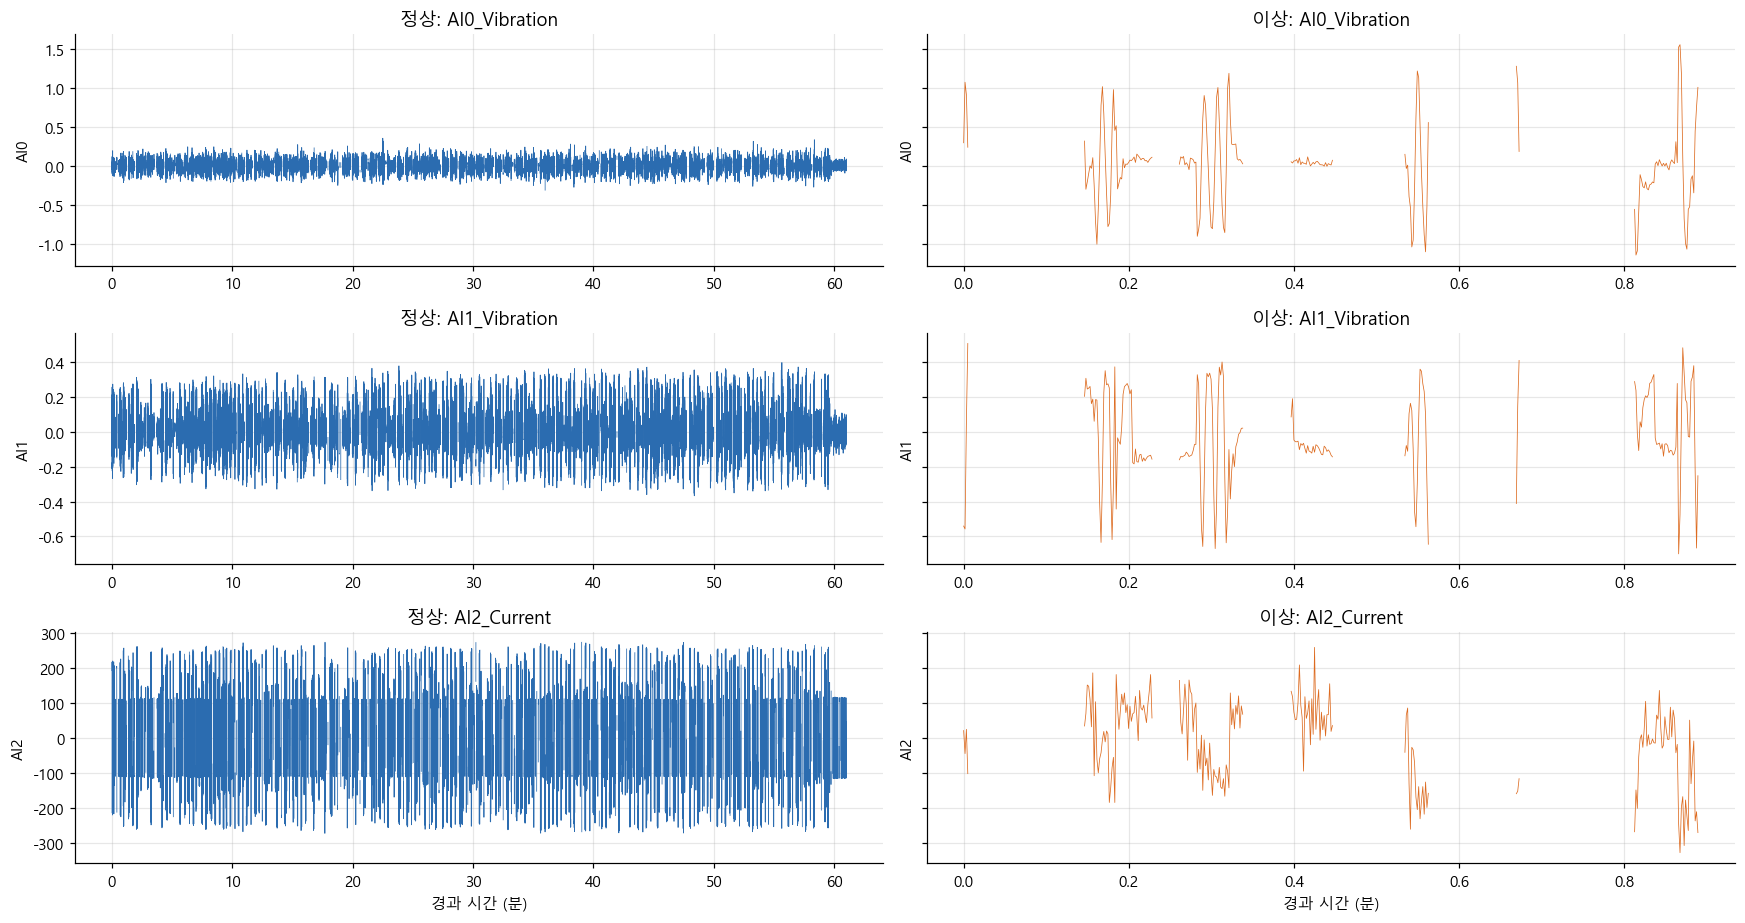

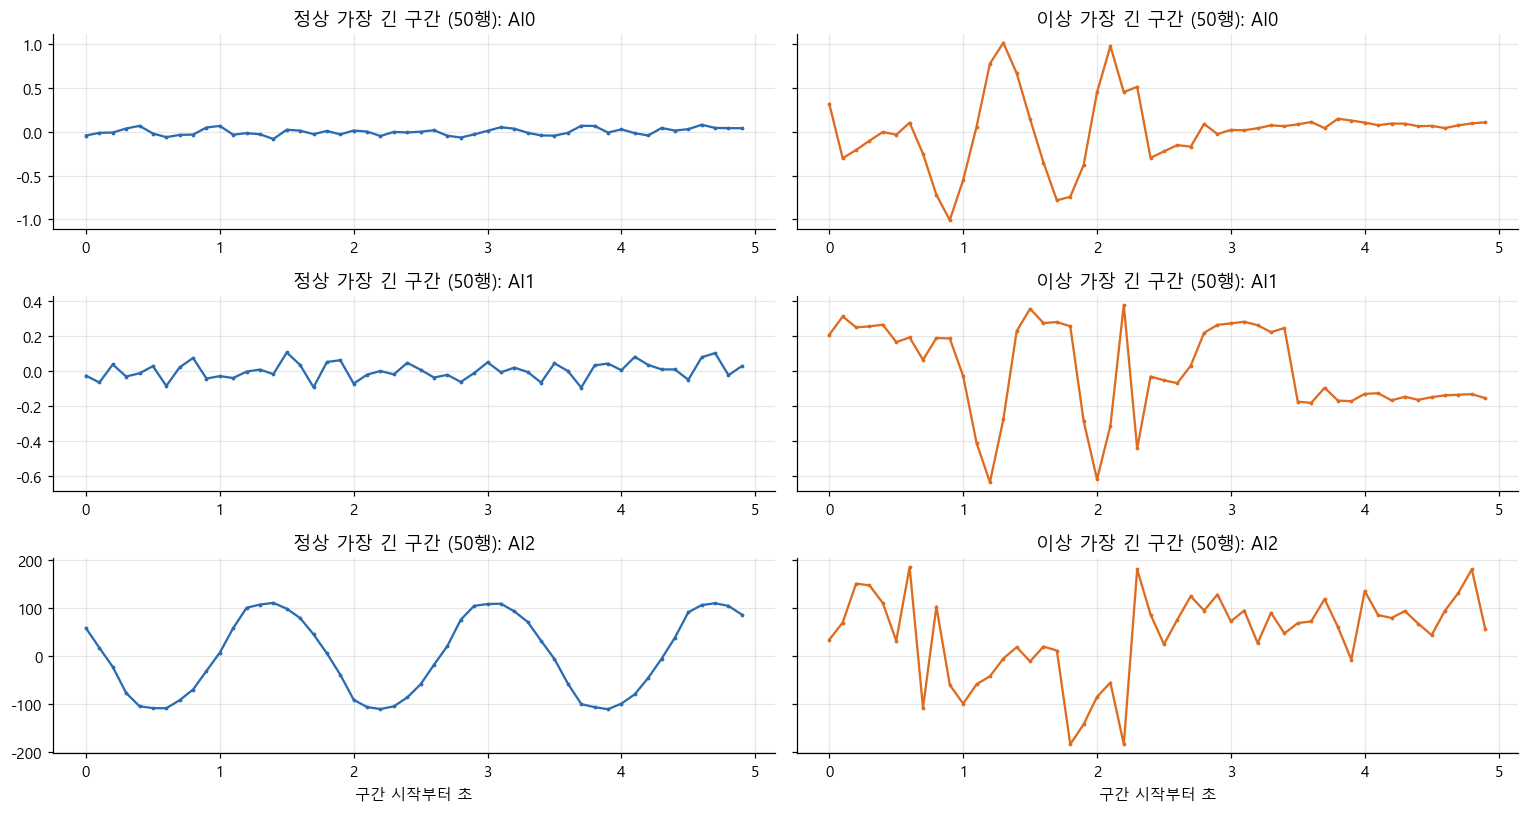

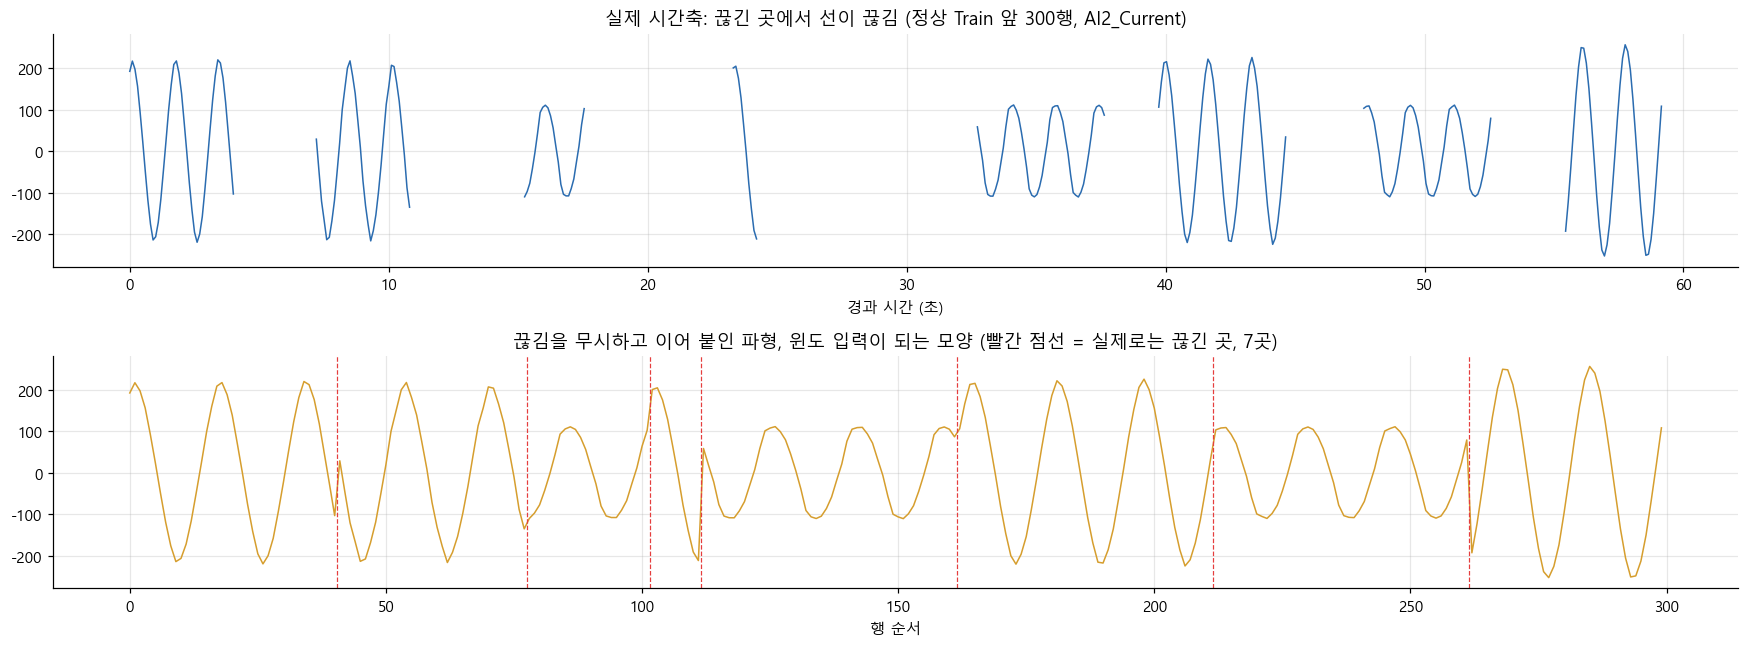

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(16, 8.5), sharey='row')
for k, lab in enumerate((0, 1)):
    d = IV[lab]
    for i, s in enumerate(SENSORS):
        for _, seg in d.groupby('segment', sort=False):
            axes[i, k].plot(seg.t_sec / 60, seg[s], color=COL[lab], lw=.5)
        axes[i, k].set(title=f'{LAB[lab]}: {s}', xlabel='경과 시간 (분)' if i == 2 else '', ylabel=SHORT[s])
plt.tight_layout()
show('03_5_waveform', '상태별 전체 파형 (Train+Valid, 끊긴 곳에서 선이 끊김)')

fig, axes = plt.subplots(3, 2, figsize=(14, 7.5), sharey='row')
for k, lab in enumerate((0, 1)):
    d = IV[lab]
    sid = d.groupby('segment', sort=False).size().idxmax()
    blk = d[d.segment == sid]
    for i, s in enumerate(SENSORS):
        axes[i, k].plot((blk.t_ms - blk.t_ms.iloc[0]) / 1000, blk[s], marker='.', ms=3, color=COL[lab])
        axes[i, k].set(title=f'{LAB[lab]} 가장 긴 구간 ({len(blk)}행): {SHORT[s]}', xlabel='구간 시작부터 초' if i == 2 else '')
plt.tight_layout()
show('03_5_zoom', '가장 긴 구간 확대 (같은 세로 눈금)')

if not RESPECT_GAPS:
    d = IV[0][IV[0].split == 'train'].head(300)
    brk_idx = np.flatnonzero(np.r_[False, d.segment.to_numpy()[1:] != d.segment.to_numpy()[:-1]])
    fig, axes = plt.subplots(2, 1, figsize=(16, 6))
    for _, seg in d.groupby('segment', sort=False):
        axes[0].plot(seg.t_sec, seg['AI2_Current'], color=COL[0], lw=1)
    axes[0].set(title='실제 시간축: 끊긴 곳에서 선이 끊김 (정상 Train 앞 300행, AI2_Current)', xlabel='경과 시간 (초)')
    axes[1].plot(np.arange(len(d)), d['AI2_Current'].to_numpy(), color='#d69e2e', lw=1)
    for b in brk_idx:
        axes[1].axvline(b - .5, color='#e53e3e', ls='--', lw=.8)
    axes[1].set(title=f'끊김을 무시하고 이어 붙인 파형, 윈도 입력이 되는 모양 (빨간 점선 = 실제로는 끊긴 곳, {len(brk_idx)}곳)', xlabel='행 순서')
    plt.tight_layout()
    show('03_6_stitched', '실제 파형과 이어 붙인 파형 비교 (정상 Train 앞 300행)')
else:
    print('이 폴더는 구간 안에서만 윈도를 만들어서, 이어 붙인 파형 비교는 생략합니다.')

## 04 윈도와 파생변수, 이상 근거

윈도(`WINDOW`행씩 한 칸씩 민 묶음)마다 시계열 이상탐지에서 자주 쓰는 특징을 계산합니다. 센서 3개 × 19개 + 센서 간 관계 6개 = **63개**입니다.

| 분류 | 변수 (센서마다) | 뜻 | 이상탐지에서 쓰는 이유 |
|---|---|---|---|
| 크기 | `mean`, `std`, `rms`, `p2p`, `max_abs` | 평균, 흔들림 폭, 평균 세기, 최댓값-최솟값, 가장 큰 절댓값 | 진동·전류가 커지거나 작아지는 이상 |
| 모양 | `crest`, `p2p_std`, `skew`, `kurt` | 최대/RMS, 폭/표준편차, 비대칭, 뾰족함(첨도) | 순간적인 충격, 튀는 값 |
| 시간 변화 | `acf1`, `zcr`, `slope`, `diff_rms` | 0.1초 뒤 자기상관, 평균선 교차 빈도, 기울기, 1차 차분 세기 | 신호가 거칠어지거나 추세가 생김 |
| 주파수 | `centroid`, `entropy`, `peak_hz`, `band_low/mid/high` | 스펙트럼 중심, 퍼짐 정도, 가장 센 주파수, 대역별 에너지 비율 | 진동 성분의 분포 변화 (0-5 Hz만 볼 수 있음) |
| 센서 간 관계 | `corr_A_B`, `ratio_A_B` | 윈도 안 두 센서 상관, RMS 비율 | 센서들이 같이 움직이던 방식이 깨짐 |

**윈도와 라벨**: 윈도는 블록(구간 또는 분할 전체) 안에서 한 칸씩 밀며 만듭니다. 라벨은 `LABEL_OFFSET`이 0이면 윈도 마지막 행, 120이면 윈도 시작에서 120행 뒤 행입니다. 라벨이 파일 단위라 값은 같고, 120이면 각 블록의 마지막 약 100행이 입력에 쓰이지 않습니다.

**판정 단위 구간**: 윈도 입력의 **마지막 행**이 속한 구간을 그 윈도의 구간으로 봅니다. 구간 단위 경보, 신뢰구간, 선택 낙관도는 이 구간을 단위로 셉니다. 윈도가 끊김을 넘으면 앞부분은 앞 구간의 데이터일 수 있습니다.

**이상 근거**: 윈도 수보다 **원본 행과 구간 수**가 근거의 양입니다. 같은 구간 안의 윈도는 거의 같은 데이터이기 때문입니다.

In [10]:
FREQS = np.fft.rfftfreq(WINDOW, PERIOD_S)[1:]
BANDS = {'low': (0.0, 1.5), 'mid': (1.5, 3.0), 'high': (3.0, 5.01)}
L_SPAN = max(WINDOW - 1, LABEL_OFFSET)   # 윈도 시작에서 라벨 행까지의 거리


def make_windows(df, W):
    Xs, metas, used = [], [], []
    for _, g in df.groupby('block', sort=False):
        count = len(g) - L_SPAN
        if count <= 0:
            continue
        idx = np.arange(count)[:, None] + np.arange(W)
        seg = g['segment'].to_numpy()
        ordv = g['ord'].to_numpy()
        Xs.append(g[SENSORS].to_numpy()[idx])
        metas.append(pd.DataFrame({'label': g['label'].iloc[0], 'split': g['split'].iloc[0], 'block': g['block'].iloc[0],
                                   'start_segment': seg[idx[:, 0]], 'segment': seg[idx[:, -1]],
                                   'start_pos': g['pos'].to_numpy()[idx[:, 0]], 'start_ord': ordv[idx[:, 0]],
                                   'end_ord': ordv[idx[:, -1]], 'end_time': g['TimeStamp'].to_numpy()[idx[:, -1]]}))
        used.append(g.iloc[:count + W - 1][['label', 'split', 'segment', 'ord']])
    meta = pd.concat(metas, ignore_index=True)
    meta['crosses_gap'] = meta['start_segment'] != meta['segment']
    return np.concatenate(Xs), meta, pd.concat(used, ignore_index=True)


def window_features(X):
    eps = 1e-12
    W = X.shape[1]
    mean = X.mean(1)
    c = X - mean[:, None, :]
    std = c.std(1)
    rms = np.sqrt((X ** 2).mean(1))
    p2p = X.max(1) - X.min(1)
    max_abs = np.abs(X).max(1)
    d = np.diff(X, axis=1)
    t = np.arange(W) - (W - 1) / 2
    spec = np.abs(np.fft.rfft(c * np.hanning(W)[None, :, None], axis=1))[:, 1:, :] ** 2
    tot = spec.sum(1) + eps
    p = spec / tot[:, None, :]
    F = {}
    for j, s in enumerate(SENSORS):
        n, sd = SHORT[s], std[:, j] + eps
        F[f'{n}_mean'] = mean[:, j]
        F[f'{n}_std'] = std[:, j]
        F[f'{n}_rms'] = rms[:, j]
        F[f'{n}_p2p'] = p2p[:, j]
        F[f'{n}_max_abs'] = max_abs[:, j]
        F[f'{n}_crest'] = max_abs[:, j] / (rms[:, j] + eps)
        F[f'{n}_p2p_std'] = p2p[:, j] / sd
        F[f'{n}_skew'] = (c[:, :, j] ** 3).mean(1) / sd ** 3
        F[f'{n}_kurt'] = (c[:, :, j] ** 4).mean(1) / sd ** 4 - 3
        F[f'{n}_acf1'] = (c[:, 1:, j] * c[:, :-1, j]).mean(1) / sd ** 2
        F[f'{n}_zcr'] = (np.diff(np.sign(c[:, :, j]), axis=1) != 0).mean(1)
        F[f'{n}_slope'] = (c[:, :, j] * t).sum(1) / (t ** 2).sum() / PERIOD_S
        F[f'{n}_diff_rms'] = np.sqrt((d[:, :, j] ** 2).mean(1))
        F[f'{n}_centroid'] = (p[:, :, j] * FREQS).sum(1)
        F[f'{n}_entropy'] = -(p[:, :, j] * np.log(p[:, :, j] + eps)).sum(1) / np.log(len(FREQS))
        F[f'{n}_peak_hz'] = FREQS[spec[:, :, j].argmax(1)]
        for b, (lo, hi) in BANDS.items():
            m = (FREQS > lo) & (FREQS <= hi)
            F[f'{n}_band_{b}'] = spec[:, m, j].sum(1) / tot[:, j]
    for a, b in [(0, 1), (0, 2), (1, 2)]:
        na, nb = SHORT[SENSORS[a]], SHORT[SENSORS[b]]
        F[f'corr_{na}_{nb}'] = (c[:, :, a] * c[:, :, b]).mean(1) / ((std[:, a] + eps) * (std[:, b] + eps))
        F[f'ratio_{na}_{nb}'] = rms[:, a] / (rms[:, b] + eps)
    return pd.DataFrame(F)


def category(f):
    if f.startswith(('corr_', 'ratio_')):
        return '센서 간 관계'
    k = f.split('_', 1)[1]
    if k in ('mean', 'std', 'rms', 'p2p', 'max_abs'):
        return '크기'
    if k in ('crest', 'p2p_std', 'skew', 'kurt'):
        return '모양'
    if k in ('acf1', 'zcr', 'slope', 'diff_rms'):
        return '시간 변화'
    return '주파수'


X, WMETA, USED = make_windows(rows, WINDOW)
FEAT = window_features(X).replace([np.inf, -np.inf], np.nan)
TR = ((WMETA.split == 'train') & (WMETA.label == 0)).to_numpy()   # 정상 Train
VA = (WMETA.split == 'valid').to_numpy()                           # Valid (정상+이상)
VN = (VA & (WMETA.label == 0)).to_numpy()                          # 정상 Valid

WIN_TAB = (WMETA.groupby(['label', 'split']).size().unstack().reindex(columns=['train', 'valid'])
           .rename(index=LAB).fillna(0).astype(int))
WIN_TAB.index.name = '데이터'
check('윈도는 분할 경계를 넘지 않음', bool(WMETA.groupby('block').split.nunique().eq(1).all()) and set(WMETA.split) <= {'train', 'valid'},
      '윈도를 블록(구간 또는 분할) 안에서만 자름')

# ---- 경계 앞뒤의 입력이 같은 연속 기록인지 (구조 정보만 사용) ----
SEG_OF = {(r.label, r.ord): r.segment for r in MANIFEST.dropna(subset=['ord']).itertuples()}
adj = []
for lab in (0, 1):
    m_lab = MANIFEST[(MANIFEST.label == lab) & MANIFEST.split.isin(['train', 'valid', 'test'])]
    for a, b in [('train', 'valid'), ('valid', 'test')]:
        wa = WMETA[(WMETA.label == lab) & (WMETA.split == a)]
        rb = m_lab[m_lab.split == b]
        if len(wa) == 0 or len(rb) == 0:
            continue
        last_in, first_b = int(wa.end_ord.max()), int(rb.ord.min())
        adj.append({'데이터': LAB[lab], '경계': f'{a} → {b}', '앞 분할의 마지막 입력 행': last_in, '뒤 분할의 첫 행': first_b,
                    '사이 행 수': first_b - last_in - 1, '같은 연속 기록': SEG_OF[(lab, last_in)] == SEG_OF[(lab, first_b)]})
ADJ_TAB = pd.DataFrame(adj)
N_ADJ = int(ADJ_TAB['같은 연속 기록'].sum()) if len(ADJ_TAB) else 0
check('경계 앞뒤 입력이 서로 다른 연속 기록', N_ADJ == 0,
      ('경계 앞뒤 입력이 모두 다른 구간에 속함' if N_ADJ == 0 else
       f'행은 겹치지 않지만, 경계 {N_ADJ}곳에서 앞 분할의 마지막 입력과 뒤 분할의 첫 행이 같은 연속 기록에 속함. 몇십 행 수준이라 영향은 작음')
      + (f'. 120행 뒤 라벨 때문에 경계 앞에 약 {int(ADJ_TAB["사이 행 수"].min())}행의 여유가 생김' if LABEL_OFFSET > 0 and len(ADJ_TAB) else ''),
      info=True)

# ---- 이상 근거: 원본 행과 구간 수 ----
ev_rows = []
for lab in (0, 1):
    for sp in ['train', 'valid']:
        base = rows[(rows.label == lab) & (rows.split == sp)]
        if len(base) == 0:
            continue
        u = USED[(USED.label == lab) & (USED.split == sp)]
        w = WMETA[(WMETA.label == lab) & (WMETA.split == sp)]
        ev_rows.append({'데이터': LAB[lab], 'split': sp, '원본 행': len(base), '입력에 쓰인 행': len(u),
                        '입력에 안 쓰인 행 비율': f'{1 - len(u) / len(base):.1%}', '구간 수': base.segment.nunique(),
                        '윈도가 닿는 구간': u.segment.nunique(), '판정 단위 구간': w.segment.nunique(), '윈도 수': len(w),
                        '끊김을 넘는 윈도 비율': f'{w.crosses_gap.mean():.0%}' if len(w) else '-'})
EVID_TAB = pd.DataFrame(ev_rows)
N_ANOM_SEG = int(WMETA[VA & (WMETA.label == 1).to_numpy()].segment.nunique())
print(f'윈도 {len(FEAT):,}개 × 파생변수 {FEAT.shape[1]}개 | 블록: {BLOCK_NAME} | 라벨 위치: {"마지막 행" if LABEL_OFFSET == 0 else f"{LABEL_OFFSET}행 뒤"}')
display(WIN_TAB)
display(EVID_TAB.style.hide(axis='index').set_caption('근거의 양: 윈도 수가 아니라 원본 행과 구간 수로 보세요'))
display(ADJ_TAB.style.hide(axis='index').set_caption('분할 경계 앞뒤의 입력 (같은 연속 기록이면 거의 같은 신호가 양쪽에 들어감)'))

윈도 15,839개 × 파생변수 63개 | 블록: 분할 전체(끊김 무시) | 라벨 위치: 120행 뒤


split,train,valid
데이터,,
정상,13879,1880
이상,0,80


데이터,split,원본 행,입력에 쓰인 행,입력에 안 쓰인 행 비율,구간 수,윈도가 닿는 구간,판정 단위 구간,윈도 수,끊김을 넘는 윈도 비율
정상,train,13999,13898,0.7%,423,419,419,13879,50%
정상,valid,2000,1899,5.0%,59,57,57,1880,51%
이상,valid,200,99,50.5%,7,3,2,80,29%


데이터,경계,앞 분할의 마지막 입력 행,뒤 분할의 첫 행,사이 행 수,같은 연속 기록
정상,train → valid,13897,13999,101,False
정상,valid → test,15897,15999,101,False
이상,valid → test,98,200,101,False


### 04-2 윈도 길이별 윈도 수와 행 활용률

이 폴더의 윈도 규칙(블록, 라벨 위치)을 그대로 두고 윈도 길이만 16, 20, 30, 50행으로 바꿔 봅니다. 분석에는 20행을 씁니다.
- **행 활용률**: 원본 행 중 윈도 입력에 한 번이라도 쓰인 비율입니다. 구간 안에서만 윈도를 만들면, 윈도가 길수록 짧은 구간을 못 써서 활용률이 떨어집니다.
- **끊김을 넘는 비율**: 공백을 무시하는 폴더에서, 윈도가 길수록 끊김을 넘는 윈도가 많아집니다.

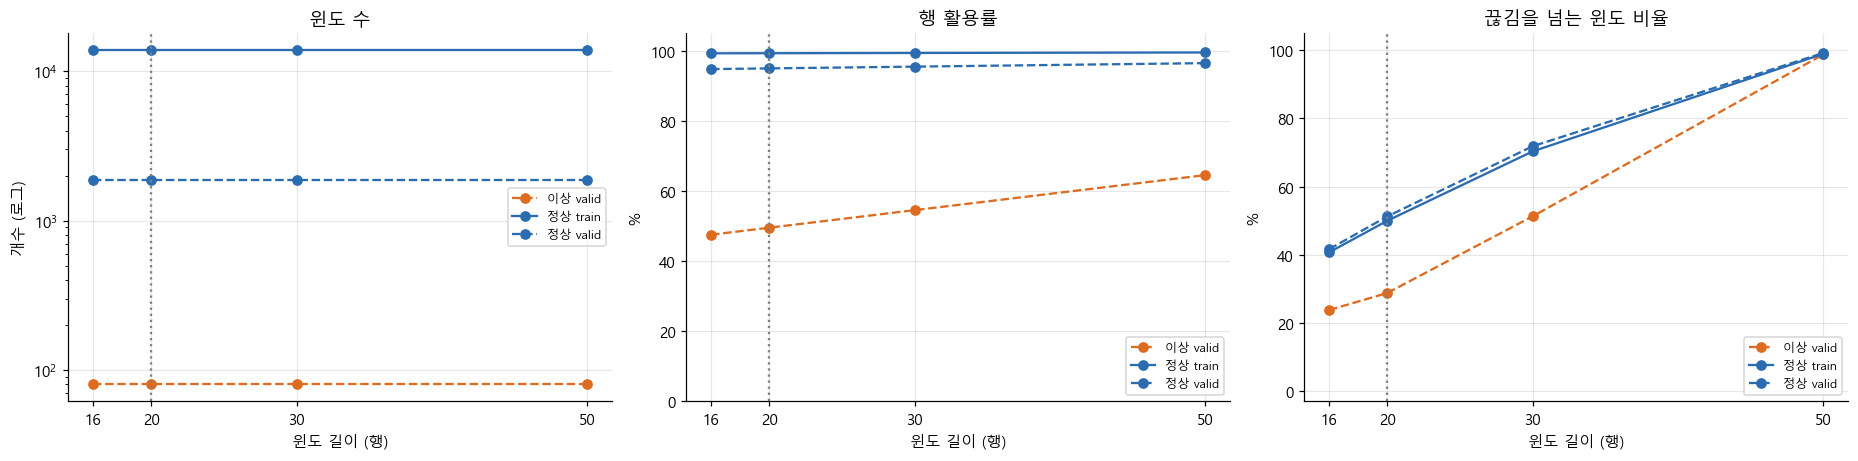

In [11]:
wl_rows = []
for W_ in (16, 20, 30, 50):
    span = max(W_ - 1, LABEL_OFFSET)
    for (lab, sp), part in rows.groupby(['label', 'split']):
        n_win, used, cross = 0, 0, 0
        for _, g in part.groupby('block', sort=False):
            cnt = len(g) - span
            if cnt <= 0:
                continue
            n_win += cnt
            used += cnt + W_ - 1
            seg = g.segment.to_numpy()
            cross += int((seg[:cnt] != seg[W_ - 1:W_ - 1 + cnt]).sum())
        wl_rows.append({'윈도 길이': W_, '데이터': LAB[lab], 'split': sp, '윈도 수': n_win,
                        '행 활용률': used / len(part), '끊김을 넘는 비율': cross / n_win if n_win else np.nan})
WINLEN_TAB = pd.DataFrame(wl_rows)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for (lab, sp), g in WINLEN_TAB.groupby(['데이터', 'split']):
    style = dict(marker='o', label=f'{lab} {sp}', color=COL[0 if lab == '정상' else 1], ls='-' if sp == 'train' else '--')
    axes[0].plot(g['윈도 길이'], g['윈도 수'], **style)
    axes[1].plot(g['윈도 길이'], g['행 활용률'] * 100, **style)
    axes[2].plot(g['윈도 길이'], g['끊김을 넘는 비율'] * 100, **style)
for ax, t, yl in [(axes[0], '윈도 수', '개수 (로그)'), (axes[1], '행 활용률', '%'), (axes[2], '끊김을 넘는 윈도 비율', '%')]:
    ax.axvline(WINDOW, color='gray', ls=':')
    ax.set(title=t, xlabel='윈도 길이 (행)', ylabel=yl, xticks=[16, 20, 30, 50])
    ax.legend(fontsize=8)
axes[0].set_yscale('log')
axes[1].set_ylim(0, 105); axes[2].set_ylim(-3, 105)
plt.tight_layout()
show('04_2_window_length', f'윈도 길이별 윈도 수, 행 활용률, 끊김을 넘는 비율 ({VARIANT} 규칙, 점선 = 분석에 쓰는 {WINDOW}행)')
WINLEN_N = WINLEN_TAB.pivot_table(index=['데이터', 'split'], columns='윈도 길이', values='윈도 수')
WINLEN_COV = WINLEN_TAB.pivot_table(index=['데이터', 'split'], columns='윈도 길이', values='행 활용률')
display(WINLEN_N.style.format('{:,.0f}').set_caption('윈도 길이별 윈도 수'))
display(WINLEN_COV.style.format('{:.0%}').set_caption('윈도 길이별 행 활용률'))

### 04-3 스펙트럼 (FFT/PSD)

20행 윈도마다 평균을 빼고 Hann 창을 씌워 FFT 파워(PSD)를 구합니다. 선은 윈도별 중앙값, 띠는 25~75% 범위입니다.
10 Hz 샘플링이라 볼 수 있는 주파수는 0.5~5 Hz이고, 주파수 칸 간격은 0.5 Hz입니다. 부품 고장 주파수 진단이 아니라, 0~5 Hz 안에서 에너지가 어디에 몰리는지를 봅니다.
공백을 무시하는 폴더에서는 정상 윈도를 **끊김을 넘는 것과 안 넘는 것**으로 나눠 그립니다.

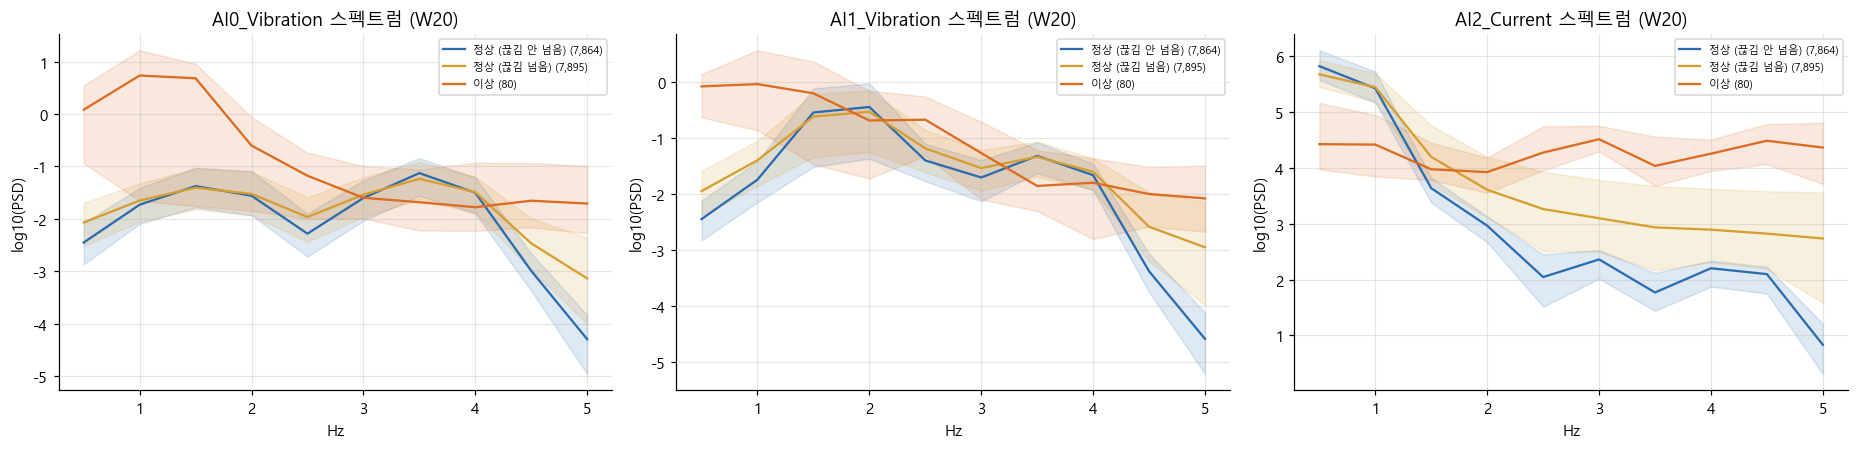

그룹,이상,정상 (끊김 넘음),정상 (끊김 안 넘음)
센서,,,
AI0_Vibration,1.0,3.5,3.5
AI1_Vibration,1.0,2.0,2.0
AI2_Current,3.0,0.5,0.5


In [12]:
cX = X - X.mean(1, keepdims=True)
PSD = np.abs(np.fft.rfft(cX * np.hanning(WINDOW)[None, :, None], axis=1))[:, 1:, :] ** 2
groups = [('정상', (WMETA.label == 0).to_numpy() & ~WMETA.crosses_gap.to_numpy(), COL[0])]
if not RESPECT_GAPS:
    groups[0] = ('정상 (끊김 안 넘음)', groups[0][1], COL[0])
    groups.append(('정상 (끊김 넘음)', (WMETA.label == 0).to_numpy() & WMETA.crosses_gap.to_numpy(), '#d69e2e'))
groups.append(('이상', (WMETA.label == 1).to_numpy(), COL[1]))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
spec_rows = []
for j, s in enumerate(SENSORS):
    for name, m, c in groups:
        q = np.quantile(np.log10(PSD[m, :, j] + 1e-20), [.25, .5, .75], axis=0)
        axes[j].plot(FREQS, q[1], color=c, label=f'{name} ({int(m.sum()):,})')
        axes[j].fill_between(FREQS, q[0], q[2], color=c, alpha=.15)
        spec_rows.append({'센서': s, '그룹': name, '가장 센 주파수(Hz, 중앙값 기준)': float(FREQS[np.argmax(q[1])])})
    axes[j].set(title=f'{s} 스펙트럼 (W{WINDOW})', xlabel='Hz', ylabel='log10(PSD)')
    axes[j].legend(fontsize=7)
plt.tight_layout()
show('04_3_spectrum', f'센서별 스펙트럼: 윈도별 중앙값과 25~75% 범위 (Train+Valid, W{WINDOW})')
SPEC_TAB = pd.DataFrame(spec_rows).pivot(index='센서', columns='그룹', values='가장 센 주파수(Hz, 중앙값 기준)')
display(SPEC_TAB.style.format('{:.1f}').set_caption('가장 센 주파수 (Hz)'))

## 05 파생변수별 정상·이상 구분력 (Valid)

변수 하나만으로 Valid의 정상과 이상을 얼마나 가를 수 있는지 잽니다.

| 지표 | 뜻 |
|---|---|
| **AUC** | 0.5면 못 가르고 1이면 완벽하게 가릅니다. 이상에서 값이 작아지는 변수도 같은 기준으로 보이게 뒤집었습니다 |
| **방향** | 이상에서 값이 커지는지 작아지는지 |
| **KS** | 두 분포가 가장 크게 벌어진 정도 (0~1) |
| **라벨 상관** | 변수와 라벨(정상 0, 이상 1)의 피어슨 상관(점이연 상관). +면 이상에서 큼 |
| **효과 크기** | (이상 중앙값 − 정상 중앙값) ÷ 정상 IQR |
| **95% 구간** | 판정 단위 구간을 다시 뽑아 AUC를 반복 계산한 범위 (상위 10개). 이상 구간이 5개 미만이면 조합이 몇 개 안 나와서 **참고용**입니다 |

변수,분류,AUC,95% 구간,방향,KS,라벨 상관,효과 크기
AI2_band_high,주파수,1.000,1.00 ~ 1.00,이상에서 큼,1.00,+0.89,+83.0
AI2_band_low,주파수,0.999,1.00 ~ 1.00,이상에서 작음,0.99,-0.84,-48.9
AI2_acf1,시간 변화,0.999,1.00 ~ 1.00,이상에서 작음,0.97,-0.83,-10.0
AI2_centroid,주파수,0.999,1.00 ~ 1.00,이상에서 큼,0.98,+0.82,+27.9
ratio_AI1_AI2,센서 간 관계,0.999,1.00 ~ 1.00,이상에서 큼,0.96,+0.77,+4.6
AI2_entropy,주파수,0.990,0.98 ~ 1.00,이상에서 큼,0.94,+0.59,+7.6
corr_AI0_AI1,센서 간 관계,0.989,0.98 ~ 0.99,이상에서 작음,0.92,-0.46,-1.5
ratio_AI0_AI2,센서 간 관계,0.985,0.97 ~ 1.00,이상에서 큼,0.87,+0.83,+23.9
AI1_peak_hz,주파수,0.976,0.97 ~ 0.98,이상에서 작음,0.84,-0.37,-2.0
AI2_band_mid,주파수,0.975,0.96 ~ 0.99,이상에서 큼,0.88,+0.67,+26.9


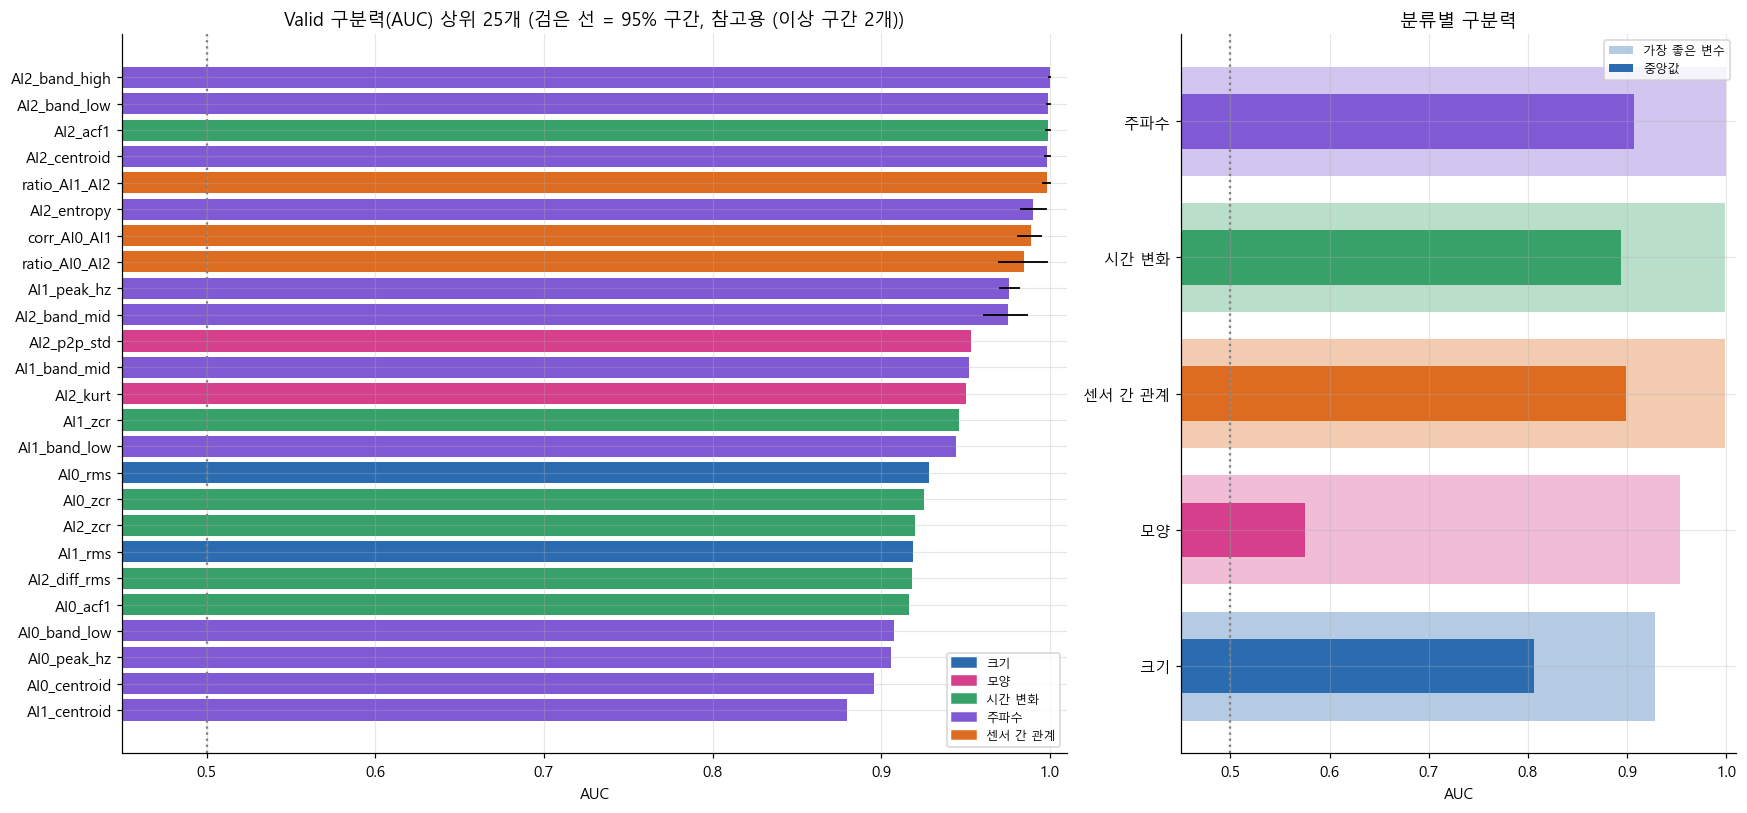

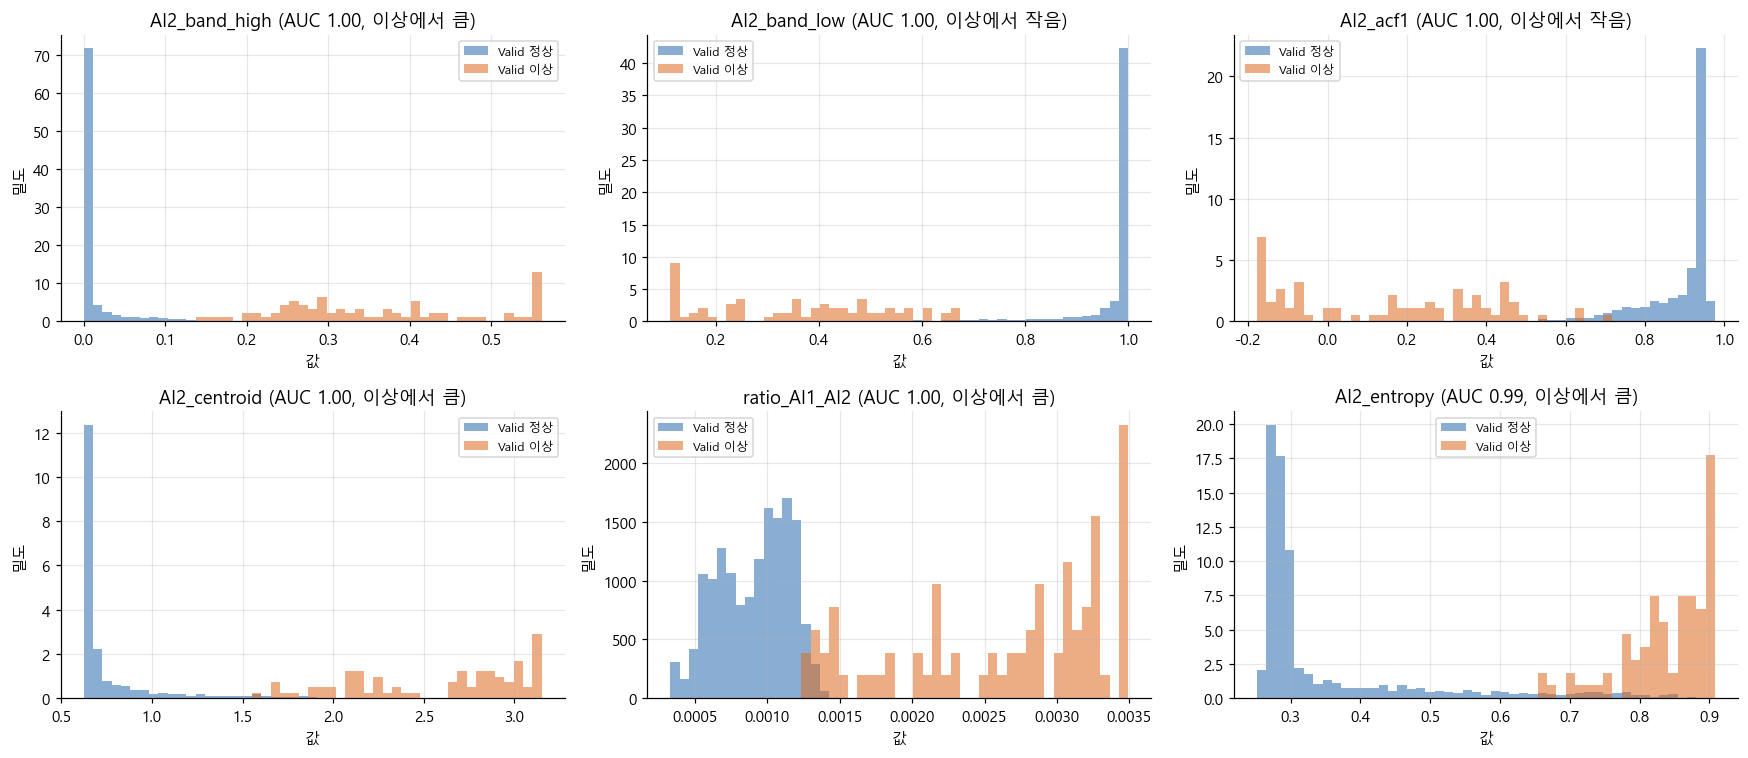

In [13]:
yv = WMETA.label.to_numpy()[VA]
rank_rows = []
for f in FEAT.columns:
    v = FEAT[f].to_numpy()[VA]
    m = np.isfinite(v)
    a = roc_auc_score(yv[m], v[m])
    n_, a_ = v[m & (yv == 0)], v[m & (yv == 1)]
    iqr = stats.iqr(n_) or np.nan
    rank_rows.append({'feature': f, 'sensor': 'AI0/1/2' if f.startswith(('corr_', 'ratio_')) else f.split('_')[0],
                      'category': category(f), 'AUC': max(a, 1 - a), 'direction': '이상에서 큼' if a >= .5 else '이상에서 작음',
                      'KS': stats.ks_2samp(n_, a_).statistic, 'label_corr': stats.pearsonr(v[m], yv[m])[0],
                      'effect': (np.median(a_) - np.median(n_)) / iqr})
RANK = pd.DataFrame(rank_rows)
RANK['abs_effect'] = RANK['effect'].abs()
RANK = RANK.sort_values(['AUC', 'abs_effect'], ascending=False, na_position='last').reset_index(drop=True)

va_meta = WMETA[VA].reset_index(drop=True)
seg_idx = {lab: [np.flatnonzero((va_meta.segment == s).to_numpy()) for s in va_meta.loc[va_meta.label == lab, 'segment'].unique()]
           for lab in (0, 1)}
CI_NOTE = f'참고용 (이상 구간 {N_ANOM_SEG}개)' if N_ANOM_SEG < 5 else ''
boot_sets = [np.concatenate([seg_idx[lab][i] for lab in (0, 1) for i in rng.integers(0, len(seg_idx[lab]), len(seg_idx[lab]))])
             for _ in range(N_BOOT)]
RANK['CI_low'], RANK['CI_high'] = np.nan, np.nan
for i, r in RANK.head(10).iterrows():
    v = FEAT[r.feature].to_numpy()[VA] * (1 if r.direction == '이상에서 큼' else -1)
    aucs = []
    for idx in boot_sets:
        y, x = yv[idx], v[idx]
        m = np.isfinite(x)
        if len(np.unique(y[m])) == 2:
            aucs.append(roc_auc_score(y[m], x[m]))
    RANK.loc[i, ['CI_low', 'CI_high']] = np.percentile(aucs, [2.5, 97.5])
save_table(RANK, 'feature_ranking', index=False)

RANK_SHOW = RANK.head(20).rename(columns={'feature': '변수', 'category': '분류', 'direction': '방향', 'label_corr': '라벨 상관',
                                          'effect': '효과 크기'})
RANK_SHOW['95% 구간'] = [f'{a:.2f} ~ {b:.2f}' if np.isfinite(a) else '' for a, b in zip(RANK.head(20).CI_low, RANK.head(20).CI_high)]
display(RANK_SHOW[['변수', '분류', 'AUC', '95% 구간', '방향', 'KS', '라벨 상관', '효과 크기']]
        .style.format({'AUC': '{:.3f}', 'KS': '{:.2f}', '라벨 상관': '{:+.2f}', '효과 크기': '{:+.1f}'})
        .background_gradient(subset=['AUC'], cmap='Greens', vmin=.5, vmax=1).hide(axis='index')
        .set_caption('Valid 구분력 상위 20개' + (f' (95% 구간은 {CI_NOTE})' if CI_NOTE else '')))

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={'width_ratios': [1.7, 1]})
top = RANK.head(25).iloc[::-1].reset_index(drop=True)
axes[0].barh(top.feature, top.AUC, color=[CAT_COL[c] for c in top.category])
for i, r in top.iterrows():
    if np.isfinite(r.CI_low):
        axes[0].plot([r.CI_low, r.CI_high], [i, i], color='black', lw=1.2)
axes[0].axvline(.5, color='gray', ls=':')
axes[0].set(xlim=(.45, 1.01), title='Valid 구분력(AUC) 상위 25개 (검은 선 = 95% 구간' + (f', {CI_NOTE})' if CI_NOTE else ')'), xlabel='AUC')
axes[0].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in CAT_COL.values()], labels=list(CAT_COL), fontsize=8, loc='lower right')
CAT_TAB = RANK.groupby('category').AUC.agg(['max', 'median', 'size']).sort_values('max')
axes[1].barh(CAT_TAB.index, CAT_TAB['max'], color=[CAT_COL[c] for c in CAT_TAB.index], alpha=.35, label='가장 좋은 변수')
axes[1].barh(CAT_TAB.index, CAT_TAB['median'], color=[CAT_COL[c] for c in CAT_TAB.index], height=.4, label='중앙값')
axes[1].axvline(.5, color='gray', ls=':')
axes[1].set(xlim=(.45, 1.01), title='분류별 구분력', xlabel='AUC')
axes[1].legend(fontsize=8)
plt.tight_layout()
show('05_1_auc_rank', '파생변수 구분력(AUC) 순위와 분류별 비교')

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for ax, f in zip(axes.ravel(), RANK.feature.head(6)):
    v = FEAT.loc[VA, f]
    lo, hi = v.quantile([.005, .995])
    bins = np.linspace(lo, hi, 50)
    for lab in (0, 1):
        ax.hist(v[yv == lab].clip(lo, hi), bins=bins, density=True, alpha=.55, color=COL[lab], label=f'Valid {LAB[lab]}')
    r = RANK.set_index('feature').loc[f]
    ax.set(title=f'{f} (AUC {r.AUC:.2f}, {r.direction})', xlabel='값', ylabel='밀도')
    ax.legend(fontsize=8)
plt.tight_layout()
show('05_2_top_features', '구분력 상위 6개 변수의 분포 (Valid)')

### 05-3 선택 낙관도 확인 (변수 기준)

변수를 Valid로 골랐기 때문에, 고른 변수의 Valid 점수는 실제보다 좋게 나옵니다(선택 낙관).
Valid의 판정 단위 구간을 **시간 순서로 앞/뒤 절반**으로 나눠, 한쪽에서 상위 변수를 고르고 다른 쪽에서 같은 방향으로 다시 잽니다.
윈도가 끊김을 넘는 폴더에서는 **두 절반에 걸치는 윈도를 뺍니다.** 그런 윈도는 양쪽 정보를 함께 담기 때문입니다.

In [14]:
def valid_halves(meta):
    # Valid 판정 단위 구간을 시간 순서로 반씩 나눕니다. 두 절반에 걸치는 윈도는 어느 쪽에도 넣지 않습니다.
    m_a = np.zeros(len(meta), bool)
    m_b = np.zeros(len(meta), bool)
    for lab in (0, 1):
        sel = (meta.label == lab).to_numpy()
        order_ = sorted(meta.loc[sel, 'segment'].unique(), key=SEG_POS.get)
        if len(order_) < 2:
            return None
        cut = SEG_POS[order_[len(order_) // 2]]
        s_pos = meta.start_segment.map(SEG_POS).to_numpy()
        e_pos = meta.segment.map(SEG_POS).to_numpy()
        m_a |= sel & (e_pos < cut)
        m_b |= sel & (s_pos >= cut)
    return m_a, m_b


HALVES = valid_halves(va_meta)
OPT_TAB = None
if HALVES is None:
    print('Valid 이상 판정 단위 구간이 2개 미만이라 선택 낙관도를 잴 수 없습니다.')
else:
    m_a, m_b = HALVES

    def dir_auc(f, m, sign=None):
        v, y = FEAT[f].to_numpy()[VA][m], yv[m]
        ok = np.isfinite(v)
        a = roc_auc_score(y[ok], v[ok])
        if sign is None:
            return (a, 1) if a >= .5 else (1 - a, -1)
        return (a if sign == 1 else 1 - a), sign

    opt_rows = []
    for name, sel, oth in [('앞 절반에서 고르고 뒤 절반에서 확인', m_a, m_b), ('뒤 절반에서 고르고 앞 절반에서 확인', m_b, m_a)]:
        res = {f: dir_auc(f, sel) for f in FEAT.columns}
        top_f = sorted(res, key=lambda f: -res[f][0])[:TOP_K]
        a_sel = np.mean([res[f][0] for f in top_f])
        a_oth = np.mean([dir_auc(f, oth, res[f][1])[0] for f in top_f])
        opt_rows.append({'방식': name, f'고른 쪽 상위 {TOP_K}개 평균 AUC': a_sel, '다른 쪽 평균 AUC': a_oth, '차이': a_oth - a_sel})
    OPT_TAB = pd.DataFrame(opt_rows)
    print(f'절반에 걸쳐서 뺀 윈도: {int((~(m_a | m_b)).sum())}개')
    display(OPT_TAB.style.format({c: '{:+.3f}' if c == '차이' else '{:.3f}' for c in OPT_TAB.columns if c != '방식'})
            .hide(axis='index').set_caption('선택 낙관도(변수 기준): 차이가 0에 가까울수록 변수 선택이 안정적'))

절반에 걸쳐서 뺀 윈도: 38개


방식,고른 쪽 상위 10개 평균 AUC,다른 쪽 평균 AUC,차이
앞 절반에서 고르고 뒤 절반에서 확인,0.994,0.981,-0.013
뒤 절반에서 고르고 앞 절반에서 확인,1.000,0.911,-0.089


### 05-4 RMS–P2P 관계

RMS는 평균 세기, P2P는 최댓값과 최솟값의 차이입니다. 파형 모양이 일정하면 둘이 비례해서 정상 점들이 한 줄의 띠를 이룹니다.
정상 Train으로 이 직선을 맞추고, **직선(띠)에서 벗어난 정도**만으로 Valid의 정상과 이상을 얼마나 가르는지 잽니다. 띠에서 벗어나면 세기가 아니라 **파형 모양**이 바뀐 것입니다.

이 "띠 이탈" 값은 정상 Train으로 직선을 맞춰 만든 변수라서, 변수 선택이 바뀌지 않도록 05 단계의 구분력 순위와 09 단계의 후보에는 넣지 않습니다. 참고 분석입니다.

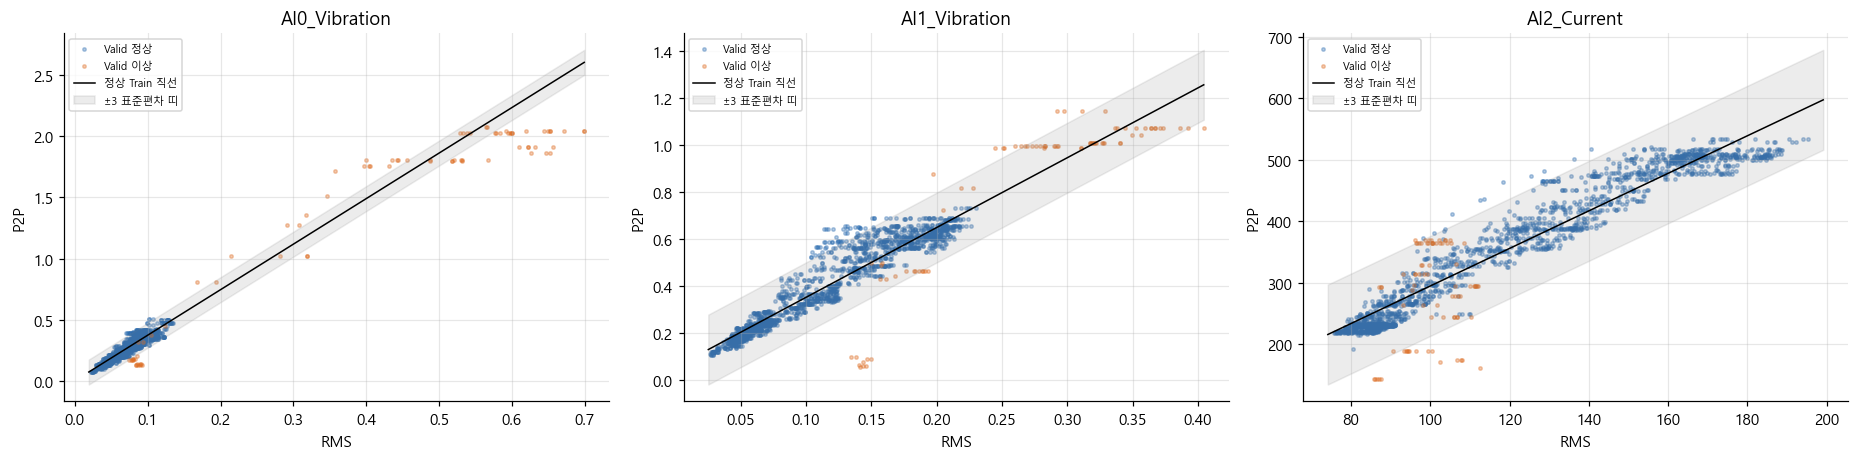

,RMS만,P2P만,띠에서 벗어난 정도
센서,,,
AI0_Vibration,0.928,0.821,0.917
AI1_Vibration,0.919,0.813,0.761
AI2_Current,0.597,0.660,0.900


In [15]:
fw_tr, fw_va = FEAT[TR], FEAT[VA]
band_rows = []
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
for ax, s in zip(axes, SENSORS):
    n = SHORT[s]
    coef = np.polyfit(fw_tr[f'{n}_rms'], fw_tr[f'{n}_p2p'], 1)
    sd = (fw_tr[f'{n}_p2p'] - np.polyval(coef, fw_tr[f'{n}_rms'])).std()
    resid = (fw_va[f'{n}_p2p'] - np.polyval(coef, fw_va[f'{n}_rms'])).abs() / sd

    def sep_auc(v):
        a = roc_auc_score(yv, v)
        return max(a, 1 - a)

    band_rows.append({'센서': s, 'RMS만': sep_auc(fw_va[f'{n}_rms']), 'P2P만': sep_auc(fw_va[f'{n}_p2p']), '띠에서 벗어난 정도': sep_auc(resid)})
    for lab in (0, 1):
        g = fw_va[yv == lab]
        ax.scatter(g[f'{n}_rms'], g[f'{n}_p2p'], s=5, alpha=.35, color=COL[lab], label=f'Valid {LAB[lab]}')
    xs = np.linspace(pd.concat([fw_tr, fw_va])[f'{n}_rms'].min(), pd.concat([fw_tr, fw_va])[f'{n}_rms'].max(), 50)
    ax.plot(xs, np.polyval(coef, xs), color='black', lw=1, label='정상 Train 직선')
    ax.fill_between(xs, np.polyval(coef, xs) - 3 * sd, np.polyval(coef, xs) + 3 * sd, color='gray', alpha=.15, label='±3 표준편차 띠')
    ax.set(title=s, xlabel='RMS', ylabel='P2P'); ax.legend(fontsize=7)
plt.tight_layout()
show('05_4_rms_p2p', 'RMS–P2P 정상 띠와 Valid 점 (띠에서 벗어나면 파형 모양이 바뀐 것)')
BAND_AUC = pd.DataFrame(band_rows).set_index('센서')
display(BAND_AUC.style.format('{:.3f}').background_gradient(cmap='Greens', vmin=.5, vmax=1)
        .set_caption('Valid 구분력(AUC): 세기(RMS, P2P)만 볼 때와 띠에서 벗어난 정도를 볼 때'))

## 06 파생변수 간 상관과 중복

- **06-1**: 정상 Train에서 63개 변수끼리의 피어슨 상관입니다. 비슷한 변수끼리 모이도록 정렬했습니다. 진한 사각형 덩어리가 **거의 같은 정보를 가진 변수 묶음**입니다.
- 상관 절댓값이 대략 0.9 이상인 변수를 한 묶음으로 보고, 묶음마다 구분력이 가장 높은 **대표 변수**를 고릅니다.
- **06-2 상관 방법 점검**: 피어슨과 스피어만이 이 데이터에서 거의 같은지 확인합니다.
- **06-3**: 대표 변수들의 관계가 정상과 이상에서 어떻게 다른지 봅니다.
- **06-4**: 윈도 안 센서 간 상관의 분포입니다.
- **06-5 VIF**: 변수 하나가 나머지 변수들로 얼마나 설명되는지(다중공선성)를 잽니다. VIF = 1 ÷ (1 − R²)이고, 5를 넘으면 주의, 10을 넘으면 심한 겹침으로 봅니다.

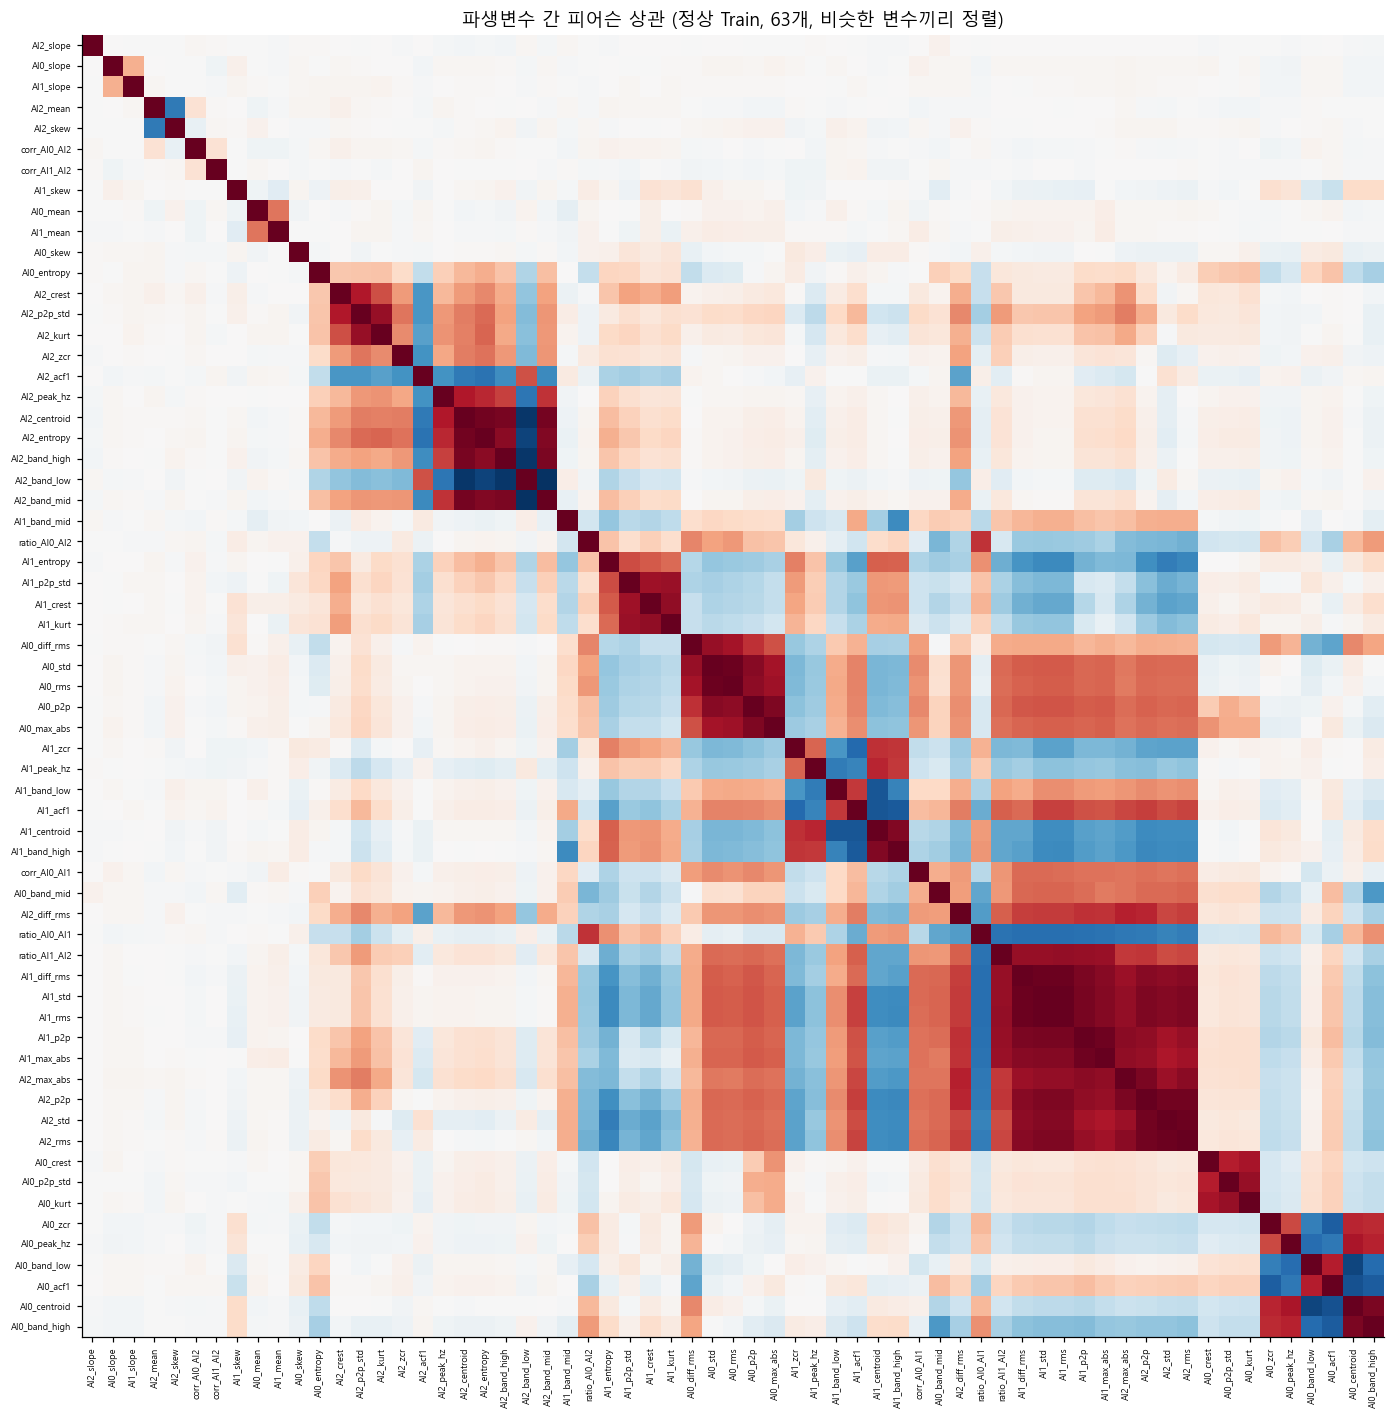

변수 63개 → 상관 0.9 이상끼리 묶으면 49개 묶음


개수,묶인_변수,대표 변수,대표 AUC
5,"AI2_band_high, AI2_band_low, AI2_centroid, AI2_entropy, AI2_band_mid",AI2_band_high,1.000
1,AI2_acf1,AI2_acf1,0.999
1,ratio_AI1_AI2,ratio_AI1_AI2,0.999
1,corr_AI0_AI1,corr_AI0_AI1,0.989
1,ratio_AI0_AI2,ratio_AI0_AI2,0.985
1,AI1_peak_hz,AI1_peak_hz,0.976
1,AI2_p2p_std,AI2_p2p_std,0.953
1,AI1_band_mid,AI1_band_mid,0.952
1,AI2_kurt,AI2_kurt,0.950
1,AI1_zcr,AI1_zcr,0.946


변수 1,변수 2,|상관|
AI1_std,AI1_rms,1.000
AI2_band_low,AI2_band_mid,0.991
AI1_std,AI1_diff_rms,0.984
AI1_rms,AI1_diff_rms,0.983
AI2_std,AI2_rms,0.983
AI0_std,AI0_rms,0.980
AI2_band_low,AI2_band_high,0.975
AI1_p2p,AI1_max_abs,0.975
AI2_centroid,AI2_band_low,0.970
AI2_centroid,AI2_entropy,0.967


In [16]:
USE = [c for c in FEAT.columns if FEAT.loc[TR, c].std() > 0]
CONST = [c for c in FEAT.columns if c not in USE]
if CONST:
    print('정상 Train에서 값이 하나뿐이라 상관·PCA에서 뺀 변수:', ', '.join(CONST))
RHO = FEAT.loc[TR, USE].corr().fillna(0)
D = 1 - RHO.abs().to_numpy()
np.fill_diagonal(D, 0)
D = np.clip((D + D.T) / 2, 0, None)
LINK = hierarchy.linkage(squareform(D, checks=False), 'average')
ORDER = [USE[i] for i in hierarchy.leaves_list(LINK)]
CL = pd.DataFrame({'feature': USE, 'cluster': hierarchy.fcluster(LINK, t=0.1, criterion='distance')})
CL = CL.merge(RANK[['feature', 'AUC', 'category', 'abs_effect']], on='feature')
REPS = (CL.sort_values(['AUC', 'abs_effect'], ascending=False, na_position='last')
        .drop_duplicates('cluster').reset_index(drop=True))
CL_TAB = (CL.sort_values('AUC', ascending=False).groupby('cluster')
          .agg(개수=('feature', 'size'), 묶인_변수=('feature', ', '.join))
          .join(REPS.set_index('cluster')[['feature', 'AUC']].rename(columns={'feature': '대표 변수', 'AUC': '대표 AUC'}))
          .sort_values('대표 AUC', ascending=False).reset_index(drop=True))
save_table(CL_TAB, 'feature_clusters', index=False)

up = RHO.where(np.triu(np.ones(RHO.shape, dtype=bool), 1)).stack()
PAIR_TAB = (up[up.abs() >= .95].abs().sort_values(ascending=False).head(15).reset_index()
            .set_axis(['변수 1', '변수 2', '|상관|'], axis=1))

fig, ax = plt.subplots(figsize=(15, 13))
heat(ax, RHO.loc[ORDER, ORDER], f'파생변수 간 피어슨 상관 (정상 Train, {len(USE)}개, 비슷한 변수끼리 정렬)', annot=False, fs=6)
plt.tight_layout()
show('06_1_feature_corr', '파생변수 간 상관 히트맵 (정상 Train)')
print(f'변수 {len(USE)}개 → 상관 0.9 이상끼리 묶으면 {len(CL_TAB)}개 묶음')
display(CL_TAB.head(15).style.format({'대표 AUC': '{:.3f}'}).hide(axis='index').set_caption('묶음별 대표 변수 (구분력 순, 상위 15개)'))
display(PAIR_TAB.style.format({'|상관|': '{:.3f}'}).hide(axis='index').set_caption('거의 같은 정보를 가진 변수 쌍 (|상관| ≥ 0.95)'))

In [17]:
# 06-2 상관 방법 점검: 피어슨과 스피어만 비교 (정상 Train)
from sklearn.metrics import adjusted_rand_score
RHO_S = FEAT.loc[TR, USE].corr(method='spearman').fillna(0)
iu = np.triu_indices(len(USE), 1)
diff_ps = np.abs(RHO.to_numpy()[iu] - RHO_S.to_numpy()[iu])


def n_clusters(R):
    d = 1 - R.abs().to_numpy()
    np.fill_diagonal(d, 0)
    d = np.clip((d + d.T) / 2, 0, None)
    return hierarchy.fcluster(hierarchy.linkage(squareform(d, checks=False), 'average'), t=0.1, criterion='distance')


cl_s = n_clusters(RHO_S)
skew = FEAT.loc[TR, USE].skew().abs()
METHOD_TAB = pd.DataFrame({'값': [f'{int((skew > 1).sum())}개 / {len(USE)}개', f'{np.median(diff_ps):.3f}',
                                   f'{int((diff_ps >= .2).sum())}쌍 / {len(diff_ps):,}쌍', f'{diff_ps.max():.2f}',
                                   f'{len(CL_TAB)}개 / {cl_s.max()}개',
                                   f'{adjusted_rand_score(CL.set_index("feature").loc[USE, "cluster"], cl_s):.2f}']},
                          index=['많이 치우친 변수 (왜도 절댓값 > 1)', '피어슨과 스피어만 차이의 중앙값', '차이가 0.2 이상인 변수 쌍',
                                 '가장 큰 차이', '묶음 수 (피어슨 / 스피어만)', '묶음 결과 일치도 (ARI, 1 = 같음)'])
METHOD_TAB.index.name = '항목'
METHOD_OK = bool(np.median(diff_ps) < .05)
display(METHOD_TAB.style.set_caption('피어슨과 스피어만 비교 (정상 Train 파생변수)'))
print('두 방법이 거의 같아 피어슨 하나로 봐도 됩니다.' if METHOD_OK else '두 방법 차이가 커서 스피어만 결과도 함께 봐야 합니다.')

,값
항목,
많이 치우친 변수 (왜도 절댓값 > 1),19개 / 63개
피어슨과 스피어만 차이의 중앙값,0.017
차이가 0.2 이상인 변수 쌍,"98쌍 / 1,953쌍"
가장 큰 차이,0.40
묶음 수 (피어슨 / 스피어만),49개 / 46개
"묶음 결과 일치도 (ARI, 1 = 같음)",0.77


두 방법이 거의 같아 피어슨 하나로 봐도 됩니다.


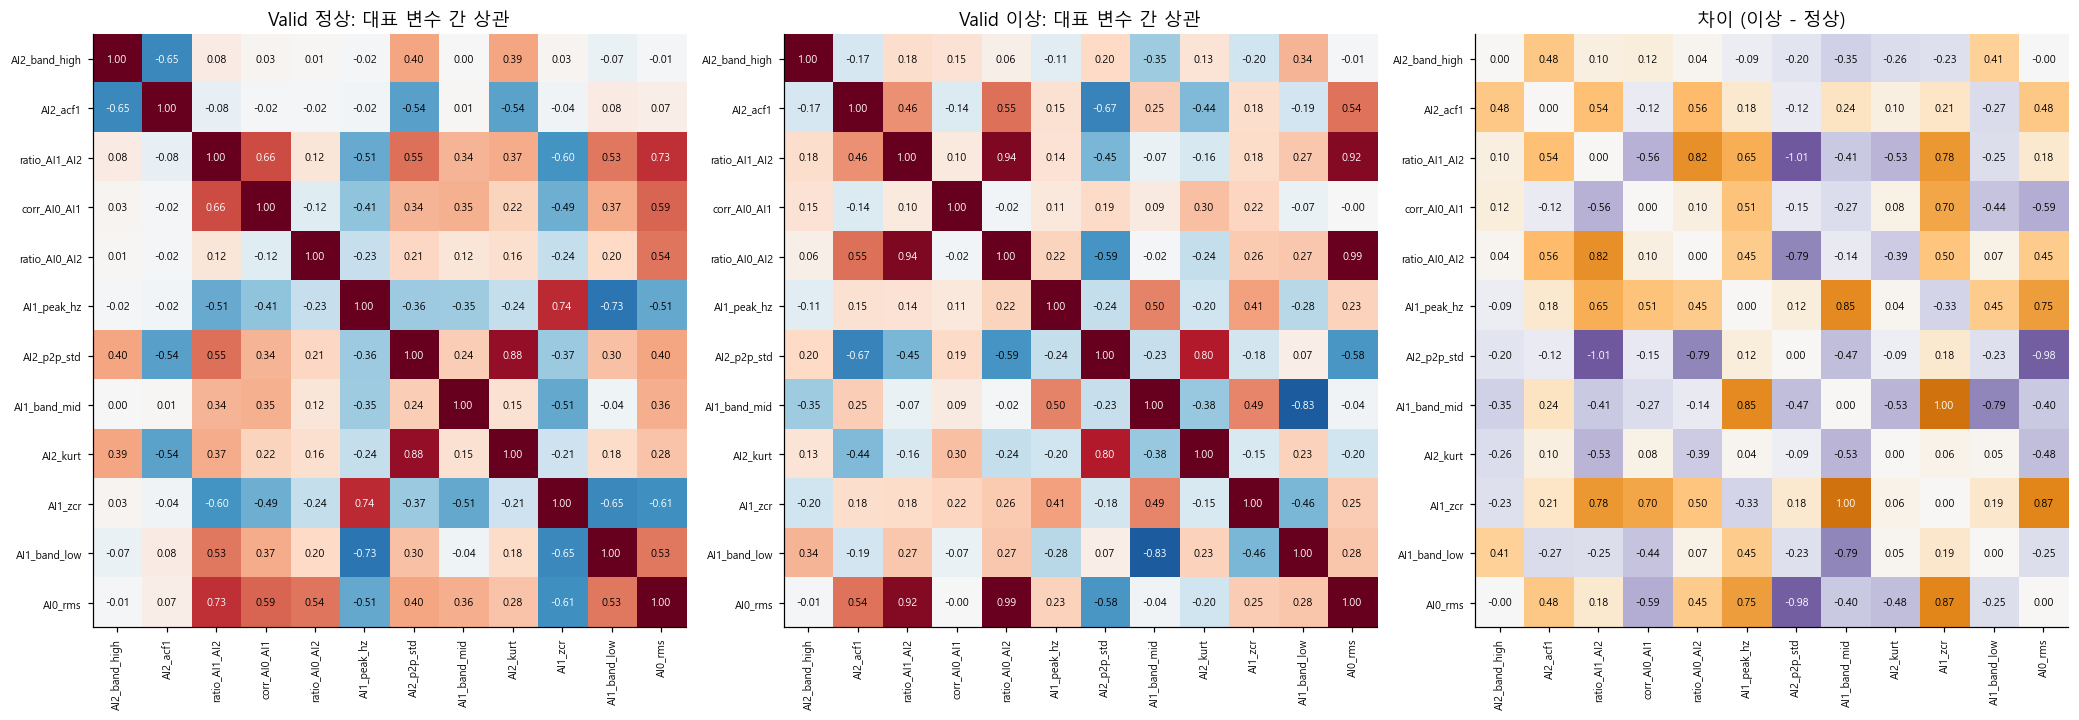

변수 1,변수 2,정상 상관,이상 상관,차이
ratio_AI1_AI2,AI2_p2p_std,+0.55,-0.45,-1.01
AI1_band_mid,AI1_zcr,-0.51,+0.49,+1.00
AI2_p2p_std,AI0_rms,+0.40,-0.58,-0.98
AI1_zcr,AI0_rms,-0.61,+0.25,+0.87
AI1_peak_hz,AI1_band_mid,-0.35,+0.50,+0.85
ratio_AI1_AI2,ratio_AI0_AI2,+0.12,+0.94,+0.82
ratio_AI0_AI2,AI2_p2p_std,+0.21,-0.59,-0.79
AI1_band_mid,AI1_band_low,-0.04,-0.83,-0.79


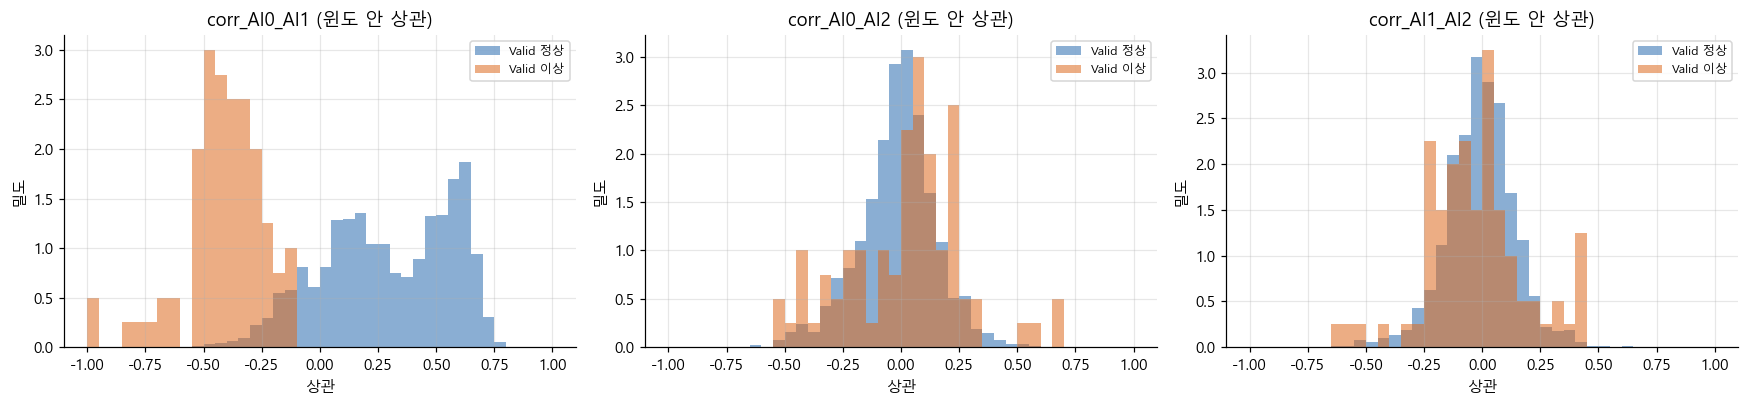

In [18]:
SEL = REPS.feature.head(12).tolist()
REL = {lab: FEAT.loc[VA & (WMETA.label == lab).to_numpy(), SEL].corr() for lab in (0, 1)}
fig, axes = plt.subplots(1, 3, figsize=(19, 6.3))
heat(axes[0], REL[0], 'Valid 정상: 대표 변수 간 상관', fs=7)
heat(axes[1], REL[1], 'Valid 이상: 대표 변수 간 상관', fs=7)
heat(axes[2], REL[1] - REL[0], '차이 (이상 - 정상)', cmap='PuOr_r', vmin=-1.5, vmax=1.5, fs=7)
plt.tight_layout()
show('06_3_relation_change', '대표 변수 간 관계가 이상에서 어떻게 바뀌는지')
dd = (REL[1] - REL[0]).where(np.triu(np.ones((len(SEL), len(SEL)), dtype=bool), 1)).stack()
REL_TAB = pd.DataFrame({'변수 1': [a for a, b in dd.index], '변수 2': [b for a, b in dd.index],
                        '정상 상관': [REL[0].loc[a, b] for a, b in dd.index], '이상 상관': [REL[1].loc[a, b] for a, b in dd.index],
                        '차이': dd.values})
REL_TAB = REL_TAB.reindex(REL_TAB['차이'].abs().sort_values(ascending=False).index).head(8).reset_index(drop=True)
display(REL_TAB.style.format({'정상 상관': '{:+.2f}', '이상 상관': '{:+.2f}', '차이': '{:+.2f}'}).hide(axis='index')
        .set_caption('이상에서 가장 크게 바뀌는 관계'))

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, f in zip(axes, ['corr_AI0_AI1', 'corr_AI0_AI2', 'corr_AI1_AI2']):
    for lab in (0, 1):
        ax.hist(FEAT.loc[VA & (WMETA.label == lab).to_numpy(), f], bins=np.linspace(-1, 1, 41), density=True,
                alpha=.55, color=COL[lab], label=f'Valid {LAB[lab]}')
    ax.set(title=f'{f} (윈도 안 상관)', xlabel='상관', ylabel='밀도')
    ax.legend(fontsize=8)
plt.tight_layout()
show('06_4_window_corr', '윈도 안 센서 간 상관의 분포 (Valid)')

### 06-5 VIF로 다중공선성 확인과 대표 변수 고르기

1. 정상 Train에서 변수 전체의 VIF를 계산해 겹침 정도를 봅니다.
2. 묶음별 대표 변수 전체에서 시작합니다. VIF가 `VIF_MAX`를 넘는 변수가 있으면, **그중 구분력이 가장 낮은 변수**를 하나 뺍니다. 모두 기준 안에 들 때까지 반복합니다.
3. 남은 변수 중 구분력 상위 `TOP_K`개를 고릅니다. 이 변수들이 09 단계의 "대표 변수 마할라노비스 거리²" 후보에 들어갑니다.

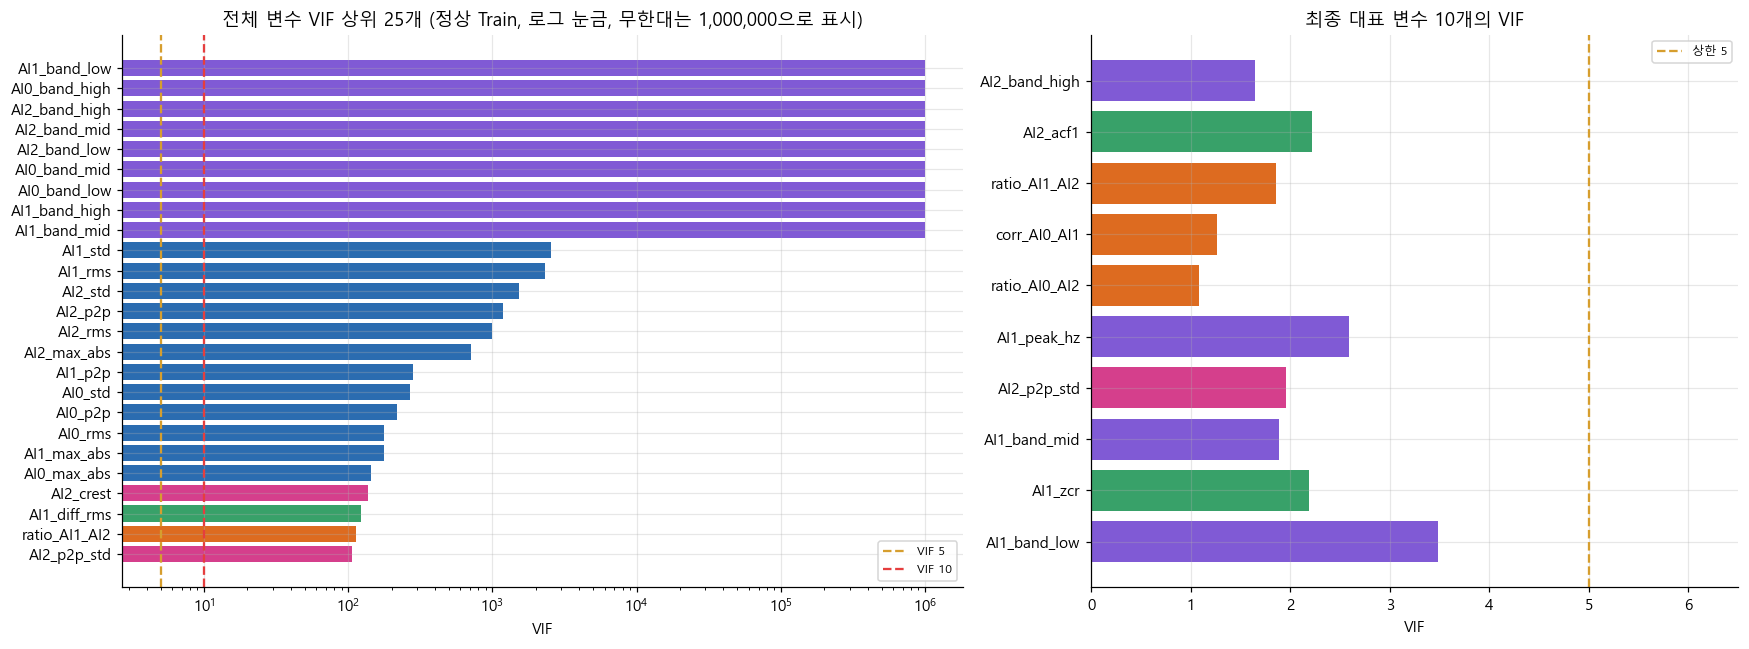

,값
항목,
전체 변수 수,63
VIF > 5,43
VIF > 10,39
VIF 무한대 (다른 변수로 정확히 계산됨),9
최종 대표 변수 수,10
최종 대표 변수의 최대 VIF,3.48
VIF 때문에 뺀 대표 변수,17


변수,AUC,VIF,분류
AI2_band_high,1.000,1.64,주파수
AI2_acf1,0.999,2.22,시간 변화
ratio_AI1_AI2,0.999,1.86,센서 간 관계
corr_AI0_AI1,0.989,1.26,센서 간 관계
ratio_AI0_AI2,0.985,1.08,센서 간 관계
AI1_peak_hz,0.976,2.59,주파수
AI2_p2p_std,0.953,1.96,모양
AI1_band_mid,0.952,1.89,주파수
AI1_zcr,0.946,2.19,시간 변화
AI1_band_low,0.944,3.48,주파수


뺀 변수,그때 VIF,AUC,가장 많이 겹친 변수,상관 절댓값
AI0_kurt,5.7,0.542,AI0_p2p_std,0.87
AI1_crest,7.4,0.545,AI1_kurt,0.89
AI2_max_abs,104.0,0.553,AI1_rms,0.88
AI1_p2p_std,5.7,0.571,AI1_kurt,0.86
AI0_crest,18.6,0.680,AI0_p2p_std,0.79
AI0_diff_rms,20.9,0.776,AI0_rms,0.83
AI2_std,45.5,0.798,AI1_rms,0.92
ratio_AI0_AI1,23.7,0.813,AI1_rms,0.75
AI0_band_mid,8.9,0.819,AI1_rms,0.58
AI1_acf1,6.2,0.872,AI1_centroid,0.86


In [19]:
def vif_table(cols):
    # 정상 Train에서 각 변수를 나머지 변수들로 회귀해 VIF = 1 / (1 - R²)를 계산합니다.
    Xv = FEAT.loc[TR, cols]
    Xv = Xv.fillna(Xv.median())
    Xv = (Xv - Xv.mean()) / Xv.std()
    out = {}
    for c in cols:
        if len(cols) == 1:
            out[c] = 1.0
            continue
        A = np.c_[np.ones(len(Xv)), Xv.drop(columns=c).to_numpy()]
        y = Xv[c].to_numpy()
        beta = np.linalg.lstsq(A, y, rcond=None)[0]
        r2 = 1 - ((y - A @ beta) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        out[c] = np.inf if r2 >= 1 - 1e-10 else 1 / (1 - r2)
    return pd.Series(out)


VIF_ALL = vif_table(USE).sort_values(ascending=False)
AUC_OF = RANK.set_index('feature')['AUC']
pool, SKIPPED = REPS.feature.tolist(), []
while True:
    v = vif_table(pool)
    over = v[v > VIF_MAX]
    if over.empty:
        break
    drop = AUC_OF.loc[over.index].sort_values().index[0]       # 기준을 넘는 변수 중 구분력이 가장 낮은 변수
    pool.remove(drop)
    partner = RHO.loc[drop, pool].abs().idxmax()                # 가장 많이 겹치는 남은 변수
    SKIPPED.append({'뺀 변수': drop, '그때 VIF': v[drop], 'AUC': AUC_OF[drop], '가장 많이 겹친 변수': partner,
                    '상관 절댓값': abs(RHO.loc[drop, partner])})
SELECTED_VIF = sorted(pool, key=lambda f: -AUC_OF[f])[:TOP_K]
VIF_SEL = vif_table(SELECTED_VIF)
SEL_TAB = pd.DataFrame({'변수': SELECTED_VIF, 'AUC': RANK.set_index('feature').loc[SELECTED_VIF, 'AUC'].to_numpy(),
                        'VIF': VIF_SEL.loc[SELECTED_VIF].to_numpy(), '분류': [category(f) for f in SELECTED_VIF]})
SKIP_TAB = pd.DataFrame(SKIPPED, columns=['뺀 변수', '그때 VIF', 'AUC', '가장 많이 겹친 변수', '상관 절댓값'])
VIF_SUM = pd.DataFrame({'값': [len(USE), int((VIF_ALL > 5).sum()), int((VIF_ALL > 10).sum()), int(np.isinf(VIF_ALL).sum()),
                                len(SELECTED_VIF), f'{VIF_SEL.max():.2f}', len(SKIPPED)]},
                       index=['전체 변수 수', 'VIF > 5', 'VIF > 10', 'VIF 무한대 (다른 변수로 정확히 계산됨)',
                              '최종 대표 변수 수', '최종 대표 변수의 최대 VIF', 'VIF 때문에 뺀 대표 변수'])
VIF_SUM.index.name = '항목'
_Xv = FEAT.loc[TR, SELECTED_VIF]
_Xv = _Xv.fillna(_Xv.median())
VIF_OK = bool(np.allclose(VIF_SEL.loc[SELECTED_VIF].to_numpy(), np.diag(np.linalg.inv(np.corrcoef(_Xv.to_numpy().T))), rtol=1e-6))
check('VIF는 정상 Train으로만 계산', VIF_OK, f'대표 변수 {len(SELECTED_VIF)}개, 최대 VIF {VIF_SEL.max():.2f} (상한 {VIF_MAX:g})')
save_table(VIF_ALL.rename('VIF').rename_axis('feature').reset_index(), 'vif_all', index=False)
save_table(SEL_TAB, 'selected_features_vif', index=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.3, 1]})
top = VIF_ALL.head(25).iloc[::-1].replace(np.inf, 1e6)
axes[0].barh(top.index, top.values, color=[CAT_COL[category(f)] for f in top.index])
axes[0].set_xscale('log')
for x, c in [(5, '#d69e2e'), (10, '#e53e3e')]:
    axes[0].axvline(x, color=c, ls='--', label=f'VIF {x}')
axes[0].set(title=f'전체 변수 VIF 상위 25개 (정상 Train, 로그 눈금, 무한대는 1,000,000으로 표시)', xlabel='VIF')
axes[0].legend(fontsize=8)
sv = SEL_TAB.iloc[::-1]
axes[1].barh(sv['변수'], sv['VIF'], color=[CAT_COL[c] for c in sv['분류']])
axes[1].axvline(VIF_MAX, color='#d69e2e', ls='--', label=f'상한 {VIF_MAX:g}')
axes[1].set(title=f'최종 대표 변수 {len(SELECTED_VIF)}개의 VIF', xlabel='VIF', xlim=(0, max(VIF_MAX * 1.3, VIF_SEL.max() * 1.1)))
axes[1].legend(fontsize=8)
plt.tight_layout()
show('06_5_vif', 'VIF: 전체 변수의 겹침(왼쪽)과 최종 대표 변수(오른쪽)')
display(VIF_SUM)
display(SEL_TAB.style.format({'AUC': '{:.3f}', 'VIF': '{:.2f}'}).hide(axis='index').set_caption('최종 대표 변수 (구분력 순, VIF 기준 통과)'))
if len(SKIP_TAB):
    display(SKIP_TAB.style.format({'AUC': '{:.3f}', '그때 VIF': '{:.1f}', '상관 절댓값': '{:.2f}'}).hide(axis='index').set_caption('VIF 때문에 뺀 대표 변수 (뺀 순서)'))

## 07 고윳값(PCA): 정상 데이터는 몇 차원인가

변수들을 정상 Train 기준으로 표준화한 뒤 **상관행렬의 고윳값**을 구합니다(PCA). 고윳값은 그 방향(주성분)으로 정상 데이터가 얼마나 퍼져 있는지입니다.

| 점수 | 뜻 |
|---|---|
| **Hotelling T²** | 정상이 퍼진 방향 안에서, 고윳값으로 나눠 잰 중심과의 거리. "익숙한 방향이지만 너무 멀리 감" |
| **SPE (Q)** | 주성분으로 설명되지 않는 나머지의 크기. "정상에서 본 적 없는 방향으로 벗어남" |
| **마할라노비스 거리²** | 모든 방향을 고윳값으로 보정한 거리의 **제곱**입니다. 순서는 거리와 같아서 판정 결과는 같습니다 |

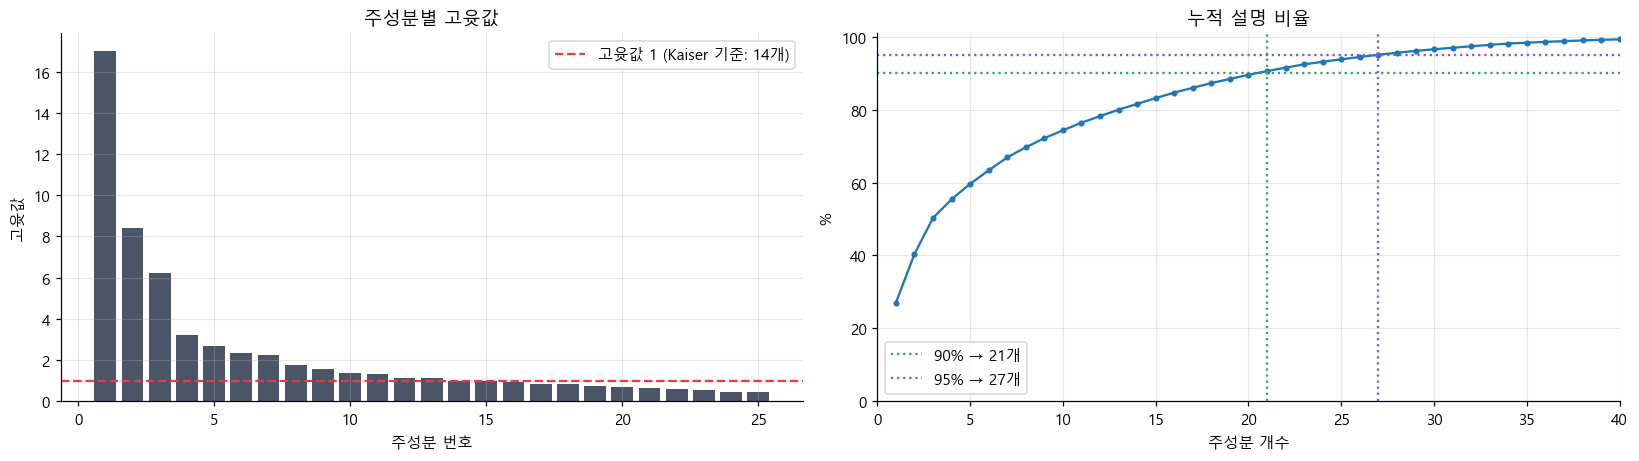

,값
항목,
사용한 변수 수,63
고윳값 > 1인 주성분 수,14
90% 설명에 필요한 주성분 수,21
95% 설명에 필요한 주성분 수,27
주성분 1의 설명 비율,27%
주성분 1+2의 설명 비율,40%


In [20]:
FEAT_COLS = USE
MED = FEAT.loc[TR, FEAT_COLS].median()
ZRAW = FEAT[FEAT_COLS].fillna(MED)
SCALER = StandardScaler().fit(ZRAW[TR])
ZS = SCALER.transform(ZRAW)
pca = PCA().fit(ZS[TR])
EV = pca.explained_variance_
CUM = np.cumsum(pca.explained_variance_ratio_)
K90 = int(np.searchsorted(CUM, .90) + 1)
K95 = int(np.searchsorted(CUM, .95) + 1)
KAISER = int((EV > 1).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
n_show = min(25, len(EV))
axes[0].bar(np.arange(1, n_show + 1), EV[:n_show], color='#4a5568')
axes[0].axhline(1, color='#e53e3e', ls='--', label=f'고윳값 1 (Kaiser 기준: {KAISER}개)')
axes[0].set(title='주성분별 고윳값', xlabel='주성분 번호', ylabel='고윳값')
axes[0].legend()
axes[1].plot(np.arange(1, len(CUM) + 1), CUM * 100, marker='o', ms=3)
for k, p, c in [(K90, 90, '#38a169'), (K95, 95, '#805ad5')]:
    axes[1].axhline(p, color=c, ls=':')
    axes[1].axvline(k, color=c, ls=':', label=f'{p}% → {k}개')
axes[1].set(title='누적 설명 비율', xlabel='주성분 개수', ylabel='%', xlim=(0, min(40, len(CUM))), ylim=(0, 101))
axes[1].legend()
plt.tight_layout()
show('07_1_scree', '정상 Train 파생변수의 고윳값과 누적 설명 비율')
PCA_SUM = pd.DataFrame({'값': [len(FEAT_COLS), KAISER, K90, K95, f'{pca.explained_variance_ratio_[0]:.0%}',
                                f'{CUM[min(2, len(CUM)) - 1]:.0%}']},
                       index=['사용한 변수 수', '고윳값 > 1인 주성분 수', '90% 설명에 필요한 주성분 수',
                              '95% 설명에 필요한 주성분 수', '주성분 1의 설명 비율', '주성분 1+2의 설명 비율'])
PCA_SUM.index.name = '항목'
display(PCA_SUM)

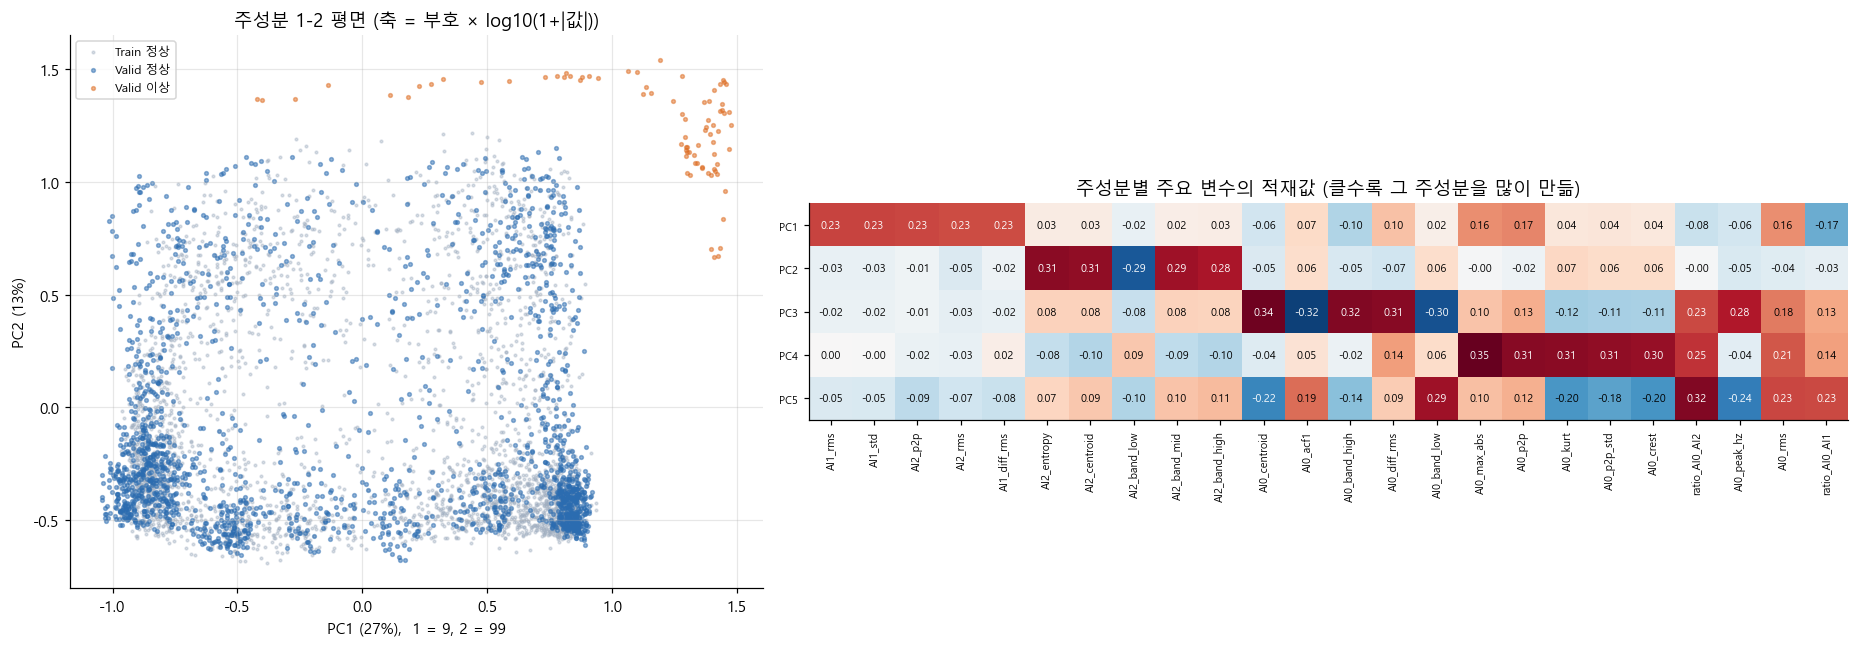

,PC1,PC2,PC3,PC4,PC5
순위,,,,,
1위,AI1_rms (+0.23),AI2_entropy (+0.31),AI0_centroid (+0.34),AI0_max_abs (+0.35),ratio_AI0_AI2 (+0.32)
2위,AI1_std (+0.23),AI2_centroid (+0.31),AI0_acf1 (-0.32),AI0_p2p (+0.31),AI0_band_low (+0.29)
3위,AI2_p2p (+0.23),AI2_band_low (-0.29),AI0_band_high (+0.32),AI0_kurt (+0.31),AI0_peak_hz (-0.24)
4위,AI2_rms (+0.23),AI2_band_mid (+0.29),AI0_diff_rms (+0.31),AI0_p2p_std (+0.31),AI0_rms (+0.23)


In [21]:
PC = pca.transform(ZS)
LOAD = pd.DataFrame(pca.components_[:5], columns=FEAT_COLS, index=[f'PC{i + 1}' for i in range(5)])
pick = list(dict.fromkeys(f for i in range(5) for f in LOAD.iloc[i].abs().sort_values(ascending=False).index[:5]))
fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={'width_ratios': [1, 1.5]})
sub = np.flatnonzero(TR)
sub = rng.choice(sub, min(3000, len(sub)), replace=False)
slog = lambda v: np.sign(v) * np.log10(1 + np.abs(v))   # 부호를 유지한 로그: 0 근처와 아주 먼 값을 함께 보이게 함
axes[0].scatter(slog(PC[sub, 0]), slog(PC[sub, 1]), s=3, color='#a0aec0', alpha=.4, label='Train 정상')
for lab in (0, 1):
    m = VA & (WMETA.label == lab).to_numpy()
    axes[0].scatter(slog(PC[m, 0]), slog(PC[m, 1]), s=6, color=COL[lab], alpha=.5, label=f'Valid {LAB[lab]}')
axes[0].set(title='주성분 1-2 평면 (축 = 부호 × log10(1+|값|))',
            xlabel=f'PC1 ({pca.explained_variance_ratio_[0]:.0%}),  1 = 9, 2 = 99',
            ylabel=f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
axes[0].legend(fontsize=8)
vmax = float(LOAD[pick].abs().max().max())
heat(axes[1], LOAD[pick], '주성분별 주요 변수의 적재값 (클수록 그 주성분을 많이 만듦)', vmin=-vmax, vmax=vmax, fs=7)
plt.tight_layout()
show('07_2_pc_scatter', '주성분 평면의 정상·이상과 주성분 적재값')
PCLOAD_TAB = pd.DataFrame({f'PC{i + 1}': [f'{f} ({LOAD.iloc[i][f]:+.2f})' for f in LOAD.iloc[i].abs().sort_values(ascending=False).index[:4]]
                         for i in range(5)}, index=[f'{k}위' for k in range(1, 5)])
PCLOAD_TAB.index.name = '순위'
display(PCLOAD_TAB.style.set_caption('주성분마다 가장 큰 적재값 4개'))

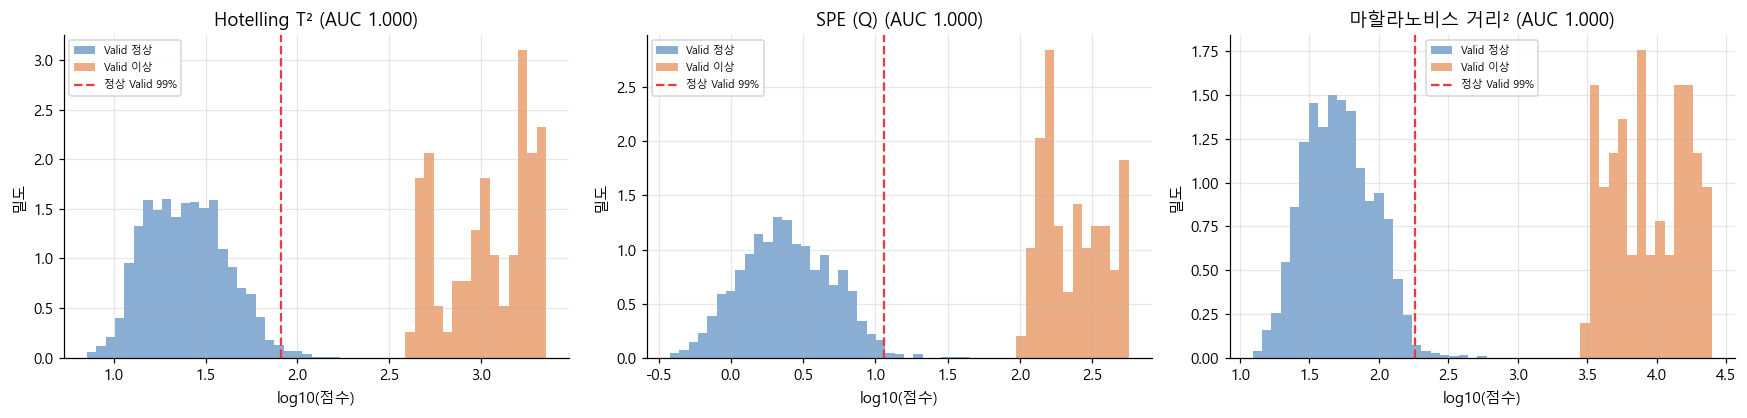

,Valid AUC
점수,
Hotelling T²,1.000
SPE (Q),1.000
마할라노비스 거리²,1.000
(비교) 가장 좋은 단일 변수 AI2_band_high,1.000


In [22]:
P = pca.components_[:K95]
ZC = ZS - pca.mean_
T = ZC @ P.T
T2 = (T ** 2 / EV[:K95]).sum(1)
SPE = ((ZC - T @ P) ** 2).sum(1)
LW_ALL = LedoitWolf().fit(ZS[TR])
MD = LW_ALL.mahalanobis(ZS)
FIT_OK = (int(np.ravel(SCALER.n_samples_seen_)[0]) == int(TR.sum()) and int(pca.n_samples_) == int(TR.sum())
          and np.allclose(SCALER.mean_, ZRAW[TR].mean().to_numpy()) and np.allclose(LW_ALL.location_, ZS[TR].mean(0)))
check('표준화·결측 대치·PCA·공분산은 정상 Train으로만 계산', bool(FIT_OK),
      f'학습에 쓴 윈도 수와 평균을 다시 계산해 정상 Train {int(TR.sum()):,}개와 일치 확인')
SCORES = {'Hotelling T²': T2, 'SPE (Q)': SPE, '마할라노비스 거리²': MD}
SCORE_AUC = {k: roc_auc_score(yv, v[VA]) for k, v in SCORES.items()}
SCORE_TAB = pd.Series({**SCORE_AUC, f'(비교) 가장 좋은 단일 변수 {RANK.feature.iloc[0]}': RANK.AUC.iloc[0]}).to_frame('Valid AUC')
SCORE_TAB.index.name = '점수'

fig, axes = plt.subplots(1, 3, figsize=(16, 3.9))
for ax, (k, v) in zip(axes, SCORES.items()):
    lv = np.log10(np.maximum(v[VA], 1e-9))
    bins = np.linspace(*np.quantile(lv, [.002, .998]), 50)
    for lab in (0, 1):
        ax.hist(lv[yv == lab], bins=bins, density=True, alpha=.55, color=COL[lab], label=f'Valid {LAB[lab]}')
    ax.axvline(np.log10(np.quantile(v[VN], .99)), color='#e53e3e', ls='--', label='정상 Valid 99%')
    ax.set(title=f'{k} (AUC {SCORE_AUC[k]:.3f})', xlabel='log10(점수)', ylabel='밀도')
    ax.legend(fontsize=7)
plt.tight_layout()
show('07_3_pca_scores', f'고윳값 기반 이상 점수 분포 (주성분 {K95}개 사용)')
display(SCORE_TAB.style.format('{:.3f}').set_caption('고윳값 기반 점수와 가장 좋은 단일 변수의 Valid 구분력'))

## 08 시간에 따른 변화와 공백 관련 점검 (정상만)

- **08-1 드리프트**: 정상 Train과 정상 Valid의 분포 차이(KS)입니다. 클수록 시간이 지나며 정상 상태 자체가 변한 변수입니다.
- **08-2 시간 추세**: 대표 변수 4개의 판정 단위 구간별 중앙값을 시간 순서로 그렸습니다. 회색 띠는 Valid 이상의 25-75% 범위입니다.
- **08-3 공백 관련 점검**
  - 공백을 고려하는 폴더(v4_1): **재시작 직후 효과**. 구간 첫 윈도의 값이 1초 이후와 정상 IQR의 몇 배만큼 다른지 봅니다. 0.5배를 넘으면 효과가 있다고 봅니다.
  - 공백을 무시하는 폴더(v4_2, v4_3): **끊김을 넘는 윈도의 영향**. 같은 정상 Train 안에서 끊김을 넘는 윈도와 안 넘는 윈도의 변수 분포(KS)와 PCA T²를 비교합니다. 정상 Valid 오탐률 비교는 09 단계에서 합니다.

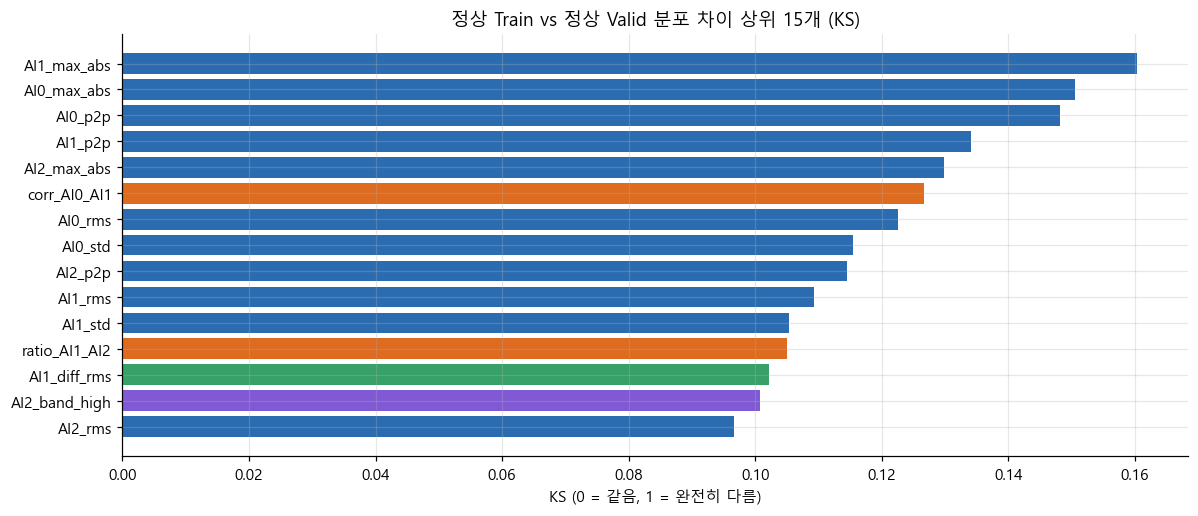

변수,KS,Train 중앙값,Valid 중앙값,구분력 AUC
AI1_max_abs,0.16,0.2392,0.2284,0.866
AI0_max_abs,0.15,0.154,0.1498,0.875
AI0_p2p,0.15,0.272,0.2713,0.821
AI1_p2p,0.13,0.4133,0.3657,0.813
AI2_max_abs,0.13,209.8,192.6,0.553
corr_AI0_AI1,0.13,0.3648,0.2916,0.989
AI0_rms,0.12,0.07289,0.07234,0.928
AI0_std,0.12,0.07114,0.07104,0.807
AI2_p2p,0.11,374.8,351.5,0.660
AI1_rms,0.11,0.119,0.1111,0.919


In [23]:
drift = []
for f in USE:
    a, b = FEAT.loc[TR, f].dropna(), FEAT.loc[VN, f].dropna()
    drift.append({'변수': f, 'KS': stats.ks_2samp(a, b).statistic, 'Train 중앙값': a.median(), 'Valid 중앙값': b.median()})
DRIFT = pd.DataFrame(drift).sort_values('KS', ascending=False).reset_index(drop=True)
DRIFT = DRIFT.merge(RANK[['feature', 'AUC']].rename(columns={'feature': '변수', 'AUC': '구분력 AUC'}), on='변수')
save_table(DRIFT, 'feature_drift', index=False)

fig, ax = plt.subplots(figsize=(11, 4.8))
d15 = DRIFT.head(15).iloc[::-1]
ax.barh(d15['변수'], d15['KS'], color=[CAT_COL[category(f)] for f in d15['변수']])
ax.set(title='정상 Train vs 정상 Valid 분포 차이 상위 15개 (KS)', xlabel='KS (0 = 같음, 1 = 완전히 다름)')
plt.tight_layout()
show('08_1_drift', '정상 상태의 시간에 따른 변화(드리프트)')
display(DRIFT.head(10).style.format({'KS': '{:.2f}', 'Train 중앙값': '{:.4g}', 'Valid 중앙값': '{:.4g}', '구분력 AUC': '{:.3f}'})
        .hide(axis='index').set_caption('드리프트 상위 10개'))

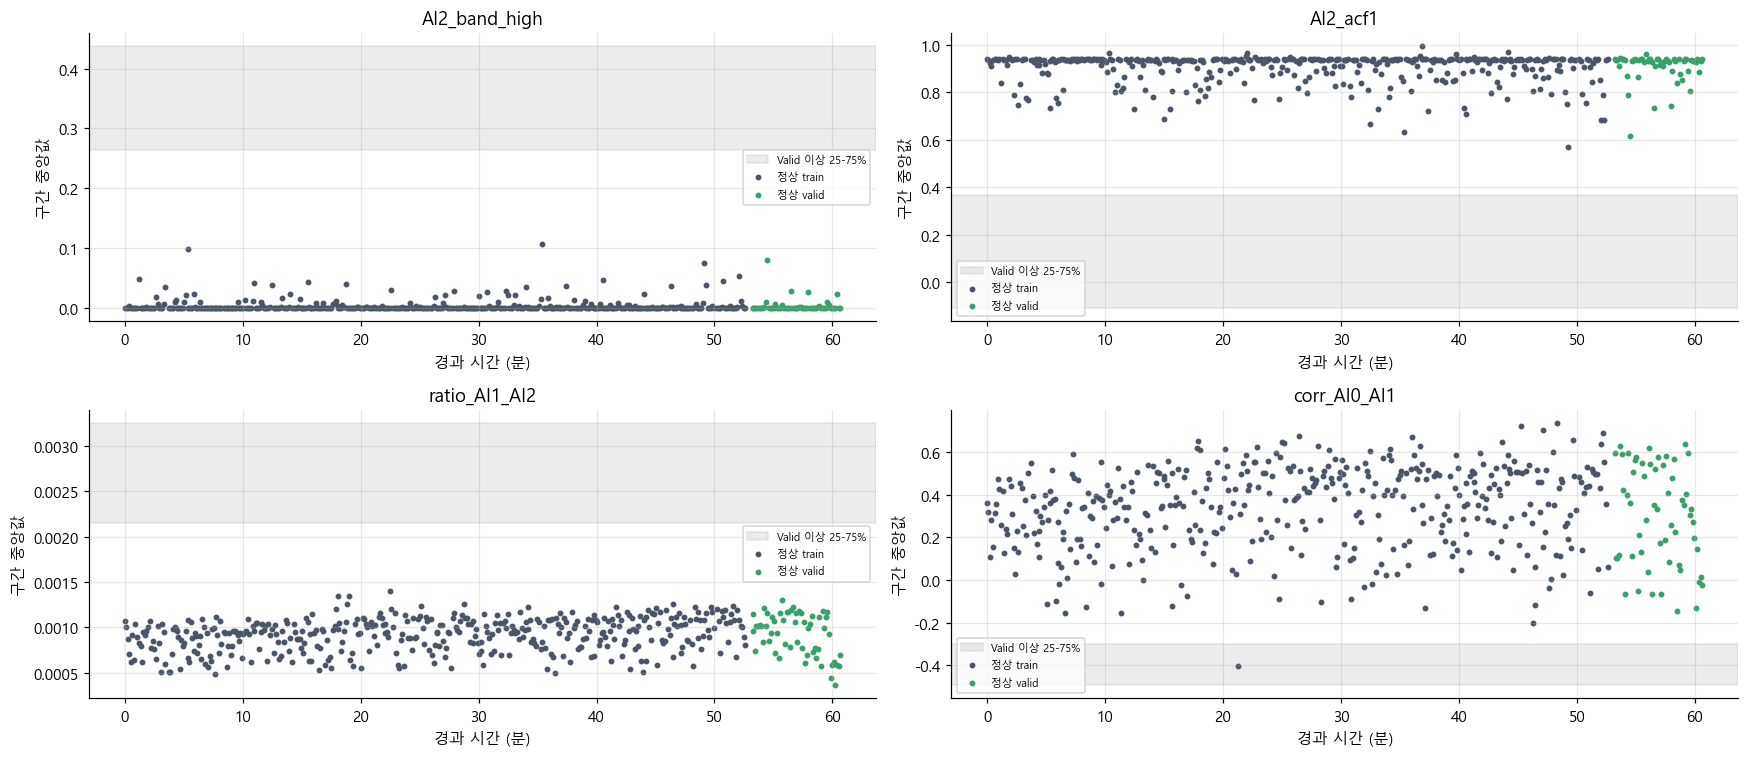

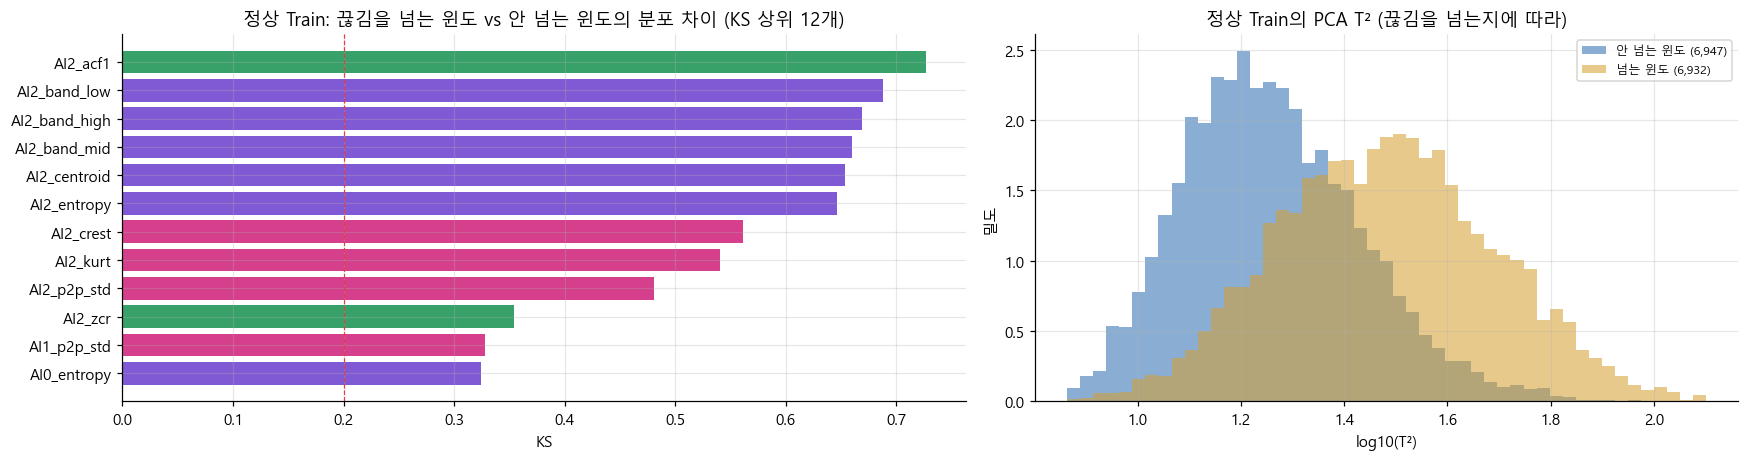

정상 Train 윈도 중 끊김을 넘는 비율: 50% | KS > 0.2인 변수: 23개


변수,KS,넘는 윈도 중앙값,안 넘는 윈도 중앙값
AI2_acf1,0.73,0.8706,0.9394
AI2_band_low,0.69,0.9872,0.9979
AI2_band_high,0.67,0.00383,0.0005533
AI2_band_mid,0.66,0.008729,0.001483
AI2_centroid,0.65,0.7185,0.6531
AI2_entropy,0.65,0.3446,0.2781
AI2_crest,0.56,1.638,1.436
AI2_kurt,0.54,-1.227,-1.406
AI2_p2p_std,0.48,3.142,2.884
AI2_zcr,0.35,0.1579,0.1053


,값
넘는 윈도 T² 중앙값,30.3
안 넘는 윈도 T² 중앙값,17.6
넘는 윈도 중 T²가 안 넘는 윈도 99% 값을 초과한 비율,0.138


In [24]:
TOP4 = REPS.feature.head(4).tolist()
seg_med = FEAT[TOP4].assign(segment=WMETA.segment, split=WMETA.split, label=WMETA.label, t=WMETA.end_time) \
    .groupby('segment').agg({**{f: 'median' for f in TOP4}, 'split': 'first', 'label': 'first', 't': 'min'})
nrm = seg_med[(seg_med.label == 0) & seg_med.split.isin(['train', 'valid'])]
t0 = nrm.t.min()
fig, axes = plt.subplots(2, 2, figsize=(16, 7))
for ax, f in zip(axes.ravel(), TOP4):
    q = FEAT.loc[VA & (WMETA.label == 1).to_numpy(), f].quantile([.25, .75])
    ax.axhspan(q.iloc[0], q.iloc[1], color='gray', alpha=.15, label='Valid 이상 25-75%')
    for sp in ['train', 'valid']:
        g = nrm[nrm.split == sp]
        ax.scatter((g.t - t0).dt.total_seconds() / 60, g[f], s=8, color=SPLIT_COL[sp], label=f'정상 {sp}')
    ax.set(title=f, xlabel='경과 시간 (분)', ylabel='구간 중앙값')
    ax.legend(fontsize=7)
plt.tight_layout()
show('08_2_time_trend', '대표 변수의 시간 추세 (정상, 판정 단위 구간별 중앙값)')

POS_TAB, N_POS, GAPKS_TAB, N_GAPKS, GAP_T2 = None, None, None, None, None
if RESPECT_GAPS:
    pos_all = FEAT.loc[TR, USE].assign(pos=WMETA.start_pos[TR].to_numpy())
    rest = pos_all[pos_all.pos >= 10][USE]
    rest_med = rest.median()
    rest_iqr = pd.Series(stats.iqr(rest, axis=0, nan_policy='omit'), index=USE).replace(0, np.nan)
    first_med = pos_all[pos_all.pos == 0][USE].median()
    POS_TAB = pd.DataFrame({'변수': USE, '구간 첫 윈도 중앙값': first_med.values, '1초 이후 중앙값': rest_med.values,
                            '차이 ÷ IQR': ((first_med - rest_med) / rest_iqr).values})
    POS_TAB = POS_TAB.reindex(POS_TAB['차이 ÷ IQR'].abs().sort_values(ascending=False).index).reset_index(drop=True)
    N_POS = int((POS_TAB['차이 ÷ IQR'].abs() > .5).sum())
    save_table(POS_TAB, 'restart_effect', index=False)
    pos_med = pos_all.groupby('pos')[USE].median()
    fig, ax = plt.subplots(figsize=(11, 4))
    for f in POS_TAB['변수'].head(4):
        ax.plot(pos_med.index * PERIOD_S, (pos_med[f] - rest_med[f]) / rest_iqr[f], marker='o', ms=3, label=f)
    ax.axhline(0, color='gray', ls=':')
    for y in (-.5, .5):
        ax.axhline(y, color='#e53e3e', ls='--', lw=.8)
    ax.set(title='구간 안 위치별 중앙값 차이 (1초 이후 대비, IQR 단위) - 차이가 가장 큰 변수 4개',
           xlabel='윈도 시작 위치 (구간 시작부터 초)', ylabel='차이 ÷ IQR')
    ax.legend(fontsize=8)
    plt.tight_layout()
    show('08_3_gap_effect', '재시작 직후 효과 (정상 Train, 전체 변수 중 차이가 큰 4개)')
    print(f'변수 {len(USE)}개 중 구간 첫 윈도에서 IQR의 0.5배 넘게 달라지는 변수: {N_POS}개')
    display(POS_TAB.head(10).style.format({'구간 첫 윈도 중앙값': '{:.4g}', '1초 이후 중앙값': '{:.4g}', '차이 ÷ IQR': '{:+.2f}'})
            .hide(axis='index').set_caption('재시작 직후 차이가 큰 변수 10개'))
else:
    cr = WMETA.crosses_gap.to_numpy()
    a_m, b_m = TR & cr, TR & ~cr
    gk = []
    for f in USE:
        a, b = FEAT.loc[a_m, f].dropna(), FEAT.loc[b_m, f].dropna()
        gk.append({'변수': f, 'KS': stats.ks_2samp(a, b).statistic, '넘는 윈도 중앙값': a.median(), '안 넘는 윈도 중앙값': b.median()})
    GAPKS_TAB = pd.DataFrame(gk).sort_values('KS', ascending=False).reset_index(drop=True)
    N_GAPKS = int((GAPKS_TAB['KS'] > .2).sum())
    save_table(GAPKS_TAB, 'gap_crossing_effect', index=False)
    GAP_T2 = {'넘는 윈도 T² 중앙값': float(np.median(T2[a_m])), '안 넘는 윈도 T² 중앙값': float(np.median(T2[b_m])),
              '넘는 윈도 중 T²가 안 넘는 윈도 99% 값을 초과한 비율': float((T2[a_m] > np.quantile(T2[b_m], .99)).mean())}
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.3), gridspec_kw={'width_ratios': [1.2, 1]})
    g10 = GAPKS_TAB.head(12).iloc[::-1]
    axes[0].barh(g10['변수'], g10['KS'], color=[CAT_COL[category(f)] for f in g10['변수']])
    axes[0].axvline(.2, color='#e53e3e', ls='--', lw=.8)
    axes[0].set(title='정상 Train: 끊김을 넘는 윈도 vs 안 넘는 윈도의 분포 차이 (KS 상위 12개)', xlabel='KS')
    lv = np.log10(np.maximum(T2, 1e-9))
    bins = np.linspace(*np.quantile(lv[TR], [.002, .998]), 50)
    axes[1].hist(lv[b_m], bins=bins, density=True, alpha=.55, color='#2b6cb0', label=f'안 넘는 윈도 ({int(b_m.sum()):,})')
    axes[1].hist(lv[a_m], bins=bins, density=True, alpha=.55, color='#d69e2e', label=f'넘는 윈도 ({int(a_m.sum()):,})')
    axes[1].set(title='정상 Train의 PCA T² (끊김을 넘는지에 따라)', xlabel='log10(T²)', ylabel='밀도')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    show('08_3_gap_effect', '끊김을 넘는 윈도의 영향 (정상 Train)')
    print(f'정상 Train 윈도 중 끊김을 넘는 비율: {cr[TR].mean():.0%} | KS > 0.2인 변수: {N_GAPKS}개')
    display(GAPKS_TAB.head(10).style.format({'KS': '{:.2f}', '넘는 윈도 중앙값': '{:.4g}', '안 넘는 윈도 중앙값': '{:.4g}'})
            .hide(axis='index').set_caption('끊김을 넘는 윈도에서 가장 많이 달라지는 변수 10개'))
    display(pd.Series(GAP_T2).to_frame('값').style.format('{:.3g}'))

## 09 후보 네 가지의 Valid 성능

후보 네 가지의 점수 계산 방식과 임계값을 정하고 파일(`frozen_pipeline.json`)에 남깁니다.

| 후보 | 계산 | Valid 이상 라벨 사용 |
|---|---|---|
| 단일 변수 | Valid 구분력 1위 변수 하나 | 변수 선택에 사용 |
| 대표 변수 마할라노비스 거리² | 06-5에서 VIF 기준을 통과한 대표 변수 `TOP_K`개로 계산 | 변수 선택에 사용 |
| PCA Hotelling T² | 07 단계의 고윳값 기반 점수 (변수 전체) | 사용 안 함 |
| PCA SPE (Q) | 07 단계의 고윳값 기반 점수 (변수 전체) | 사용 안 함 |

- **임계값**: 정상 Valid 점수의 상위 `TARGET_FPR` 지점입니다. 그래서 Valid 정상 오탐률은 정의상 약 1%이고, Valid F1도 이 설정이 만드는 숫자입니다.
- **분리 여유**: 이상 Valid 점수의 하위 5% 값 ÷ 임계값입니다. 1보다 크면 이상 대부분이 임계값을 넘고, 클수록 여유 있게 갈립니다. AUC가 모두 1.00일 때 폴더끼리 비교하는 데 씁니다.
- **구간 단위 경보**: "이상 판정 단위 구간에 경보가 한 번이라도 울렸는가", "정상 구간에 오경보가 울렸는가"입니다.
- **판정 불가 구간**: 판정 단위가 되는 윈도가 하나도 없는 이상 구간입니다. 04 단계의 근거 표에도 있습니다.

In [25]:
BEST = RANK.feature.iloc[0]
BEST_SIGN = 1 if RANK.direction.iloc[0] == '이상에서 큼' else -1
SELECTED = SELECTED_VIF
MED_SEL = FEAT.loc[TR, SELECTED].median()
SC_SEL = StandardScaler().fit(FEAT.loc[TR, SELECTED].fillna(MED_SEL))
LW_SEL = LedoitWolf().fit(SC_SEL.transform(FEAT.loc[TR, SELECTED].fillna(MED_SEL)))


def pca_t2_spe(F):
    zc = SCALER.transform(F[FEAT_COLS].fillna(MED)) - pca.mean_
    tt = zc @ P.T
    return (tt ** 2 / EV[:K95]).sum(1), ((zc - tt @ P) ** 2).sum(1)


CANDIDATES = {
    '단일 변수': lambda F: BEST_SIGN * F[BEST].fillna(FEAT.loc[TR, BEST].median()).to_numpy(),
    '대표 변수 마할라노비스 거리²': lambda F: LW_SEL.mahalanobis(SC_SEL.transform(F[SELECTED].fillna(MED_SEL))),
    'PCA Hotelling T²': lambda F: pca_t2_spe(F)[0],
    'PCA SPE (Q)': lambda F: pca_t2_spe(F)[1],
}


def evaluate(y, s, th):
    pred = s > th
    tp, fp = int((pred & (y == 1)).sum()), int((pred & (y == 0)).sum())
    fn, tn = int((~pred & (y == 1)).sum()), int((~pred & (y == 0)).sum())
    return {'정밀도': tp / (tp + fp) if tp + fp else 0.0, '재현율': tp / (tp + fn) if tp + fn else 0.0,
            'F1': 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0, '정상 오탐률': fp / (fp + tn) if fp + tn else 0.0,
            'AP': average_precision_score(y, s), 'AUC': roc_auc_score(y, s), 'TP': tp, 'FP': fp, 'FN': fn}


def segment_alarms(meta, y, s, th):
    d = pd.DataFrame({'segment': meta.segment.to_numpy(), 'label': y, 'alarm': s > th})
    g = d.groupby('segment').agg(label=('label', 'first'), alarm=('alarm', 'any'))
    an, nn = g[g.label == 1], g[g.label == 0]
    return {'이상 구간 경보': f'{int(an.alarm.sum())} / {len(an)}', '정상 구간 오경보': f'{int(nn.alarm.sum())} / {len(nn)}',
            '정상 구간 오경보율': nn.alarm.mean() if len(nn) else np.nan}


F_VA = FEAT[VA].reset_index(drop=True)
M_VA = va_meta
THRESH = {name: float(np.quantile(fn(F_VA)[yv == 0], 1 - TARGET_FPR)) for name, fn in CANDIDATES.items()}
perf_rows = []
for name, fn in CANDIDATES.items():
    s = fn(F_VA)
    perf_rows.append({'후보': name, '임계값': THRESH[name], **evaluate(yv, s, THRESH[name]),
                      '분리 여유': float(np.quantile(s[yv == 1], .05) / THRESH[name]) if THRESH[name] > 0 else np.nan,
                      **segment_alarms(M_VA, yv, s, THRESH[name])})
VALID_PERF = pd.DataFrame(perf_rows)

anom_v = rows[(rows.label == 1) & (rows.split == 'valid')]
judged = set(M_VA.loc[M_VA.label == 1, 'segment'])
VALID_JUDGE = {'이상 Valid 구간': anom_v.segment.nunique(), '판정 단위 구간': len(judged),
               '판정 불가 구간': anom_v.segment.nunique() - len(judged),
               '입력에 안 쓰인 이상 행 비율': EVID_TAB.set_index(['데이터', 'split']).loc[('이상', 'valid'), '입력에 안 쓰인 행 비율']}

GAPFP_TAB = None
if not RESPECT_GAPS:
    cr_v = M_VA.crosses_gap.to_numpy()
    gf = []
    for name, fn in CANDIDATES.items():
        s = fn(F_VA)
        nv = yv == 0
        gf.append({'후보': name, '넘는 윈도 오탐률': float((s[nv & cr_v] > THRESH[name]).mean()),
                   '안 넘는 윈도 오탐률': float((s[nv & ~cr_v] > THRESH[name]).mean()),
                   '넘는 윈도 수': int((nv & cr_v).sum()), '안 넘는 윈도 수': int((nv & ~cr_v).sum())})
    GAPFP_TAB = pd.DataFrame(gf)

thr_ok = all(np.isclose(THRESH[k], np.quantile(fn(F_VA)[yv == 0], 1 - TARGET_FPR)) for k, fn in CANDIDATES.items())
check('변수 선택·임계값은 Valid까지만 사용', bool(thr_ok and set(WMETA.split) <= {'train', 'valid'}),
      f'임계값을 정상 Valid 상위 {TARGET_FPR:.0%}로 다시 계산해 일치, 윈도에 Test 없음')

DATA_HASH = hashlib.sha256(b''.join((DATA_DIR / f).read_bytes() for f in FILES)).hexdigest()[:16]
FROZEN = {'variant': VARIANT, 'settings': {'SPLIT_MODE': SPLIT_MODE, 'RESPECT_GAPS': RESPECT_GAPS, 'LABEL_OFFSET': LABEL_OFFSET,
                                            'GAP_S': GAP_S, 'WINDOW': WINDOW, 'NORMAL_RATIO': NORMAL_RATIO,
                                            'ANOMALY_RATIO': ANOMALY_RATIO, 'TOP_K': TOP_K, 'VIF_MAX': VIF_MAX,
                                            'TARGET_FPR': TARGET_FPR, 'SEED': SEED},
          'best_feature': BEST, 'best_sign': BEST_SIGN, 'selected_features': SELECTED, 'pca_components': K95,
          'thresholds': {k: round(v, 10) for k, v in THRESH.items()}, 'data_hash': DATA_HASH}
CONFIG_HASH = hashlib.sha256(json.dumps(FROZEN, sort_keys=True, ensure_ascii=False).encode()).hexdigest()[:16]
FROZEN['config_hash'] = CONFIG_HASH
(OUTPUT_DIR / 'frozen_pipeline.json').write_text(json.dumps(FROZEN, ensure_ascii=False, indent=2), encoding='utf-8')
print('단일 변수:', BEST, '| 대표 변수:', ', '.join(SELECTED))
PERF_FMT = {'임계값': '{:.4g}', '정밀도': '{:.3f}', '재현율': '{:.3f}', 'F1': '{:.3f}', '정상 오탐률': '{:.2%}', 'AP': '{:.3f}',
            'AUC': '{:.3f}', '분리 여유': '{:.2f}', '정상 구간 오경보율': '{:.0%}'}
display(VALID_PERF.style.format(PERF_FMT).hide(axis='index')
        .set_caption('Valid 성능 (임계값을 정한 데이터로 잰 값이라 참고용)'))
display(pd.DataFrame([VALID_JUDGE]).style.hide(axis='index').set_caption('이상 Valid 판정 단위 구간'))
if GAPFP_TAB is not None:
    display(GAPFP_TAB.style.format({'넘는 윈도 오탐률': '{:.2%}', '안 넘는 윈도 오탐률': '{:.2%}'}).hide(axis='index')
            .set_caption('정상 Valid: 끊김을 넘는 윈도와 안 넘는 윈도의 오탐률'))

단일 변수: AI2_band_high | 대표 변수: AI2_band_high, AI2_acf1, ratio_AI1_AI2, corr_AI0_AI1, ratio_AI0_AI2, AI1_peak_hz, AI2_p2p_std, AI1_band_mid, AI1_zcr, AI1_band_low


후보,임계값,정밀도,재현율,F1,정상 오탐률,AP,AUC,TP,FP,FN,분리 여유,이상 구간 경보,정상 구간 오경보,정상 구간 오경보율
단일 변수,0.1189,0.808,1.000,0.894,1.01%,0.999,1.000,80,19,0,1.65,2 / 2,7 / 57,12%
대표 변수 마할라노비스 거리²,39.01,0.808,1.000,0.894,1.01%,1.000,1.000,80,19,0,7.04,2 / 2,9 / 57,16%
PCA Hotelling T²,81.63,0.808,1.000,0.894,1.01%,1.000,1.000,80,19,0,5.75,2 / 2,10 / 57,18%
PCA SPE (Q),11.48,0.808,1.000,0.894,1.01%,1.000,1.000,80,19,0,10.70,2 / 2,9 / 57,16%


이상 Valid 구간,판정 단위 구간,판정 불가 구간,입력에 안 쓰인 이상 행 비율
7,2,5,50.5%


후보,넘는 윈도 오탐률,안 넘는 윈도 오탐률,넘는 윈도 수,안 넘는 윈도 수
단일 변수,1.97%,0.00%,963,917
대표 변수 마할라노비스 거리²,1.97%,0.00%,963,917
PCA Hotelling T²,1.97%,0.00%,963,917
PCA SPE (Q),1.97%,0.00%,963,917


### 09-2 선택 낙관도 확인 (최종 후보 기준)

Valid의 판정 단위 구간을 앞/뒤 절반으로 나눕니다. 한쪽 절반만으로 **05~06-5의 변수 선택 과정을 처음부터 다시** 하고, 그렇게 만든 후보를 다른 쪽 절반에서 잽니다. 절반에 걸치는 윈도는 뺍니다.
PCA T²와 SPE는 Valid로 고르는 부분이 없어서 원래 선택 낙관이 생기지 않습니다. 비교 기준으로 함께 보여 줍니다.

In [26]:
def select_on(mask):
    y, sub = yv[mask], F_VA[mask]
    auc_, sign_, eff_ = {}, {}, {}
    for f in FEAT.columns:
        v = sub[f].to_numpy()
        ok = np.isfinite(v)
        a = roc_auc_score(y[ok], v[ok])
        auc_[f], sign_[f] = (a, 1) if a >= .5 else (1 - a, -1)
        n_, a_ = v[ok & (y == 0)], v[ok & (y == 1)]
        iqr_ = stats.iqr(n_)
        eff_[f] = abs(np.median(a_) - np.median(n_)) / iqr_ if iqr_ else 0.0
    key = lambda f: (auc_[f], eff_[f])
    best = max(FEAT.columns, key=key)
    reps = sorted(CL.assign(k=CL.feature.map(key)).sort_values('k', ascending=False)
                  .drop_duplicates('cluster').feature, key=key, reverse=True)
    pool = list(reps)
    while True:
        v = vif_table(pool)
        over = v[v > VIF_MAX]
        if over.empty:
            break
        pool.remove(min(over.index, key=lambda f: auc_[f]))
    return best, sign_[best], sorted(pool, key=key, reverse=True)[:TOP_K]


def scores_with(best, sign, sel, F):
    med = FEAT.loc[TR, sel].median()
    sc = StandardScaler().fit(FEAT.loc[TR, sel].fillna(med))
    lw = LedoitWolf().fit(sc.transform(FEAT.loc[TR, sel].fillna(med)))
    t2, spe = pca_t2_spe(F)
    return {'단일 변수': sign * F[best].fillna(FEAT.loc[TR, best].median()).to_numpy(),
            '대표 변수 마할라노비스 거리²': lw.mahalanobis(sc.transform(F[sel].fillna(med))),
            'PCA Hotelling T²': t2, 'PCA SPE (Q)': spe}


OPT2_TAB, OPT2_SUM = None, None
if HALVES is not None:
    m_a, m_b = HALVES
    opt_rows = []
    for direction, sel_m, oth_m in [('앞 절반에서 고름 → 뒤 절반 확인', m_a, m_b), ('뒤 절반에서 고름 → 앞 절반 확인', m_b, m_a)]:
        best_h, sign_h, sel_h = select_on(sel_m)
        sc_h = scores_with(best_h, sign_h, sel_h, F_VA)
        for name, s in sc_h.items():
            opt_rows.append({'후보': name, '방향': direction, '고른 쪽 AUC': roc_auc_score(yv[sel_m], s[sel_m]),
                             '다른 쪽 AUC': roc_auc_score(yv[oth_m], s[oth_m]),
                             'Valid로 고르는 부분': '있음' if name in ('단일 변수', '대표 변수 마할라노비스 거리²') else '없음'})
    OPT2_TAB = pd.DataFrame(opt_rows)
    OPT2_TAB['차이'] = OPT2_TAB['다른 쪽 AUC'] - OPT2_TAB['고른 쪽 AUC']
    OPT2_SUM = OPT2_TAB.groupby('후보', sort=False)[['고른 쪽 AUC', '다른 쪽 AUC', '차이']].mean()
    display(OPT2_TAB.style.format({'고른 쪽 AUC': '{:.3f}', '다른 쪽 AUC': '{:.3f}', '차이': '{:+.3f}'}).hide(axis='index')
            .set_caption('최종 후보 기준 선택 낙관도 (차이가 0에 가까울수록 Valid 점수를 믿을 만함)'))
else:
    print('Valid 이상 판정 단위 구간이 2개 미만이라 선택 낙관도를 잴 수 없습니다.')
LEAK_TAB = pd.DataFrame(LEAK)
display(LEAK_TAB.style.hide(axis='index').set_caption('Train / Valid / Test 분리 점검표 (✔ 통과, ℹ 참고, ✘ 실패)'))

후보,방향,고른 쪽 AUC,다른 쪽 AUC,Valid로 고르는 부분,차이
단일 변수,앞 절반에서 고름 → 뒤 절반 확인,1.000,0.998,있음,-0.002
대표 변수 마할라노비스 거리²,앞 절반에서 고름 → 뒤 절반 확인,1.000,1.000,있음,+0.000
PCA Hotelling T²,앞 절반에서 고름 → 뒤 절반 확인,1.000,1.000,없음,+0.000
PCA SPE (Q),앞 절반에서 고름 → 뒤 절반 확인,1.000,1.000,없음,+0.000
단일 변수,뒤 절반에서 고름 → 앞 절반 확인,1.000,1.000,있음,-0.000
대표 변수 마할라노비스 거리²,뒤 절반에서 고름 → 앞 절반 확인,1.000,1.000,있음,+0.000
PCA Hotelling T²,뒤 절반에서 고름 → 앞 절반 확인,1.000,1.000,없음,+0.000
PCA SPE (Q),뒤 절반에서 고름 → 앞 절반 확인,1.000,1.000,없음,+0.000


점검 항목,결과,설명
끊김 기준을 Train 기간 간격으로만 확인,✔,"Train 기간 안전 범위 100~1553 ms, 기준 150 ms"
시간 순서 Train < Valid < Test,✔,과거로 학습하고 미래로 평가
이상 데이터는 Train에 없음,✔,정상만 학습
행은 분할끼리 겹치지 않음,✔,원본 행 하나는 한 분할에만 속함
분석용 데이터에서 Test 행 제거,✔,"Test 4,400행은 따로 보관하고 분석에 쓰지 않음"
윈도는 분할 경계를 넘지 않음,✔,윈도를 블록(구간 또는 분할) 안에서만 자름
경계 앞뒤 입력이 서로 다른 연속 기록,✔,경계 앞뒤 입력이 모두 다른 구간에 속함. 120행 뒤 라벨 때문에 경계 앞에 약 101행의 여유가 생김
VIF는 정상 Train으로만 계산,✔,"대표 변수 10개, 최대 VIF 3.48 (상한 5)"
표준화·결측 대치·PCA·공분산은 정상 Train으로만 계산,✔,"학습에 쓴 윈도 수와 평균을 다시 계산해 정상 Train 13,879개와 일치 확인"
변수 선택·임계값은 Valid까지만 사용,✔,"임계값을 정상 Valid 상위 1%로 다시 계산해 일치, 윈도에 Test 없음"


## 10 종합 요약 `요약.md` 만들기

결과를 한 파일로 정리합니다. 노트북 옆 `요약.md`(최신 실행)와 `결과/<실행시각>/요약.md`(그 실행의 사본)에 저장합니다.
폴더끼리 비교할 수 있도록 핵심 숫자를 `summary_metrics.json`에도 저장합니다.

In [27]:
def _cell(v):
    if isinstance(v, (bool, np.bool_)):
        return '예' if v else '아니요'
    if isinstance(v, (float, np.floating)):
        return '' if pd.isna(v) else (f'{v:,.0f}' if abs(v) >= 1000 else f'{v:.3g}' if abs(v) < 0.01 and v != 0 else f'{v:.3f}')
    if isinstance(v, (int, np.integer)):
        return f'{v:,}'
    return str(v).replace('|', '&#124;')


def md_table(df, index=True):
    df = df.reset_index() if index else df
    lines = ['| ' + ' | '.join(map(str, df.columns)) + ' |', '|' + '---|' * len(df.columns)]
    lines += ['| ' + ' | '.join(_cell(v) for v in r) + ' |' for r in df.itertuples(index=False)]
    return '\n'.join(lines)


def img(prefix, name):
    return f'![{FIGS[name]}]({prefix}figures/{name}.png)\n\n*{FIGS[name]}*\n' if name in FIGS else ''


METHOD_DESC = {
    'v4_1': '공백을 고려합니다. 끊김으로 나눈 구간 단위로 분할하고, 구간 안에서만 윈도를 만듭니다.',
    'v4_2': '공백을 무시합니다. 시간순 행 위치로 분할하고(정상 70%·80% 지점, 이상 앞 200행 / 뒤 400행), 각 분할 안에서 끊김을 넘어 윈도를 만듭니다. 라벨은 윈도 마지막 행입니다.',
    'v4_3': 'v4_2와 같고 라벨만 윈도 시작에서 120행 뒤입니다. 라벨이 파일 단위라 라벨 값은 같고, 각 분할의 마지막 약 100행이 입력에 쓰이지 않습니다.',
}

# ---------------- 자동으로 뽑는 핵심 문장 ----------------
top = RANK.iloc[0]
top_ci = f' (95% 구간 {top.CI_low:.2f}~{top.CI_high:.2f}{", " + CI_NOTE if CI_NOTE else ""})' if np.isfinite(top.CI_low) else ''
cat_best = CAT_TAB['max'].sort_values(ascending=False)
raw_diff = (RAW_CORR[1] - RAW_CORR[0]).where(np.triu(np.ones((3, 3), dtype=bool), 1)).stack()
rd_pair = raw_diff.abs().idxmax()
per = ACF_TAB.pivot(index='센서', columns='데이터', values='추정 주기(초)')
lag1 = ACF_TAB.pivot(index='센서', columns='데이터', values='0.1초 뒤 자기상관')
parts = [f'{SHORT[s]} 약 {per.loc[s, "정상"]:.1f}초' for s in SENSORS if np.isfinite(per.loc[s, '정상'])]
acf_text = ('정상 신호는 ' + ', '.join(parts) + ' 주기로 반복합니다.') if parts else '정상 신호에서 뚜렷한 주기는 보이지 않습니다.'
ch = (lag1['이상'] - lag1['정상']).abs().idxmax()
acf_text += (f' 이상에서는 {SHORT[ch]}의 0.1초 뒤 자기상관이 {lag1.loc[ch, "정상"]:.2f}에서 {lag1.loc[ch, "이상"]:.2f}로 바뀝니다.'
             ' 10 Hz 샘플링이라 이 주기가 실제 느린 반복인지, 더 빠른 진동이 겹쳐 보이는 것(에일리어싱)인지는 이 데이터만으로 구분할 수 없습니다.')
best_score = max(SCORE_AUC, key=SCORE_AUC.get)
const_text = f' 정상 Train에서 값이 하나뿐인 {", ".join(f"`{c}`" for c in CONST)}는 상관과 PCA에서 뺐습니다.' if CONST else ''
n_fail = int((LEAK_TAB['결과'] == '✘').sum())
n_info = int((LEAK_TAB['결과'] == 'ℹ').sum())
leak_text = ('모든 점검을 통과했습니다.' if n_fail == 0 else f'{n_fail}개 항목이 통과하지 못했습니다.') + \
            (f' 참고 항목 {n_info}개가 있습니다(점검표의 ℹ).' if n_info else '')
ev_v = EVID_TAB.set_index(['데이터', 'split']).loc[('이상', 'valid')]
evid_text = (f'이상 Valid는 원본 {int(ev_v["원본 행"]):,}행, 구간 {int(ev_v["구간 수"])}개입니다. 윈도가 닿는 구간은 {int(ev_v["윈도가 닿는 구간"])}개, '
             f'판정 단위 구간은 {int(ev_v["판정 단위 구간"])}개이고, 입력에 안 쓰인 행은 {ev_v["입력에 안 쓰인 행 비율"]}입니다.')
margin_text = ', '.join(f'{r["후보"]} {r["분리 여유"]:.2f}' for _, r in VALID_PERF.iterrows())
fa_text = ', '.join(f'{r["후보"]} {r["정상 구간 오경보"]}' for _, r in VALID_PERF.iterrows())
if OPT2_SUM is not None:
    sel_part = OPT2_SUM.loc[[k for k in OPT2_SUM.index if k in ('단일 변수', '대표 변수 마할라노비스 거리²')], '차이']
    opt_text = (f'Valid 한쪽 절반에서 다시 고른 후보의 AUC가 다른 절반에서 평균 {sel_part.mean():+.3f} 바뀝니다. '
                'PCA 점수는 Valid로 고르는 부분이 없어 선택 낙관이 생기지 않습니다.')
    if N_ANOM_SEG < 4:
        opt_text += f' 다만 이상 판정 단위 구간이 {N_ANOM_SEG}개뿐이라 절반마다 1~2개 구간으로 잰 값입니다.'
else:
    opt_text = '이상 판정 단위 구간이 2개 미만이라 잴 수 없었습니다.'
if RESPECT_GAPS:
    pos_top = POS_TAB.iloc[0]
    gap_text = (f'재시작 직후 효과: 변수 {len(USE)}개 모두 구간 첫 윈도와 1초 이후의 차이가 IQR의 0.5배 이내라 효과가 거의 없습니다.'
                if N_POS == 0 else
                f'재시작 직후 효과: {N_POS}개 변수가 구간 첫 윈도에서 IQR의 0.5배 넘게 달라집니다(가장 큰 `{pos_top["변수"]}` {pos_top["차이 ÷ IQR"]:+.2f}).')
else:
    gf = GAPFP_TAB.set_index('후보')
    gap_text = (f'끊김을 넘는 윈도: 정상 Train 윈도의 {WMETA.crosses_gap[TR].mean():.0%}가 끊김을 넘습니다. '
                f'넘는 윈도와 안 넘는 윈도의 분포가 KS 0.2 넘게 다른 변수는 {N_GAPKS}개입니다. '
                f'정상 Valid 오탐률은 넘는 윈도 {gf["넘는 윈도 오탐률"].mean():.2%}, 안 넘는 윈도 {gf["안 넘는 윈도 오탐률"].mean():.2%}입니다(후보 평균).')

iv0, rs = INTV_TAB.loc['정상'], RESTART_TAB.loc['정상']
gap_struct_text = (f'정상 Train+Valid는 간격의 {iv0[f"정확히 {NOMINAL_MS:.0f} ms 간격"]}가 정확히 {NOMINAL_MS:.0f} ms이고, '
                   f'끊김 {int(iv0["끊김 수"])}개(길이 중앙값 {iv0["끊김 길이 중앙값(초)"]:.1f}초)로 구간 {int(iv0["구간 수"])}개(길이 중앙값 {iv0["구간 길이 중앙값(행)"]:.0f}행)로 나뉩니다. '
                   f'끊김 길이가 100 ms 배수에서 ±5 ms 이내인 비율은 {rs["100 ms 배수에서 ±5 ms 이내 비율"]:.0%}, 구간 박자 위치의 표준편차는 {rs["구간 박자 위치 표준편차(ms)"]:.0f} ms라 '
                   + ('샘플 몇 개가 빠진 것이 아니라 **기록이 멈췄다가 새 박자로 다시 시작**된 것으로 보입니다.'
                      if rs['100 ms 배수에서 ±5 ms 이내 비율'] < .5 and rs['구간 박자 위치 표준편차(ms)'] > 15 else
                      '샘플 누락일 가능성도 있습니다.'))
safe_segs = in_safe['구간 수']
sens_text = (f'끊김 기준을 안전 범위({SAFE_LO:.0f}~{SAFE_HI:.0f} ms) 안에서 바꿔도 정상 Train 기간의 구간 수가 '
             + (f'{int(safe_segs.iloc[0])}개로 같습니다.' if safe_segs.nunique() == 1 else f'{int(safe_segs.min())}~{int(safe_segs.max())}개로 바뀝니다.'))
INTV_SHOW = INTV_TAB.copy()
for _c in ['끊김 길이 최소(초)', '끊김 길이 중앙값(초)', '끊김 길이 최대(초)']:
    INTV_SHOW[_c] = INTV_SHOW[_c].astype(float).map('{:.1f}'.format)
INTV_SHOW['구간 길이 중앙값(행)'] = INTV_SHOW['구간 길이 중앙값(행)'].astype(float).map('{:.0f}'.format)
RESTART_SHOW = RESTART_TAB.copy()
RESTART_SHOW['끊김 수'] = RESTART_TAB['끊김 수'].astype(float).astype(int)
RESTART_SHOW['100 ms 배수에서 ±5 ms 이내 비율'] = RESTART_TAB['100 ms 배수에서 ±5 ms 이내 비율'].astype(float).map('{:.0%}'.format)
RESTART_SHOW['구간 박자 위치 표준편차(ms)'] = RESTART_TAB['구간 박자 위치 표준편차(ms)'].astype(float).map('{:.1f}'.format)
cur = BAND_AUC.loc['AI2_Current']
band_text = (f'전류는 RMS만으로 AUC {cur["RMS만"]:.2f}, P2P만으로 {cur["P2P만"]:.2f}이지만, RMS–P2P 정상 띠에서 벗어난 정도로는 {cur["띠에서 벗어난 정도"]:.2f}입니다. '
             '이상은 세기보다 파형 모양이 바뀐 것입니다.')

REF_MD = '''| 분류 | 파생변수·방법 | 무엇을 보나 | 이번 분석 |
|---|---|---|---|
| 크기 | RMS, 표준편차, P2P, 최대 절댓값 | 신호 세기 | 04-05 |
| 모양 | 첨도, 왜도, 크레스트 팩터, P2P/표준편차 | 순간 충격, 튀는 값 | 04-05 |
| 시간 변화 | 1차 차분 RMS, 기울기, lag-1 자기상관, 평균선 교차율 | 변화 속도, 거칠기, 추세 | 04-05 |
| 주파수 | 대역 에너지 비율, 스펙트럼 중심, 스펙트럼 엔트로피, 최대 주파수 | 진동 성분 분포 (0-5 Hz) | 04-05 |
| 센서 간 관계 | 윈도 안 상관, RMS 비율, 시차 상호상관 | 센서가 함께 움직이는 방식 | 03, 06 |
| 고윳값 기반 | PCA Hotelling T², SPE(Q) | 정상 공간 안팎의 이탈 | 07 |
| 다변량 거리 | 마할라노비스 거리(²) | 정상 중심에서 먼 정도 | 07, 09 |
| 관계 이탈 | RMS-P2P 회귀 잔차 | 정상 관계에서 벗어남 | 종합분석 08-4 |
| 거리·밀도 | Isolation Forest, LOF, kNN 거리 | 드문 패턴 | 종합분석 E1-E3 |
| 예측·복원 오차 | AR 예측 오차, 오토인코더 복원 오차 | 다음 값이나 모양을 맞히지 못하는 정도 | 이 노트북에서는 미실시 |
| 변화점·관리도 | CUSUM, EWMA | 평균·분산이 바뀌는 시점 | 미실시. 정상에서 이상으로 바뀌는 순간이 데이터에 없음 |
| 웨이블릿·포락선 | 웨이블릿 에너지, 힐버트 포락선 | 짧은 충격, 변조 | 미실시. 10 Hz라 효과 제한 |
| 행렬 프로파일 | 가장 비슷한 과거 구간과의 거리 | 처음 보는 모양 | 미실시 |'''

if RESPECT_GAPS:
    gap_md = (f'**재시작 직후 효과** (변수 전체 중 차이가 큰 10개, IQR 단위. 0.5를 넘으면 효과 있음)\n\n'
              f'{md_table(POS_TAB.head(10), index=False)}')
else:
    gap_md = ('**끊김을 넘는 윈도의 영향** (정상 Train, 같은 데이터 안에서 비교)\n\n'
              + md_table(GAPKS_TAB.head(10), index=False) + '\n\n'
              + md_table(pd.Series(GAP_T2).to_frame('값')) + '\n\n'
              + '**정상 Valid 오탐률: 끊김을 넘는 윈도 vs 안 넘는 윈도**\n\n' + md_table(GAPFP_TAB, index=False))


def build_summary(prefix):
    return f'''# KAMP 데이터 분석 요약 {VARIANT} (Train·Valid만 사용)

- 실행 시각: {datetime.now():%Y-%m-%d %H:%M}
- 입력 데이터: `{short_path(DATA_DIR)}`
- **방식**: {METHOD_DESC[VARIANT]}
- 설정: 정상 7:1:2, 이상 0:1:2, 윈도 {WINDOW}행({WINDOW * PERIOD_S:g}초), 라벨 {"윈도 마지막 행" if LABEL_OFFSET == 0 else f"윈도 시작에서 {LABEL_OFFSET}행 뒤"}, 부호를 유지한 값
- 분석 범위: 이 노트북은 **Train과 Valid만** 씁니다. Test는 분할 직후 따로 떼어 두었습니다.
- 공식 분할: v4_1, v4_2, v4_3 중 하나를 나중에 공식 분할로 정합니다. 이 폴더의 결과는 그 전까지 비교용입니다.

## 1. 한눈에 보기

- **Train/Valid/Test 분리 점검**: {leak_text}
- **끊김 구조**: {gap_struct_text} {sens_text}
- **이상 근거**: {evid_text}
- **가장 잘 가르는 변수**: `{top.feature}` ({top.category}, {top.direction}), Valid AUC {top.AUC:.3f}{top_ci}입니다.
- **분류별로는** {cat_best.index[0]} 변수가 가장 강합니다(최고 AUC {cat_best.iloc[0]:.3f}). 가장 약한 분류는 {cat_best.index[-1]}입니다(최고 {cat_best.iloc[-1]:.3f}).
- **중복과 VIF**: 변수 {len(USE)}개는 상관 0.9 이상끼리 묶으면 {len(CL_TAB)}개 묶음입니다. VIF가 10을 넘는 변수가 {int((VIF_ALL > 10).sum())}개이고, 대표 변수 {len(SELECTED_VIF)}개는 모두 VIF {VIF_MAX:g} 이하입니다(최대 {VIF_SEL.max():.2f}).
- **고윳값**: 정상 변동의 95%를 주성분 {K95}개로 설명합니다. 고윳값 1을 넘는 주성분은 {KAISER}개입니다. 고윳값 기반 점수 중 {best_score}의 Valid AUC가 {SCORE_AUC[best_score]:.3f}입니다.
- **분리 여유** (이상 하위 5% 점수 ÷ 임계값, 클수록 여유): {margin_text}
- **정상 구간 오경보** (정상 Valid 구간 중 경보가 한 번이라도 울린 구간): {fa_text}
- **선택 낙관도**: {opt_text}
- **RMS–P2P 관계**: {band_text}
- **센서 간 관계** (피어슨, {BLOCK_NAME}마다 평균 제거): 상관이 가장 크게 바뀐 쌍은 {SHORT[rd_pair[0]]}-{SHORT[rd_pair[1]]}입니다. 정상 {RAW_CORR[0].loc[rd_pair]:+.2f}에서 이상 {RAW_CORR[1].loc[rd_pair]:+.2f}로 바뀝니다.
- **시간 구조**: {acf_text}
- **드리프트**: 정상 Train과 정상 Valid 사이에 `{DRIFT.iloc[0]["변수"]}`의 분포 차이가 가장 큽니다(KS {DRIFT.iloc[0]["KS"]:.2f}).
- **공백 관련**: {gap_text}

## 2. Train / Valid / Test 분리 점검표

✔ 통과, ℹ 참고, ✘ 실패입니다.

{md_table(LEAK_TAB, index=False)}

## 3. 데이터와 분할

{md_table(LOAD_TAB)}

끊김 기준은 정상 Train 기간의 간격만으로 확인했습니다. 안전 범위는 {SAFE_LO:.0f}~{SAFE_HI:.0f} ms이고 현재 기준은 {GAP_S * 1000:.0f} ms입니다.

{img(prefix, '01_gap_train_only')}

**끊김 기준 민감도**: {sens_text}

{img(prefix, '01_gap_sensitivity')}

{md_table(SPLIT_TAB, index=False)}

**근거의 양** (윈도 수가 아니라 원본 행과 구간 수로 보세요)

{md_table(EVID_TAB, index=False)}

**분할 경계 앞뒤의 입력**

{md_table(ADJ_TAB, index=False)}

**윈도 수**

{md_table(WIN_TAB)}

분할 목록은 `split_manifest.csv`에 원본 CSV 행 번호마다 저장했습니다.

{img(prefix, "02_split")}

## 3-2. 시간 간격과 끊김 (Train+Valid)

{md_table(INTV_SHOW)}

{gap_struct_text}

{img(prefix, "02b_gap_waveform")}
{img(prefix, "02b_intervals")}

**끊김 길이** (이상은 Valid 구간 {int(INTV_TAB.loc["이상", "구간 수"])}개 사이의 끊김 {len(GAPS[1])}개뿐이라 참고용)

{md_table(GAP_SHARE.map(lambda v: f"{v:.0%}"))}

{img(prefix, "02b_gap_length")}

**재시작 근거와 구간 길이**

{md_table(RESTART_SHOW)}

샘플 몇 개만 빠진 것이라면 "±5 ms 이내 비율"이 100%에 가깝고 박자 위치 표준편차가 0에 가깝습니다. 무작위로 다시 시작했다면 각각 약 10%, 약 29 ms입니다.

{img(prefix, "02b_restart_segments")}

## 4. 원 신호: 상관, 고윳값, 시간 구조

{md_table(RAW_EIG)}

상관과 고윳값은 {BLOCK_NAME}마다 평균을 빼고 계산했습니다. 고윳값 1번 비중이 크면 세 센서가 한 방향으로 같이 움직인다는 뜻입니다.

{img(prefix, "03_1_raw_dist")}
{img(prefix, "03_2_raw_corr")}

**자기상관과 시차 상호상관** ({BLOCK_NAME} 안에서 계산)

{md_table(ACF_TAB, index=False)}

{md_table(CCF_TAB, index=False)}

{img(prefix, "03_3_acf_ccf")}

**값 분포: 부호 유지와 절댓값** (절댓값을 쓰면 진동의 방향 정보가 사라집니다)

{md_table(VALDIST_TAB, index=False)}

{img(prefix, "03_4_value_dist")}

**파형**

{img(prefix, "03_5_waveform")}
{img(prefix, "03_5_zoom")}
{img(prefix, "03_6_stitched")}

**윈도 길이별 윈도 수와 행 활용률** ({VARIANT} 규칙, 분석에는 {WINDOW}행 사용)

{md_table(WINLEN_N.map(lambda v: f"{v:,.0f}"))}

{md_table(WINLEN_COV.map(lambda v: f"{v:.0%}"))}

{img(prefix, "04_2_window_length")}

**스펙트럼** (가장 센 주파수, Hz)

{md_table(SPEC_TAB)}

{img(prefix, "04_3_spectrum")}

## 5. 파생변수 구분력 (Valid)

AUC 0.5는 못 가름, 1은 완벽입니다. 95% 구간은 판정 단위 구간을 다시 뽑아 계산했습니다{f" ({CI_NOTE})" if CI_NOTE else ""}.

{md_table(RANK_SHOW[["변수", "분류", "AUC", "95% 구간", "방향", "KS", "라벨 상관"]].head(15), index=False)}

**분류별 구분력**

{md_table(CAT_TAB.rename(columns={"max": "최고 AUC", "median": "중앙 AUC", "size": "변수 수"}).rename_axis("분류").iloc[::-1])}

{img(prefix, "05_1_auc_rank")}
{img(prefix, "05_2_top_features")}

**선택 낙관도 (변수 기준)**

{md_table(OPT_TAB, index=False) if OPT_TAB is not None else "계산하지 못했습니다."}

**RMS–P2P 관계** (참고 분석. 구분력 순위와 후보에는 넣지 않음)

{md_table(BAND_AUC)}

{band_text}

{img(prefix, "05_4_rms_p2p")}

## 6. 파생변수 간 상관과 중복

{len(USE)}개 변수를 상관 0.9 이상끼리 묶으면 {len(CL_TAB)}개 묶음입니다.{const_text} 아래는 구분력이 높은 묶음 15개입니다.

{md_table(CL_TAB.head(15), index=False)}

**상관계수 방법**: 상관계수는 피어슨 하나로 통일했습니다. 스피어만과 비교한 결과는 아래와 같습니다. {'두 방법이 거의 같아 피어슨만 봐도 됩니다.' if METHOD_OK else '두 방법 차이가 커서 스피어만 결과도 함께 봐야 합니다.'}

{md_table(METHOD_TAB)}

**다중공선성(VIF)**: 정상 Train으로 계산했습니다. 대표 변수 전체에서 시작해, VIF가 {VIF_MAX:g}를 넘는 변수 중 구분력이 가장 낮은 것을 하나씩 뺐고, 남은 변수 중 구분력 상위 {TOP_K}개를 골랐습니다.

{md_table(VIF_SUM)}

{md_table(SEL_TAB, index=False)}

{('**VIF 때문에 뺀 대표 변수** (뺀 순서)' + chr(10) + chr(10) + md_table(SKIP_TAB, index=False)) if len(SKIP_TAB) else 'VIF 때문에 뺀 변수는 없습니다.'}

{img(prefix, '06_5_vif')}

**이상에서 가장 크게 바뀌는 관계**

{md_table(REL_TAB, index=False)}

{img(prefix, "06_1_feature_corr")}
{img(prefix, "06_3_relation_change")}
{img(prefix, "06_4_window_corr")}

## 7. 고윳값(PCA)

{md_table(PCA_SUM)}

{md_table(SCORE_TAB)}

{md_table(PCLOAD_TAB)}

{img(prefix, "07_1_scree")}
{img(prefix, "07_2_pc_scatter")}
{img(prefix, "07_3_pca_scores")}

## 8. 시간에 따른 변화와 공백 관련 점검 (정상)

{md_table(DRIFT.head(10), index=False)}

{gap_md}

{img(prefix, "08_1_drift")}
{img(prefix, "08_2_time_trend")}
{img(prefix, "08_3_gap_effect")}

## 9. 후보 네 가지의 Valid 성능

임계값은 정상 Valid 상위 {TARGET_FPR:.0%} 지점입니다. 계산 방식과 임계값은 `frozen_pipeline.json`에 남겼습니다.

- 단일 변수: `{BEST}`
- 대표 변수 {TOP_K}개: {', '.join(f'`{f}`' for f in SELECTED)}

{md_table(VALID_PERF, index=False)}

Valid 정상 오탐률이 약 1%인 것은 임계값을 그렇게 정했기 때문이고, Valid F1도 이 설정이 만드는 숫자라 성능 근거가 아닙니다. 폴더끼리는 분리 여유와 정상 구간 오경보로 비교하세요.

**이상 Valid 판정 단위 구간**

{md_table(pd.DataFrame([VALID_JUDGE]), index=False)}

**선택 낙관도 (최종 후보 기준)**

{md_table(OPT2_SUM.reset_index(), index=False) if OPT2_SUM is not None else '계산하지 못했습니다.'}

## 10. 시계열 이상탐지에서 자주 쓰는 파생변수와 방법

{REF_MD}

## 11. 주의할 점

- **날짜 차이**: 정상과 이상의 측정 날짜가 달라서, 구분력이 높은 변수가 고장이 아니라 날짜나 운전 조건 차이를 잡았을 수 있습니다.
{f"- **너무 완벽한 분리**: Valid AUC가 0.99 이상인 변수가 {int((RANK.AUC >= .99).sum())}개입니다. 측정 설정이나 운전 조건이 통째로 달라서 생긴 차이일 수도 있으니, 두 데이터의 측정 조건이 같은지 확인하는 것이 좋습니다." if (RANK.AUC >= .99).any() else ""}
- **적은 이상 사례**: 이상 Valid 판정 단위 구간은 {N_ANOM_SEG}개입니다. 겹치는 윈도는 독립 사례가 아니므로 AUC 순위를 확정된 결론으로 보면 안 됩니다.
- **폴더 비교**: v4_1과 v4_2는 분할 경계, 윈도, Valid 데이터가 함께 다릅니다. 두 결과의 차이는 처리 방식 전체의 차이입니다. v4_2와 v4_3은 라벨 위치 하나만 다릅니다.
- **변수 값**: 세 폴더 모두 부호를 유지한 원래 값으로 변수를 계산합니다.
- **주파수 한계**: 10 Hz 샘플링이라 0-5 Hz만 볼 수 있습니다. 부품 고장 주파수 진단이 아닙니다.

## 12. 다음 단계 제안

1. **세 폴더 비교**: `v4_비교.md`에서 처리 방식에 따른 차이를 보고 공식 분할을 정합니다.
2. **설정 민감도**: `WINDOW`(16, 20, 30), `VIF_MAX`(5, 10)를 바꿔 Train과 Valid 결과가 유지되는지 봅니다.
3. **오탐 위치 분석**: Valid 오탐이 언제, 구간의 어디서 생기는지 봅니다 (평가표 3번).
4. **경보 규칙**: 연속 k개 윈도가 임계값을 넘을 때만 경보를 울리면 오경보와 탐지 지연이 어떻게 바뀌는지 봅니다 (평가표 4번).
5. **이상 확률 변환**: 점수를 정상 대비 백분위나 보정된 확률로 바꿉니다 (평가표 2번).
6. **AI 모델**: 공식 분할의 `split_manifest.csv`를 읽어 같은 분할로 학습하고, 모든 모델이 완성된 뒤 함께 평가합니다.
'''


here = Path.cwd()
rel = Path(os.path.relpath(OUTPUT_DIR, here)).as_posix() + '/'
(OUTPUT_DIR / '요약.md').write_text(build_summary(''), encoding='utf-8')
(here / '요약.md').write_text(build_summary(rel), encoding='utf-8')

# ---- 폴더끼리 비교할 핵심 숫자 ----
METRICS = {
    'variant': VARIANT, 'method': METHOD_DESC[VARIANT],
    'settings': {'SPLIT_MODE': SPLIT_MODE, 'RESPECT_GAPS': RESPECT_GAPS, 'LABEL_OFFSET': LABEL_OFFSET},
    'split_rows': {f'{LAB[l]}_{sp}': int(((MANIFEST.label == l) & (MANIFEST.split == sp)).sum())
                   for l in (0, 1) for sp in ['train', 'valid', 'test']},
    'windows': {f'{k[0]}_{k[1]}': int(v) for k, v in WMETA.groupby(['label', 'split']).size().items()},
    'evidence': json.loads(EVID_TAB.to_json(orient='records', force_ascii=False)),
    'boundary': json.loads(ADJ_TAB.to_json(orient='records', force_ascii=False)),
    'leak': json.loads(LEAK_TAB.to_json(orient='records', force_ascii=False)),
    'top_features': json.loads(RANK.head(10)[['feature', 'category', 'AUC', 'direction']].to_json(orient='records', force_ascii=False)),
    'n_auc_099': int((RANK.AUC >= .99).sum()),
    'n_use': len(USE), 'n_clusters': len(CL_TAB), 'n_vif_over10': int((VIF_ALL > 10).sum()),
    'selected': SELECTED, 'selected_vif_max': float(VIF_SEL.max()), 'best_feature': BEST,
    'pca': {'K90': K90, 'K95': K95, 'KAISER': KAISER, 'PC1': float(pca.explained_variance_ratio_[0])},
    'valid_perf': json.loads(VALID_PERF.to_json(orient='records', force_ascii=False)),
    'valid_judge': {k: (int(v) if isinstance(v, (int, np.integer)) else v) for k, v in VALID_JUDGE.items()},
    'opt2': json.loads(OPT2_SUM.reset_index().to_json(orient='records', force_ascii=False)) if OPT2_SUM is not None else None,
    'drift_top': json.loads(DRIFT.head(3)[['변수', 'KS']].to_json(orient='records', force_ascii=False)),
    'gap': ({'restart_n_over_05': N_POS, 'restart_top': POS_TAB.iloc[0]['변수'], 'restart_top_value': float(POS_TAB.iloc[0]['차이 ÷ IQR'])}
            if RESPECT_GAPS else
            {'crossing_share_train': float(WMETA.crosses_gap[TR].mean()), 'n_ks_over_02': N_GAPKS,
             'ks_top': GAPKS_TAB.iloc[0]['변수'], 'ks_top_value': float(GAPKS_TAB.iloc[0]['KS']), 't2': GAP_T2,
             'valid_fp': json.loads(GAPFP_TAB.to_json(orient='records', force_ascii=False))}),
    'raw_corr_change': {'pair': f'{SHORT[rd_pair[0]]}-{SHORT[rd_pair[1]]}', 'normal': float(RAW_CORR[0].loc[rd_pair]),
                        'anomaly': float(RAW_CORR[1].loc[rd_pair])},
    'intervals': json.loads(INTV_TAB.reset_index().to_json(orient='records', force_ascii=False)),
    'restart': json.loads(RESTART_TAB.reset_index().to_json(orient='records', force_ascii=False)),
    'gap_sensitivity_safe_segments': [int(safe_segs.min()), int(safe_segs.max())],
    'band_auc': json.loads(BAND_AUC.reset_index().to_json(orient='records', force_ascii=False)),
    'window_length': json.loads(WINLEN_TAB.to_json(orient='records', force_ascii=False)),
    'result_dir': rel,
}
(OUTPUT_DIR / 'summary_metrics.json').write_text(json.dumps(METRICS, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
print('요약 저장:', short_path(here / '요약.md'))
print('사본 저장:', short_path(OUTPUT_DIR / '요약.md'))
display(Markdown(build_summary(rel).split('## 2.')[0]))

요약 저장: 요약.md
사본 저장: 결과/20261004_055621/요약.md


# KAMP 데이터 분석 요약 v4_3 (Train·Valid만 사용)

- 실행 시각: 2026-10-04 05:57
- 입력 데이터: `~/Desktop/KAMP/main_project/ipynb_experiments_colab_stable_v5`
- **방식**: v4_2와 같고 라벨만 윈도 시작에서 120행 뒤입니다. 라벨이 파일 단위라 라벨 값은 같고, 각 분할의 마지막 약 100행이 입력에 쓰이지 않습니다.
- 설정: 정상 7:1:2, 이상 0:1:2, 윈도 20행(2초), 라벨 윈도 시작에서 120행 뒤, 부호를 유지한 값
- 분석 범위: 이 노트북은 **Train과 Valid만** 씁니다. Test는 분할 직후 따로 떼어 두었습니다.
- 공식 분할: v4_1, v4_2, v4_3 중 하나를 나중에 공식 분할로 정합니다. 이 폴더의 결과는 그 전까지 비교용입니다.

## 1. 한눈에 보기

- **Train/Valid/Test 분리 점검**: 모든 점검을 통과했습니다.
- **끊김 구조**: 정상 Train+Valid는 간격의 97.0%가 정확히 100 ms이고, 끊김 480개(길이 중앙값 4.2초)로 구간 481개(길이 중앙값 37행)로 나뉩니다. 끊김 길이가 100 ms 배수에서 ±5 ms 이내인 비율은 12%, 구간 박자 위치의 표준편차는 28 ms라 샘플 몇 개가 빠진 것이 아니라 **기록이 멈췄다가 새 박자로 다시 시작**된 것으로 보입니다. 끊김 기준을 안전 범위(100~1553 ms) 안에서 바꿔도 정상 Train 기간의 구간 수가 423개로 같습니다.
- **이상 근거**: 이상 Valid는 원본 200행, 구간 7개입니다. 윈도가 닿는 구간은 3개, 판정 단위 구간은 2개이고, 입력에 안 쓰인 행은 50.5%입니다.
- **가장 잘 가르는 변수**: `AI2_band_high` (주파수, 이상에서 큼), Valid AUC 1.000 (95% 구간 1.00~1.00, 참고용 (이상 구간 2개))입니다.
- **분류별로는** 주파수 변수가 가장 강합니다(최고 AUC 1.000). 가장 약한 분류는 크기입니다(최고 0.928).
- **중복과 VIF**: 변수 63개는 상관 0.9 이상끼리 묶으면 49개 묶음입니다. VIF가 10을 넘는 변수가 39개이고, 대표 변수 10개는 모두 VIF 5 이하입니다(최대 3.48).
- **고윳값**: 정상 변동의 95%를 주성분 27개로 설명합니다. 고윳값 1을 넘는 주성분은 14개입니다. 고윳값 기반 점수 중 Hotelling T²의 Valid AUC가 1.000입니다.
- **분리 여유** (이상 하위 5% 점수 ÷ 임계값, 클수록 여유): 단일 변수 1.65, 대표 변수 마할라노비스 거리² 7.04, PCA Hotelling T² 5.75, PCA SPE (Q) 10.70
- **정상 구간 오경보** (정상 Valid 구간 중 경보가 한 번이라도 울린 구간): 단일 변수 7 / 57, 대표 변수 마할라노비스 거리² 9 / 57, PCA Hotelling T² 10 / 57, PCA SPE (Q) 9 / 57
- **선택 낙관도**: Valid 한쪽 절반에서 다시 고른 후보의 AUC가 다른 절반에서 평균 -0.001 바뀝니다. PCA 점수는 Valid로 고르는 부분이 없어 선택 낙관이 생기지 않습니다. 다만 이상 판정 단위 구간이 2개뿐이라 절반마다 1~2개 구간으로 잰 값입니다.
- **RMS–P2P 관계**: 전류는 RMS만으로 AUC 0.60, P2P만으로 0.66이지만, RMS–P2P 정상 띠에서 벗어난 정도로는 0.90입니다. 이상은 세기보다 파형 모양이 바뀐 것입니다.
- **센서 간 관계** (피어슨, 분할 전체(끊김 무시)마다 평균 제거): 상관이 가장 크게 바뀐 쌍은 AI0-AI1입니다. 정상 +0.39에서 이상 -0.44로 바뀝니다.
- **시간 구조**: 정상 신호는 AI0 약 0.6초, AI1 약 0.6초, AI2 약 1.6초 주기로 반복합니다. 이상에서는 AI0의 0.1초 뒤 자기상관이 0.05에서 0.73로 바뀝니다. 10 Hz 샘플링이라 이 주기가 실제 느린 반복인지, 더 빠른 진동이 겹쳐 보이는 것(에일리어싱)인지는 이 데이터만으로 구분할 수 없습니다.
- **드리프트**: 정상 Train과 정상 Valid 사이에 `AI1_max_abs`의 분포 차이가 가장 큽니다(KS 0.16).
- **공백 관련**: 끊김을 넘는 윈도: 정상 Train 윈도의 50%가 끊김을 넘습니다. 넘는 윈도와 안 넘는 윈도의 분포가 KS 0.2 넘게 다른 변수는 23개입니다. 정상 Valid 오탐률은 넘는 윈도 1.97%, 안 넘는 윈도 0.00%입니다(후보 평균).

